<div style="background:#003A70;padding:28px 32px;border-radius:14px;border-left:10px solid #FFB600">
<h1 style="color:#FFFFFF;margin:0">BEEyond Transactions — Merchant Survey Master Analysis</h1>
<h3 style="color:#FFB600;margin:6px 0 0 0">Evidence for the BEE Strategy · Livin' Merchant by Bank Mandiri</h3>
<p style="color:#DCE6F2;margin:10px 0 0 0;font-size:15px">SMBCC 2026 Final · Survey of 53 Indonesian MSME merchants · Building the Value · Engaging the Market · Earning the Loyalty</p>
</div>

### What this notebook does
This notebook turns the raw Google Form survey (`dataset.csv`, 53 merchants) into a **decision-grade evidence base** for our proposal to Bank Mandiri. It follows one storyline:

> **Who are the merchants → how they run their business today → what hurts → what they want → does BEE answer it?**

Every section ends with a **"So what for BEE"** box that links the finding to the three problem gaps and the three BEE pillars:

| Problem gap | Root question | BEE pillar | Survey evidence used |
|---|---|---|---|
| **Growth Value Gap** | Do merchants see *how* the app grows their business? | **B — Building the Value** (Run → Understand → Grow; Explore → Act → Connect) | Q5–Q9, Q12–Q21, Q27, Q29, Q30 |
| **Market Activation Gap** | Do merchants know, try and activate Livin' Merchant? | **E — Engaging the Market** (Digital Growth Marketing + UMKM Growth Activation) | Q6, Q10, Q19, Q22, Q23, Q28 |
| **Loyalty Progress Gap** | Does longer usage feel like growing value? | **E — Earning the Loyalty** (Progress & Reward → Merchant Champion, Community) | Q22, Q24–Q26, Q27, Q30 |

### Contents
1. Setup & chart design system
2. Data loading & question dictionary
3. Cleaning, translation & feature engineering
4. Who are the respondents? (merchant profile)
5. How merchants run their business today
6. Pain points & needs
7. Livin' Merchant awareness funnel — the Market Activation Gap
8. Likert deep dive — statistical validation of every BEE feature
9. BEE pillar evidence — BUILD, ENGAGE, EARN
10. Table stakes vs differentiators
11. Feature opportunity matrix — what to build first
12. Voice of the merchant — open-ended text & word analysis
13. Segment analysis — grouping insights by respondent characteristics
14. What goes together — attitude links & drivers
15. Merchant personas
16. Problem gap validation scorecard
17. Links to the Bank Mandiri & Bank Indonesia agenda
18. BEE Evidence Board — slide-ready synthesis
19. Limitations & next steps

All 30 charts are exported to `figures/` at 220 dpi, ready to drop into the deck.

## Executive summary

**Who answered.** 53 Indonesian MSME merchants: 53% F&B, 30% grocery/kiosk, 17% services. 49% have been operating for 3+ years, 51% serve more than 25 transactions a day, and **94% already accept QRIS**. This matches BEE's primary target: *digitally active micro & small merchants with recurring transactions*.

| # | Insight | Evidence | Strategic meaning |
|---|---|---|---|
| 1 | **Payment is now a baseline** | 94% accept QRIS. Merchants chose their current app because it is easy to use (81%), settles fast (47%) and is easy to register (45%) | Matching competitors on payments will not win merchants over. Livin' Merchant has to win on what happens after the payment |
| 2 | **Market Activation Gap: people know the brand but nobody has tried it** | 68% have heard of Livin' Merchant, **0% have used it**, and 89% use a competitor app (GoPay 64%, DANA 32%) | **ENGAGE** needs to convert awareness into first use (Explore Mode, UMKM Growth Activation), not just build more awareness |
| 3 | **Growth Value Gap: merchants want insight, but current tools are too complex** | 45% record sales across 2+ tools. 38% say management features are *too complicated*. 83% want sales-growth insight and 83% want recommendations | **BUILD**: RUN → UNDERSTAND → GROW, shown through progressive disclosure |
| 4 | **Analytics is what draws merchants to Livin' Merchant, more than POS** | 70% pick business analytics as a top Livin' Merchant benefit, vs 30% for POS & payments | Lead the pitch with growth insight (Growth Score, Growth Mission) |
| 5 | **Every BEE mechanism is validated** | All 14 statements are significantly above neutral (Wilcoxon, Holm-corrected). One integrated app 85%, recommendations 81%, Growth Score 75%, notifications 75%, financing readiness 72% | Demand for BEE is supported by data, not assumed |
| 6 | **Financing works as a reason to keep recording data** | 66% would record transactions more routinely if the history improved their financing eligibility. Only 21% ask about financing readiness first | Growth first, financing as the reward: TRANSACT → UNDERSTAND → IMPROVE → QUALIFY → GROW |
| 7 | **Merchants want both digital and physical channels** | Instagram 72%, TikTok 62%, merchant community 55%. 58% want *both* digital and peer/physical touchpoints | **Digital Growth Marketing + UMKM Growth Activation** |
| 8 | **Visible progress matters more than promos** | 74% prefer growth-supporting rewards over temporary promos and 77% are motivated by levels and milestones, yet only 9% choose an app for promos | **EARN**: Business Growth Stage built on the existing Livin'poin, leading to Merchant Champion status |
| 9 | **Open answers say the same thing** | Top themes: simplicity (16 mentions), tangible growth benefits (13), insights & recommendations (10), all-in-one integration (9) | Merchants unprompted describe BUILD + EARN |
| 10 | **Three personas to target** | Growth Seekers 53% · Simplicity-first Operators 28% · Self-reliant Sceptics 19% | Pilot with Growth Seekers. Win Operators with simplicity. Educate Sceptics |

> **Bottom line:** Merchants already trust Mandiri's brand and already take digital payments. What they lack is a reason to switch, a way to try Livin' Merchant without friction, and a reason to stay. That maps directly onto **Building the Value, Engaging the Market and Earning the Loyalty**: *From Processing Payments to Progressing Businesses.*

---
## 1. Setup & chart design system
Every chart follows one visual system so the deck reads as a whole:
* **Action title** (the insight) + **subtitle** (the evidence) + **source footer**, with a gold Mandiri accent bar.
* **Bank Mandiri palette**: navy `#003A70` for the key message, soft blue-grey for context bars, light "tracks" showing the 0–100% scale.
* **One colour per BEE pillar**, used everywhere: <span style="color:#2a6ab8"><b>BUILD = blue</b></span> · <span style="color:#e0a000"><b>ENGAGE = gold</b></span> · <span style="color:#1baf7a"><b>EARN = green</b></span>.
* **Direct labels instead of axes**: every bar carries its value, so no chart relies on colour or gridlines to be read.

In [1]:
import os, re, textwrap, warnings
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '4')   # silences a joblib CPU-count warning on Windows
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.patches import Patch, FancyBboxPatch, Rectangle
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats
from wordcloud import WordCloud, STOPWORDS
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.multitest import multipletests
from IPython.display import display, Markdown, HTML

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 110)
pd.set_option('display.width', 220)

# ---- Design tokens (Bank Mandiri) --------------------------------------------
NAVY, GOLD = '#003A70', '#FFB600'
BLUE, VIOLET, RED = '#2a6ab8', '#6a5acd', '#c44e52'
INK, MUTED, FAINT = '#1F2937', '#6B7280', '#9CA3AF'
GRID, TRACK, SOFT, CARD = '#E5E7EB', '#EEF2F7', '#BCCDE3', '#F5F8FC'
PILLAR = {'BUILD': '#2a6ab8', 'ENGAGE': '#e0a000', 'EARN': '#1baf7a'}
PILLAR_NAME = {'BUILD': 'Building the Value', 'ENGAGE': 'Engaging the Market', 'EARN': 'Earning the Loyalty'}
LIKERT_COLORS = [RED, '#F0A58F', '#E3E6EB', '#8FB3DC', NAVY]
LIKERT_NAMES = ['Strongly disagree', 'Disagree', 'Neutral', 'Agree', 'Strongly agree']
SEQ = mpl.colors.LinearSegmentedColormap.from_list('mandiri_seq', ['#F5F8FC', '#BCCDE3', BLUE, NAVY])
DIV = mpl.colors.LinearSegmentedColormap.from_list('mandiri_div', ['#E07B39', '#F8D9C4', '#FFFFFF', '#C9DAEE', BLUE])
SOURCE = 'Source: SMBCC 2026 merchant survey · n = 53 Indonesian MSME merchants · Sep 2026'

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white', 'savefig.facecolor': 'white',
    'font.family': 'sans-serif', 'font.sans-serif': ['Segoe UI', 'Arial', 'DejaVu Sans'],
    'font.size': 12, 'axes.titlesize': 13.5, 'axes.titleweight': 'bold', 'axes.titlecolor': INK,
    'axes.labelsize': 12, 'axes.labelcolor': MUTED, 'xtick.color': MUTED, 'ytick.color': INK,
    'xtick.labelsize': 11.5, 'ytick.labelsize': 12, 'axes.edgecolor': GRID,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': False,
    'grid.color': GRID, 'grid.linewidth': 0.8, 'legend.frameon': False, 'legend.fontsize': 11,
    'figure.dpi': 110,
})
FIG_DIR = Path('figures'); FIG_DIR.mkdir(exist_ok=True)
for old in FIG_DIR.glob('*.png'):
    old.unlink()                                     # start from a clean export folder
print('Environment ready — figures will be saved to', FIG_DIR.resolve())

Environment ready — figures will be saved to C:\Users\ASUS\xStyNWx\Documents\BINUS University\Competition\2026\00. Bersama Stacy\02. SMBCC\Final\Repo\data-analysis\figures


In [2]:
# ---- Chart helpers ---------------------------------------------------------------
def wrap(s, width=24):
    return '\n'.join(textwrap.wrap(str(s), width, break_long_words=False, break_on_hyphens=False))

def show(fig, title, subtitle=None, name=None, bottom=0.0, note=None):
    """Premium slide header (gold accent + action title + subtitle), source footer, export."""
    W, H = fig.get_size_inches()
    sub = textwrap.fill(subtitle, width=int(W * 11.3)) if subtitle else ''
    n_sub = sub.count('\n') + 1 if sub else 0
    top_in, foot_in = 0.98 + 0.24 * n_sub, 0.5
    fig.tight_layout(rect=[0, (foot_in + bottom) / H, 1, 1 - top_in / H])
    x0 = 0.22 / W
    fig.add_artist(Rectangle((x0, 1 - 0.19 / H), 0.6 / W, 0.075 / H, transform=fig.transFigure, color=GOLD, lw=0))
    fig.text(x0, 1 - 0.30 / H, title, ha='left', va='top', fontsize=18.5, fontweight='bold', color=NAVY)
    if sub:
        fig.text(x0, 1 - 0.76 / H, sub, ha='left', va='top', fontsize=12.5, color=MUTED, linespacing=1.35)
    fig.add_artist(Line2D([x0, 1 - x0], [0.42 / H] * 2, transform=fig.transFigure, color=GRID, lw=1))
    fig.text(x0, 0.16 / H, SOURCE + (f'  ·  {note}' if note else ''), fontsize=9.5, color=FAINT, va='bottom')
    fig.text(1 - x0, 0.16 / H, "BEE STRATEGY  ·  LIVIN' MERCHANT BY MANDIRI", fontsize=9.5, color=FAINT,
             ha='right', va='bottom', fontweight='bold')
    if name:
        fig.savefig(FIG_DIR / f'{name}.png', dpi=220, bbox_inches='tight')
    plt.show()

def clean(ax):
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.tick_params(length=0)

def _bar_label(ax, val, y, max_val, strong=True, fmt='{:.0f}%'):
    if val > max_val * 0.9:
        ax.text(val - max_val * 0.015, y, fmt.format(val), va='center', ha='right', fontsize=12.5, fontweight='bold', color='white', zorder=4)
    else:
        ax.text(val + max_val * 0.015, y, fmt.format(val), va='center', ha='left', fontsize=12.5, fontweight='bold',
                color=INK if strong else '#4B5563', zorder=4)

def hbar(ax, counts, base, highlight=1, title=None, colors=None, order=None, wrap_w=26, n_labels=True, max_val=100):
    """Ranked horizontal bars on a light 0–100% track, direct-labelled, top-n highlighted in navy."""
    s = counts.reindex(order).fillna(0).astype(int) if order is not None else counts.sort_values(ascending=False)
    p = (s / base * 100).values
    y = np.arange(len(s))
    if colors is None:
        rank = pd.Series(p).rank(ascending=False, method='min').values
        cols = [NAVY if r <= highlight else SOFT for r in rank]
    elif isinstance(colors, dict):
        cols = [colors.get(k, SOFT) for k in s.index]
    else:
        cols = list(colors)
    ax.barh(y, max_val, color=TRACK, height=0.66, zorder=0)
    ax.barh(y, p, color=cols, height=0.66, zorder=2)
    for yi, (pp, n, c) in enumerate(zip(p, s.values, cols)):
        _bar_label(ax, pp, yi, max_val, strong=(c != SOFT))
        if n_labels:
            ax.text(max_val * 1.02, yi, f'n={n}', va='center', ha='left', fontsize=10, color=FAINT)
    ax.set_yticks(y); ax.set_yticklabels([wrap(i, wrap_w) for i in s.index])
    ax.set_ylim(len(s) - 0.5, -0.6); ax.set_xlim(0, max_val * 1.12); ax.set_xticks([])
    clean(ax); ax.tick_params(axis='y', pad=8)
    if title: ax.set_title(title, loc='left', pad=12)
    return ax

def grouped_bars(ax, groups, max_val=100, n_labels=True, label_w=30, ref=None, ref_label=None):
    """Bars organised in labelled groups: groups = [(header, header_colour, [(label, value, colour, n), ...]), ...]."""
    y, ticks, labels = 0, [], []
    for head, hcol, rows in groups:
        if head:
            ax.text(-0.012, y, head.upper(), transform=ax.get_yaxis_transform(), ha='right', va='center',
                    fontsize=10.5, fontweight='bold', color=hcol)
            y += 0.9
        for lab, val, col, n in rows:
            ax.barh(y, max_val, color=TRACK, height=0.64, zorder=0)
            ax.barh(y, val, color=col, height=0.64, zorder=2)
            _bar_label(ax, val, y, max_val, strong=(col != SOFT))
            if n_labels and n is not None:
                ax.text(max_val * 1.02, y, f'n={n}', va='center', ha='left', fontsize=10, color=FAINT)
            ticks.append(y); labels.append(wrap(lab, label_w)); y += 1
        y += 0.35
    ax.set_yticks(ticks); ax.set_yticklabels(labels)
    ax.set_ylim(y - 0.35, -0.9); ax.set_xlim(0, max_val * 1.12); ax.set_xticks([])
    clean(ax); ax.tick_params(axis='y', pad=8)
    if ref is not None:
        ax.axvline(ref, color=GOLD, lw=2, ls=(0, (4, 3)), zorder=1.5)
        ax.text(ref, -0.85, ref_label, color='#9a6a00', fontsize=10.5, fontweight='bold', ha='center', va='bottom')
    return ax

def likert(ax, data, groups, labels, neutral_color=None, legend=True, right_label='Agree'):
    """Diverging Likert bars centred on neutral, organised in (header, colour, items) groups, % agree on the right."""
    colors = LIKERT_COLORS.copy()
    if neutral_color: colors[2] = neutral_color
    y, ypos = 0, {}
    for head, hcol, items in groups:
        if head:
            ax.text(-0.012, y, head.upper(), transform=ax.get_yaxis_transform(), ha='right', va='center',
                    fontsize=10.5, fontweight='bold', color=hcol)
            y += 0.9
        for q in items:
            ypos[q] = y; y += 1
        y += 0.35
    for q, yy in ypos.items():
        d = data[q].value_counts(normalize=True).reindex(range(1, 6), fill_value=0) * 100
        left = -(d[1] + d[2] + d[3] / 2)
        for k in range(1, 6):
            ax.barh(yy, d[k], left=left, color=colors[k - 1], height=0.66, edgecolor='white', linewidth=1.2, zorder=2)
            if d[k] >= 9:
                ax.text(left + d[k] / 2, yy, f'{d[k]:.0f}', ha='center', va='center', fontsize=10,
                        color='white' if k in (1, 5) else INK, zorder=3)
            left += d[k]
        ax.text(106, yy, f'{d[4] + d[5]:.0f}%', va='center', ha='left', fontsize=13.5, fontweight='bold', color=NAVY)
    ax.text(106, -0.85, right_label, fontsize=10.5, color=MUTED, ha='left', va='bottom', fontweight='bold')
    ax.axvline(0, color=FAINT, lw=1, zorder=1)
    ax.set_yticks(list(ypos.values())); ax.set_yticklabels([labels[q] for q in ypos])
    ax.set_xlim(-45, 120); ax.set_ylim(y - 0.35, -1.0); ax.set_xticks([])
    clean(ax); ax.tick_params(axis='y', pad=8)
    if legend:
        names = LIKERT_NAMES.copy()
        if neutral_color: names[2] = 'Neutral (persuadable)'
        ax.legend(handles=[Patch(color=c, label=n) for c, n in zip(colors, names)], ncol=5, loc='lower left',
                  bbox_to_anchor=(0, 1.0), fontsize=10.5, handlelength=1.1, columnspacing=1.3)
    return ypos

def stat_tile(ax, big, caption, color=NAVY, edge='#DCE6F2', big_size=34, accent=False):
    ax.axis('off')
    ax.add_patch(FancyBboxPatch((0.03, 0.05), 0.94, 0.9, boxstyle='round,pad=0,rounding_size=0.05', transform=ax.transAxes,
                                facecolor=CARD, edgecolor=GOLD if accent else edge, linewidth=2.5 if accent else 1.2))
    ax.text(0.5, 0.52, big, ha='center', va='bottom', fontsize=big_size, fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.44, wrap(caption, 24), ha='center', va='top', fontsize=12, color=INK, transform=ax.transAxes, linespacing=1.3)

def so_what(text, pillar=None):
    """Callout box linking a finding to the BEE strategy."""
    colour = PILLAR.get(pillar, NAVY)
    tag = f'SO WHAT FOR BEE · {pillar}' if pillar else 'SO WHAT FOR BEE'
    display(HTML(f"""<div style="border-left:8px solid {colour};background:#F4F7FB;padding:12px 18px;
        border-radius:8px;margin:6px 0 14px 0;font-size:14.5px;color:#1F2937;line-height:1.55">
        <b style="color:{colour};letter-spacing:.5px">{tag}</b><br>{text}</div>"""))

def pct(n, base=None):
    base = base or N
    return f'{n / base * 100:.0f}%'

---
## 2. Data loading & question dictionary
The Google Form export uses the original Indonesian question text as column headers. We rename each column to a short code, keep the original wording in a dictionary, and tag every question with the **BEE pillar / feature it validates**.

> Note: Q11 (a usage question shown only to *current* Livin' Merchant users) does not appear in the export — **none of the 53 respondents currently uses Livin' Merchant**, which is itself a finding (Section 7).

In [3]:
RAW = pd.read_csv('dataset.csv', encoding='utf-8-sig')
print(f'Raw shape: {RAW.shape[0]} respondents x {RAW.shape[1]} columns')

CODES = ['timestamp', 'business_type', 'tenure', 'daily_tx', 'payment_methods', 'recording_methods',
         'current_apps', 'app_reasons', 'key_features', 'mgmt_barrier', 'livin_awareness',
         'Q12', 'info_wanted', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21', 'Q22', 'Q23',
         'Q24', 'Q25', 'Q26', 'selection_factors', 'media_channels', 'livin_features', 'open_answer']
assert len(CODES) == RAW.shape[1]
QUESTION_ID = dict(zip(CODES, ['–', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q12', 'Q13',
                               'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21', 'Q22', 'Q23', 'Q24',
                               'Q25', 'Q26', 'Q27', 'Q28', 'Q29', 'Q30']))
ORIGINAL_TEXT = dict(zip(CODES, [re.sub(r'^\d+\.\s*', '', c).strip() for c in RAW.columns]))
df = RAW.copy(); df.columns = CODES

# English wording of the Likert statements + the BEE feature each one validates
LIKERT_EN = {
    'Q12': 'Interested in business "health" info from my transactions',
    'Q14': 'Financing eligibility would make me record transactions routinely',
    'Q15': 'I need ONE app for transactions & operations',
    'Q16': 'I need an easy-to-understand business summary',
    'Q17': 'Recommendations to improve performance would help me',
    'Q18': 'I want to know if my business is ready for financing',
    'Q19': 'I prefer to see a demo before registering / opening an account',
    'Q20': 'I prefer a merchant app linked to my bank account',
    'Q21': 'Sales / stock / financing notifications help me decide faster',
    'Q22': 'Peer merchant recommendations strongly influence me',
    'Q23': 'Booth, roadshow or onsite assistance makes me want to try',
    'Q24': 'Levels / milestones / progress motivate continued use',
    'Q25': 'Growth-supporting rewards beat temporary promos',
    'Q26': 'I want to join a merchant community',
}
LIKERT_ITEMS = list(LIKERT_EN)
BEE_FEATURE = {
    'Q12': 'Growth Score', 'Q14': 'Data-to-financing incentive', 'Q15': 'Integrated app (RUN)',
    'Q16': 'Business insights (UNDERSTAND)', 'Q17': 'Growth Mission / Next Best Action',
    'Q18': 'Financing Readiness (GROW)', 'Q19': 'Explore Mode (EXPLORE)', 'Q20': "Livin' ecosystem (CONNECT)",
    'Q21': 'Proactive notification (ACT)', 'Q22': 'Merchant Champion / WOM', 'Q23': 'UMKM Growth Activation',
    'Q24': 'Business Growth Stage', 'Q25': 'Growth-based rewards', 'Q26': "Livin' Merchant Circle",
}
SHORT_FEATURE = {'Q12': 'Growth Score', 'Q14': 'Record for financing', 'Q15': 'One integrated app', 'Q16': 'Business summary',
                 'Q17': 'Growth recommendations', 'Q18': 'Financing readiness', 'Q19': 'Demo before sign-up',
                 'Q20': 'Bank-linked app', 'Q21': 'Proactive notifications', 'Q22': 'Peer influence',
                 'Q23': 'Onsite activation', 'Q24': 'Levels & milestones', 'Q25': 'Growth rewards > promos',
                 'Q26': 'Merchant community'}
PILLAR_OF = {q: 'BUILD' for q in ['Q12', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21']}
PILLAR_OF.update({'Q22': 'ENGAGE', 'Q23': 'ENGAGE', 'Q24': 'EARN', 'Q25': 'EARN', 'Q26': 'EARN'})
PILLAR_ITEMS = {p: [q for q in LIKERT_ITEMS if PILLAR_OF[q] == p] for p in PILLAR}
LABEL = {q: f'{wrap(LIKERT_EN[q], 46)}  ' for q in LIKERT_ITEMS}

dictionary = pd.DataFrame({
    'Code': CODES,
    'Question': [QUESTION_ID[c] for c in CODES],
    'Original (Indonesian)': [ORIGINAL_TEXT[c] for c in CODES],
    'English / meaning': [LIKERT_EN.get(c, c.replace('_', ' ').capitalize()) for c in CODES],
    'Validates (BEE)': [f"{PILLAR_OF[c]} · {BEE_FEATURE[c]}" if c in PILLAR_OF else '' for c in CODES],
})
display(dictionary.iloc[1:])

Raw shape: 53 respondents x 30 columns


,Code,Question,Original (Indonesian),English / meaning,Validates (BEE)
1,business_type,Q1,Apa jenis usaha Anda?,Business type,
2,tenure,Q2,Sudah berapa lama usaha Anda berjalan?,Tenure,
3,daily_tx,Q3,Berapa rata-rata jumlah transaksi pelanggan dalam satu hari?,Daily tx,
4,payment_methods,Q4,Metode pembayaran apa yang saat ini Anda terima?,Payment methods,
5,recording_methods,Q5,Bagaimana Anda biasanya mencatat transaksi atau penjualan usaha?,Recording methods,
6,current_apps,Q6,Aplikasi apa yang saat ini Anda gunakan untuk menerima pembayaran atau mengelola penjualan?,Current apps,
7,app_reasons,Q7,Apa alasan utama Anda memilih aplikasi tersebut?,App reasons,
8,key_features,Q8,"Dari fitur berikut, fitur apa yang paling penting bagi usaha Anda?",Key features,
9,mgmt_barrier,Q9,"Apa alasan utama Anda belum atau jarang menggunakan fitur pengelolaan usaha seperti pencatatan penjualan, ...",Mgmt barrier,
10,livin_awareness,Q10,Apakah Anda mengetahui Livin’ Merchant?,Livin awareness,


---
## 3. Cleaning, translation & feature engineering
Steps:
1. **Translate** every answer option to English (all notebook outputs are in English).
2. **Split multi-select answers** (e.g. `"Tunai, QRIS, E-wallet"`) into lists and one-hot columns.
3. **Harmonise free-text "other" answers** in Q6 (e.g. `bsi` → *Bank QRIS / mobile banking*).
4. **Engineer segment variables** used later for grouping: tenure stage, transaction volume, digital maturity, recording style, awareness.
5. **Quality checks**: missing values, duplicates, Likert range.

In [4]:
def split_multi(s):
    return [x.strip().lstrip('-').strip() for x in str(s).split(',') if x.strip()]

T = {  # Indonesian option -> English label
    # Q1 business type
    'Makanan & Minuman (F&B)': 'Food & Beverage', 'Toko Kelontong/Grocery': 'Grocery / Kiosk', 'Jasa': 'Services',
    # Q2 tenure
    'Kurang dari 1 tahun': '< 1 year', '1–2 tahun': '1–2 years', '3–5 tahun': '3–5 years', 'Lebih dari 5 tahun': '> 5 years',
    # Q3 daily transactions
    'Kurang dari 10 transaksi': '< 10', '10–25 transaksi': '10–25', '26–50 transaksi': '26–50',
    '51–100 transaksi': '51–100', 'Lebih dari 100 transaksi': '> 100',
    # Q4 payment methods
    'Tunai': 'Cash', 'QRIS': 'QRIS', 'Transfer bank': 'Bank transfer', 'E-wallet': 'E-wallet',
    'Kartu debit/kredit': 'Debit / credit card',
    # Q5 recording
    'Excel/Spreadsheet': 'Spreadsheet (Excel)', 'Mengandalkan riwayat transaksi QRIS/e-wallet': 'QRIS / e-wallet history',
    'Catatan/buku manual': 'Manual notebook', 'Aplikasi kasir/POS': 'Cashier / POS app',
    # Q6 apps
    'GoPay Merchant': 'GoPay Merchant', 'DANA Bisnis': 'DANA Bisnis',
    'Tidak menggunakan aplikasi khusus (manual)': 'No dedicated app (manual)',
    'QRIS bank / mobile banking': 'Bank QRIS / mobile banking', 'bsi': 'Bank QRIS / mobile banking',
    'aplikasi kasir/POS': 'Cashier / POS app', 'self apk buat audit': 'Self-built app', 'Artha': 'Other POS app',
    # Q7 reasons
    'Mudah digunakan': 'Easy to use', 'Pendaftaran mudah': 'Easy registration',
    'Pencairan dana mudah/cepat': 'Fast / easy settlement', 'Bisa menerima QRIS': 'Accepts QRIS',
    'Sudah terbiasa menggunakannya': 'Already used to it',
    # Q8 key features
    'Pencatatan penjualan otomatis': 'Automatic sales recording', 'Laporan perkembangan penjualan': 'Sales progress reports',
    'Analisis kondisi/perkembangan usaha': 'Business condition analysis', 'Pembayaran QRIS': 'QRIS payments',
    'Notifikasi pembayaran real-time': 'Real-time payment notification',
    'Pencairan dana yang cepat dan fleksibel': 'Fast & flexible settlement',
    # Q9 barrier
    'Terlalu rumit': 'Too complicated', 'Sudah menggunakan aplikasi/cara lain': 'Already use another app / method',
    'Tidak merasa membutuhkan': "Don't feel I need it", 'Lebih nyaman mencatat secara manual': 'Prefer manual recording',
    # Q10 awareness
    'Ya, pernah mendengar tetapi belum pernah menggunakan': 'Heard of it, never used',
    'Tidak pernah mendengar': 'Never heard of it',
    # Q13 info wanted
    'Pertumbuhan penjualan': 'Sales growth', 'Stabilitas pendapatan': 'Revenue stability', 'Arus kas usaha': 'Cash flow',
    'Produk yang paling laku': 'Best-selling products', 'Perbandingan performa usaha antarperiode': 'Period-over-period performance',
    'Rekomendasi pengembangan usaha': 'Growth recommendations', 'Kesiapan memperoleh pembiayaan/modal usaha': 'Financing readiness',
    # Q27 selection factors
    'Fitur lengkap': 'Complete features', 'Keamanan': 'Security', 'Terhubung dengan bank': 'Connected to bank',
    'Akses pembiayaan': 'Financing access', 'Business insight': 'Business insight', 'Biaya terjangkau': 'Affordable fees',
    'Reward & promo': 'Rewards & promos',
    # Q28 channels
    'Instagram': 'Instagram', 'TikTok': 'TikTok', 'WhatsApp': 'WhatsApp', 'Komunitas pengusaha / merchant': 'Merchant community',
    'Info dari merchant lain': 'Other merchants (word of mouth)', 'Pameran / Roadshow UMKM': 'MSME expo / roadshow',
    'Sales': 'Sales rep (face to face)', 'Aplikasi Bank': 'Bank app', 'Email / SMS': 'Email / SMS',
    # Q29 Livin' features
    'POS & pembayaran': 'POS & payments', 'Inventory & operasional': 'Inventory & operations',
    'Business analytics': 'Business analytics', 'Personalized business recommendation': 'Personalized recommendation',
    'Growth Score': 'Growth Score', 'Integrasi Livin’ by Mandiri': "Livin' by Mandiri integration",
    'Financing readiness': 'Financing readiness', 'Merchant community': 'Merchant community',
    'Promosi & customer management': 'Promotions & customer mgmt', 'Reward & progress': 'Reward & progress',
}
# 'Mudah digunakan' appears in both Q7 and Q27 -> Q27 gets its own English wording
T_Q27 = {**T, 'Mudah digunakan': 'Ease of use'}

SINGLE = ['business_type', 'tenure', 'daily_tx', 'mgmt_barrier', 'livin_awareness']
MULTI = ['payment_methods', 'recording_methods', 'current_apps', 'app_reasons', 'key_features',
         'info_wanted', 'selection_factors', 'media_channels', 'livin_features']

unmapped = set()
for c in SINGLE:
    raw = df[c].astype(str).str.strip().str.lstrip('-').str.strip()
    unmapped |= set(raw) - set(T)
    df[c] = raw.map(T)
for c in MULTI:
    mp = T_Q27 if c == 'selection_factors' else T
    lists = df[c].apply(split_multi)
    unmapped |= {x for l in lists for x in l if x not in mp}
    df[c] = lists.apply(lambda l: list(dict.fromkeys(mp[x] for x in l)))
print('Unmapped options:', unmapped or 'none ✔')

df[LIKERT_ITEMS] = df[LIKERT_ITEMS].apply(pd.to_numeric, errors='coerce').astype(int)
df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True)
N = len(df)

def multi_counts(col, data=None):
    data = df if data is None else data
    return data[col].explode().value_counts()

# ---- Ordered categories -------------------------------------------------------
ORDER = {
    'tenure': ['< 1 year', '1–2 years', '3–5 years', '> 5 years'],
    'daily_tx': ['< 10', '10–25', '26–50', '51–100', '> 100'],
}
for c, o in ORDER.items():
    df[c] = pd.Categorical(df[c], categories=o, ordered=True)
df['tenure_ord'] = df['tenure'].cat.codes + 1
df['daily_tx_ord'] = df['daily_tx'].cat.codes + 1
TX_MID = {'< 10': 5, '10–25': 17.5, '26–50': 38, '51–100': 75, '> 100': 120}   # conservative mid-points
df['daily_tx_est'] = df['daily_tx'].astype(str).map(TX_MID)

# ---- Engineered features & segments ------------------------------------------
df['n_payment_methods'] = df['payment_methods'].str.len()
df['accepts_qris'] = df['payment_methods'].apply(lambda l: 'QRIS' in l)
df['n_recording_methods'] = df['recording_methods'].str.len()
df['uses_manual_book'] = df['recording_methods'].apply(lambda l: 'Manual notebook' in l)
df['n_apps'] = df['current_apps'].apply(lambda l: len([a for a in l if a != 'No dedicated app (manual)']))
df['has_dedicated_app'] = df['n_apps'] > 0
df['aware_livin'] = df['livin_awareness'].eq('Heard of it, never used')

df['seg_tenure'] = pd.cut(df['tenure_ord'], [0, 1, 2, 4],
                          labels=['New (< 1 yr)', 'Growing (1–2 yrs)', 'Established (3+ yrs)'])
df['seg_volume'] = np.where(df['daily_tx_ord'] <= 2, 'Low volume (≤ 25 tx/day)', 'High volume (> 25 tx/day)')
df['seg_digital'] = np.where(df['n_payment_methods'] >= 3, 'Multi-channel (3+ methods)', 'Basic (1–2 methods)')
df['seg_recording'] = np.where(df['uses_manual_book'], 'Still uses manual book', 'Fully digital recording')
df['seg_awareness'] = df['livin_awareness']
SHORT = {'Food & Beverage': 'F&B', 'Grocery / Kiosk': 'Grocery', 'Services': 'Services', 'New (< 1 yr)': '< 1 yr',
         'Growing (1–2 yrs)': '1–2 yrs', 'Established (3+ yrs)': '3+ yrs', 'High volume (> 25 tx/day)': '> 25 tx/day',
         'Low volume (≤ 25 tx/day)': '≤ 25 tx/day', 'Basic (1–2 methods)': '1–2 pay methods',
         'Multi-channel (3+ methods)': '3+ pay methods', 'Fully digital recording': 'Digital records',
         'Still uses manual book': 'Manual book', 'Heard of it, never used': 'Aware of Livin\'',
         'Never heard of it': 'Unaware of Livin\''}
SEGS = {'business_type': 'Business type', 'seg_tenure': 'Tenure', 'seg_volume': 'Volume', 'seg_digital': 'Digital maturity',
        'seg_recording': 'Recording', 'seg_awareness': "Livin' awareness"}

# ---- Quality report ----------------------------------------------------------
quality = pd.DataFrame({
    'Check': ['Respondents', 'Missing values (all columns)', 'Exact duplicate rows (excl. timestamp)',
              'Likert values outside 1–5', 'Collection window'],
    'Result': [N, int(df.isna().sum().sum()), int(df.drop(columns='timestamp').astype(str).duplicated().sum()),
               int(((df[LIKERT_ITEMS] < 1) | (df[LIKERT_ITEMS] > 5)).sum().sum()),
               f"{df.timestamp.min():%d %b %Y} → {df.timestamp.max():%d %b %Y}"],
})
display(quality)
display(df[['business_type', 'tenure', 'daily_tx', 'payment_methods', 'recording_methods', 'current_apps']].head())

Unmapped options: none ✔


,Check,Result
0,Respondents,53
1,Missing values (all columns),0
2,Exact duplicate rows (excl. timestamp),0
3,Likert values outside 1–5,0
4,Collection window,27 Sep 2026 → 28 Sep 2026


,business_type,tenure,daily_tx,payment_methods,recording_methods,current_apps
0,Food & Beverage,3–5 years,10–25,"[Cash, QRIS, Bank transfer]",[Spreadsheet (Excel)],[Bank QRIS / mobile banking]
1,Grocery / Kiosk,3–5 years,> 100,"[Cash, QRIS, Bank transfer, E-wallet, Debit / credit card]","[Manual notebook, Cashier / POS app]",[Self-built app]
2,Food & Beverage,< 1 year,< 10,"[Cash, QRIS]","[Spreadsheet (Excel), QRIS / e-wallet history]",[GoPay Merchant]
3,Food & Beverage,< 1 year,51–100,"[Cash, QRIS, Bank transfer]","[Spreadsheet (Excel), QRIS / e-wallet history]",[GoPay Merchant]
4,Food & Beverage,< 1 year,10–25,"[Cash, QRIS]",[Spreadsheet (Excel)],"[DANA Bisnis, GoPay Merchant]"


**Data quality verdict.** The dataset is complete (no missing values) and all Likert answers are inside the 1–5 range. With **n = 53**, percentages move by ~1.9 pp per respondent, so charts show counts (`n=`) next to percentages and we use **non-parametric tests** and **confidence intervals** instead of over-reading small differences.

---
## 4. Who are the respondents? — Merchant profile

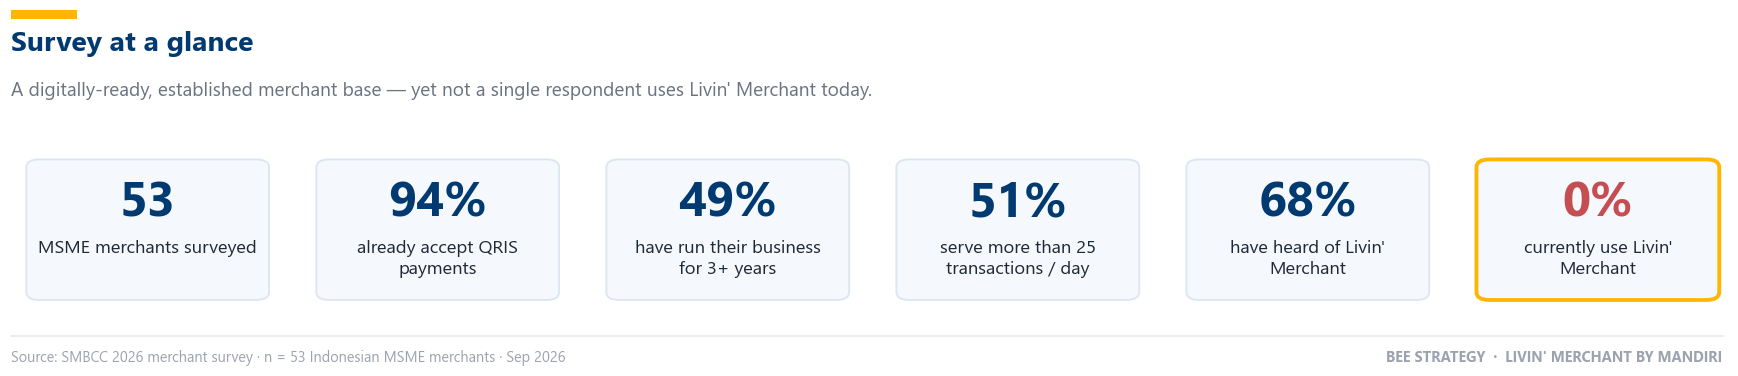

In [5]:
kpis = [
    (f'{N}', 'MSME merchants surveyed'),
    (pct(df.accepts_qris.sum()), 'already accept QRIS payments'),
    (pct((df.tenure_ord >= 3).sum()), 'have run their business for 3+ years'),
    (pct((df.daily_tx_ord >= 3).sum()), 'serve more than 25 transactions / day'),
    (pct(df.aware_livin.sum()), "have heard of Livin' Merchant"),
    ('0%', "currently use Livin' Merchant"),
]
fig, axes = plt.subplots(1, 6, figsize=(16, 3.5))
for i, (ax, (big, small)) in enumerate(zip(axes, kpis)):
    stat_tile(ax, big, small, color=RED if i == 5 else NAVY, accent=(i == 5), big_size=32)
show(fig, 'Survey at a glance',
     "A digitally-ready, established merchant base — yet not a single respondent uses Livin' Merchant today.",
     name='01_survey_at_a_glance')

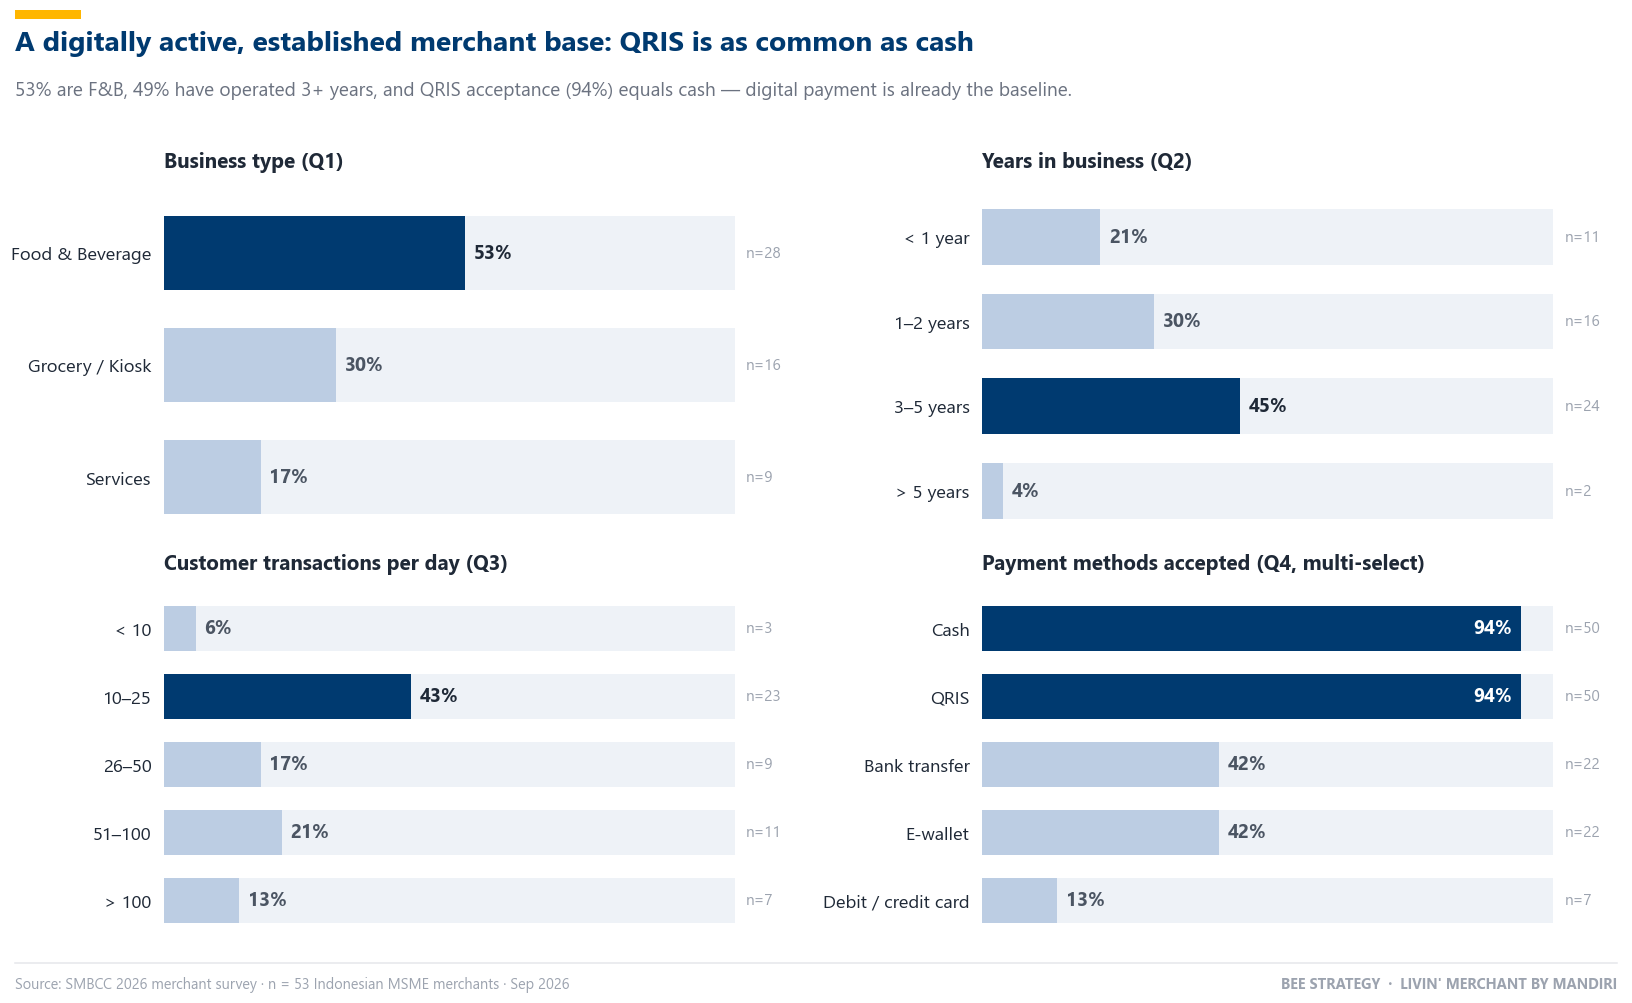

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9.2))
hbar(axes[0, 0], df.business_type.value_counts(), N, title='Business type (Q1)')
hbar(axes[0, 1], df.tenure.value_counts(), N, order=ORDER['tenure'], title='Years in business (Q2)')
hbar(axes[1, 0], df.daily_tx.value_counts(), N, order=ORDER['daily_tx'], title='Customer transactions per day (Q3)')
hbar(axes[1, 1], multi_counts('payment_methods'), N, title='Payment methods accepted (Q4, multi-select)')
show(fig, 'A digitally active, established merchant base: QRIS is as common as cash',
     f'{pct((df.business_type=="Food & Beverage").sum())} are F&B, {pct((df.tenure_ord>=3).sum())} have operated 3+ years, '
     f'and QRIS acceptance ({pct(df.accepts_qris.sum())}) equals cash — digital payment is already the baseline.',
     name='02_merchant_profile')

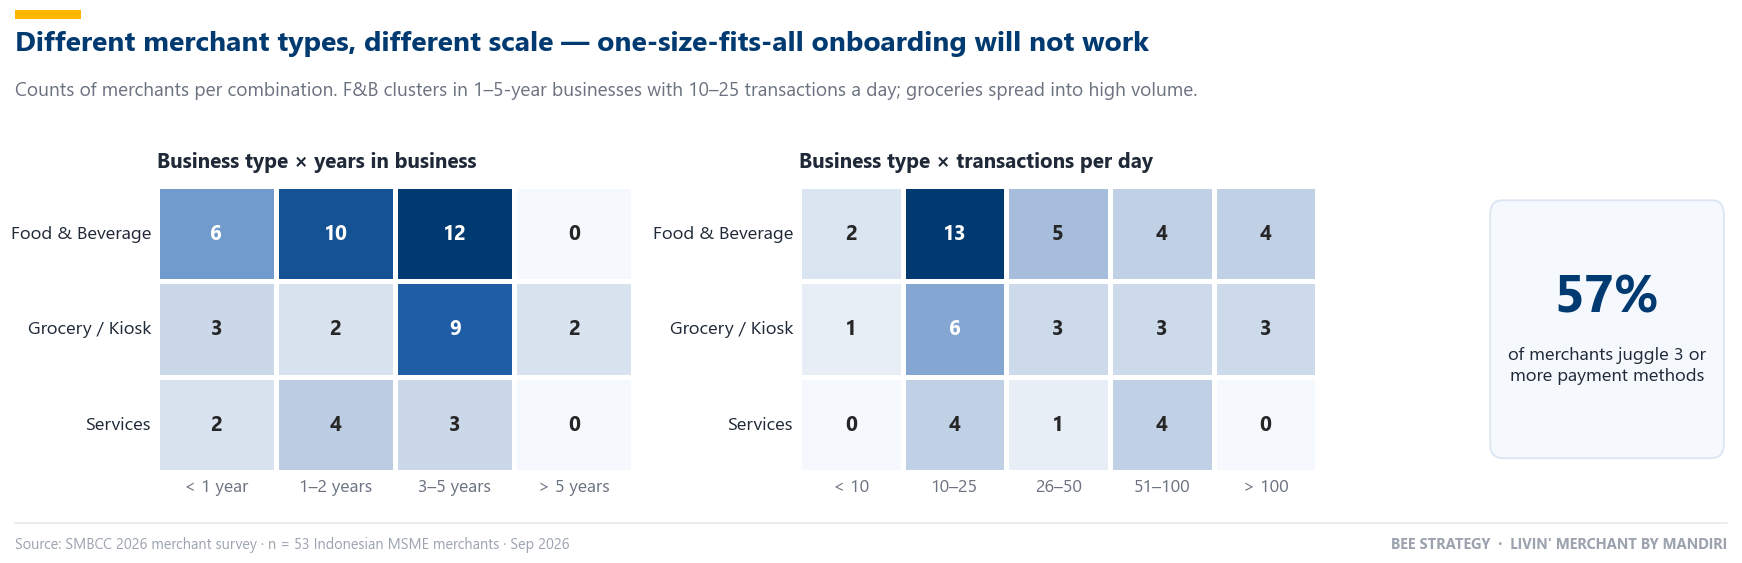

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(16, 5.2), gridspec_kw={'width_ratios': [1.15, 1.25, 0.6]})
for k, (col, ttl) in enumerate([('tenure', 'Business type × years in business'), ('daily_tx', 'Business type × transactions per day')]):
    ax = axs[k]
    ct = pd.crosstab(df.business_type, df[col])
    sns.heatmap(ct, annot=True, fmt='d', cmap=SEQ, cbar=False, linewidths=3, linecolor='white', ax=ax,
                annot_kws={'fontsize': 13.5, 'fontweight': 'bold'})
    ax.set_title(ttl, loc='left', pad=12); ax.set_xlabel(''); ax.set_ylabel('')
    ax.tick_params(axis='y', rotation=0, length=0); ax.tick_params(axis='x', length=0)
stat_tile(axs[2], pct((df.n_payment_methods >= 3).sum()), 'of merchants juggle 3 or more payment methods')
show(fig, 'Different merchant types, different scale — one-size-fits-all onboarding will not work',
     'Counts of merchants per combination. F&B clusters in 1–5-year businesses with 10–25 transactions a day; groceries spread into high volume.',
     name='03_profile_crosstabs')

In [8]:
so_what(f"""The sample matches our <b>primary target segment — digitally active micro & small merchants with recurring
transactions</b>: {pct(df.accepts_qris.sum())} already accept QRIS and {pct((df.tenure_ord>=3).sum())} are established (3+ years).
Because QRIS is universal, <b>payment acceptance is a baseline, not a differentiator</b> (Porter: buyer power & rivalry are very high).
Livin' Merchant must win on what happens <i>after</i> the payment — understanding and growing the business.""", 'BUILD')

---
## 5. How merchants run their business today
This section maps the **current merchant journey (RUN stage)**: which apps they use, why they chose them, and how they record sales.

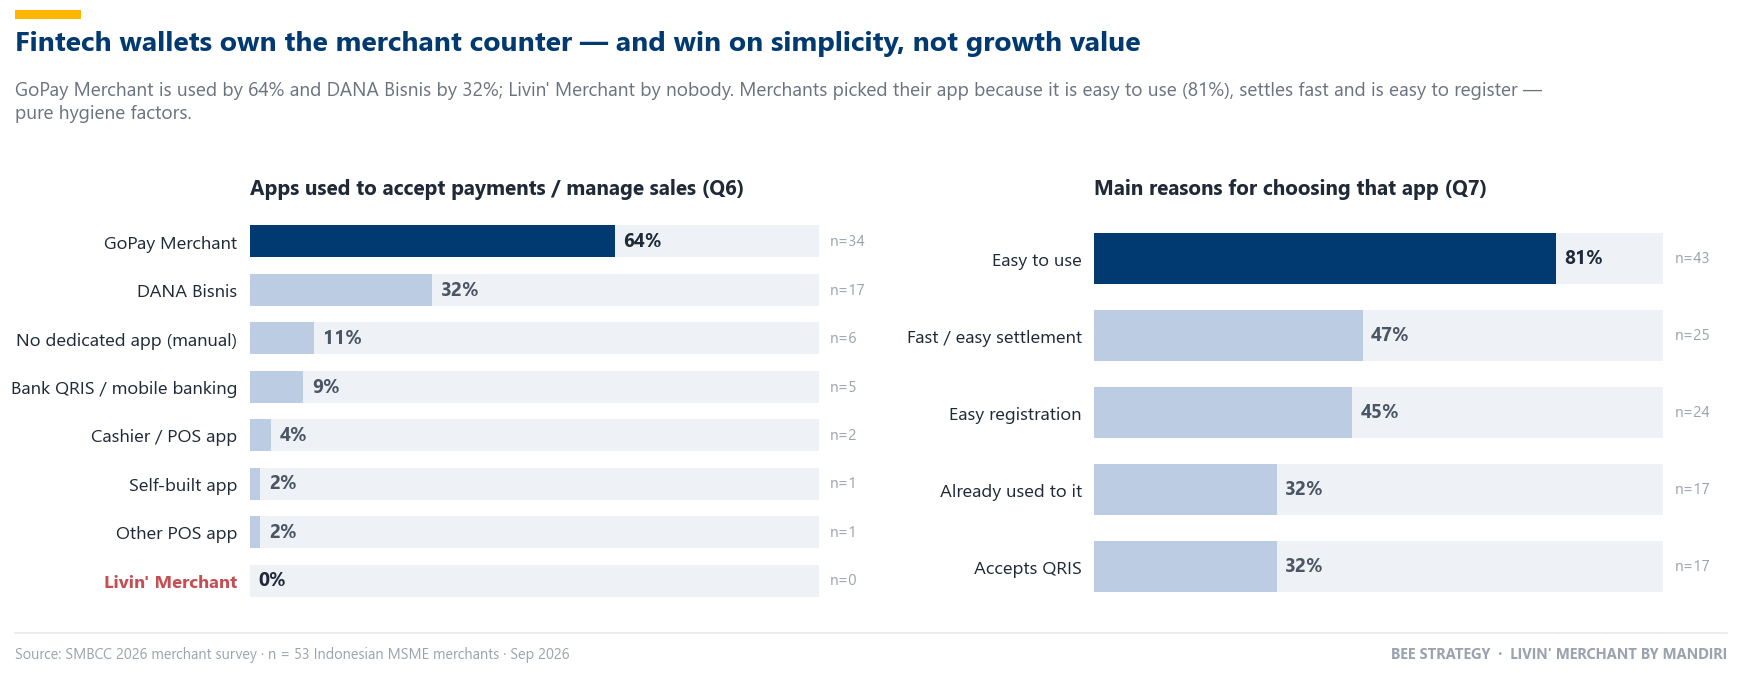

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.2))
apps = multi_counts('current_apps')
apps.loc["Livin' Merchant"] = 0
app_col = {a: SOFT for a in apps.index}; app_col['GoPay Merchant'] = NAVY; app_col["Livin' Merchant"] = RED
hbar(axes[0], apps, N, colors=app_col, title='Apps used to accept payments / manage sales (Q6)')
for t in axes[0].get_yticklabels():
    if t.get_text() == "Livin' Merchant": t.set_color(RED); t.set_fontweight('bold')
hbar(axes[1], multi_counts('app_reasons'), N, title='Main reasons for choosing that app (Q7)')
gopay = df.current_apps.apply(lambda l: 'GoPay Merchant' in l).sum()
dana = df.current_apps.apply(lambda l: 'DANA Bisnis' in l).sum()
show(fig, 'Fintech wallets own the merchant counter — and win on simplicity, not growth value',
     f"GoPay Merchant is used by {pct(gopay)} and DANA Bisnis by {pct(dana)}; Livin' Merchant by nobody. Merchants picked their app because it is "
     f'easy to use ({pct(multi_counts("app_reasons")["Easy to use"])}), settles fast and is easy to register — pure hygiene factors.',
     name='04_current_apps_reasons')

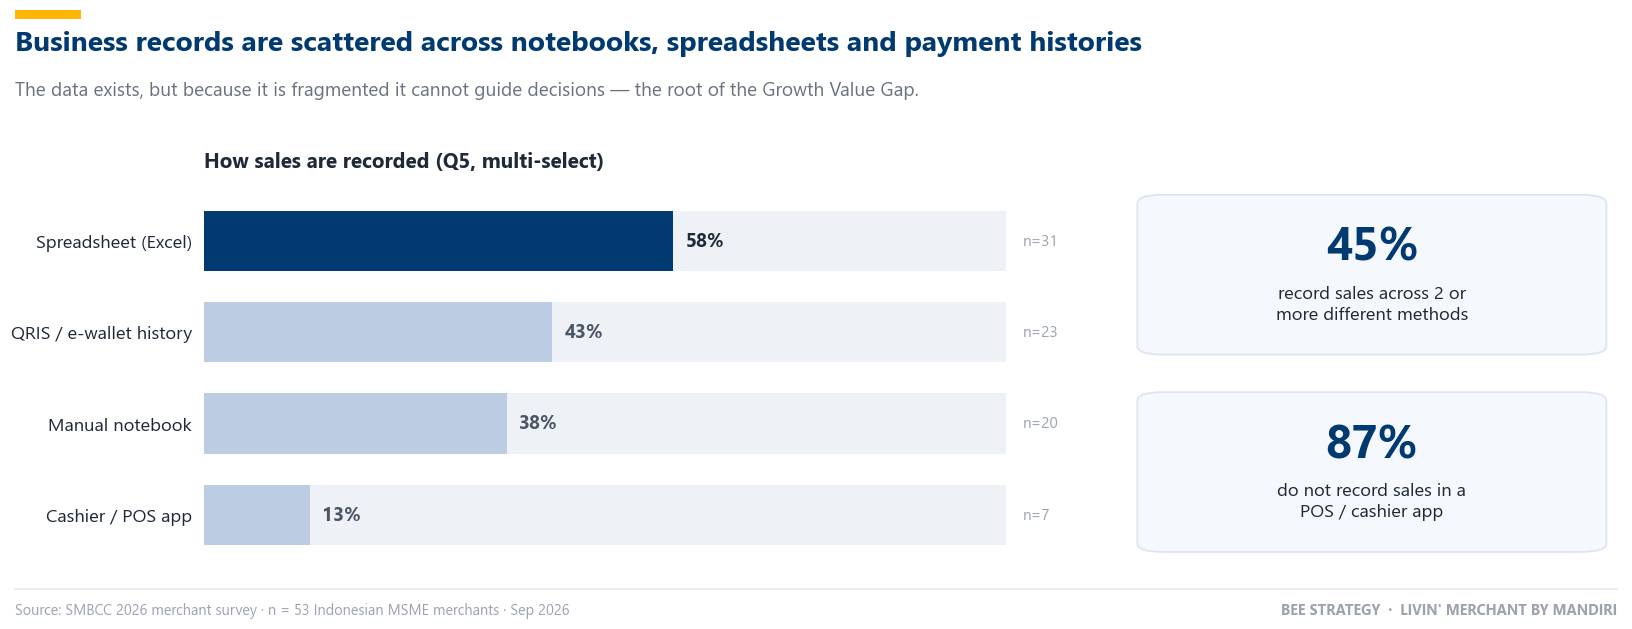

In [10]:
fig, axd = plt.subplot_mosaic([['bars', 't1'], ['bars', 't2']], figsize=(15, 5.8), width_ratios=[1.8, 1])
hbar(axd['bars'], multi_counts('recording_methods'), N, title='How sales are recorded (Q5, multi-select)')
multi = (df.n_recording_methods >= 2).sum()
no_pos = (~df.recording_methods.apply(lambda l: 'Cashier / POS app' in l)).sum()
stat_tile(axd['t1'], pct(multi), 'record sales across 2 or more different methods', big_size=30)
stat_tile(axd['t2'], pct(no_pos), 'do not record sales in a POS / cashier app', big_size=30)
show(fig, 'Business records are scattered across notebooks, spreadsheets and payment histories',
     'The data exists, but because it is fragmented it cannot guide decisions — the root of the Growth Value Gap.',
     name='05_recording_fragmentation')

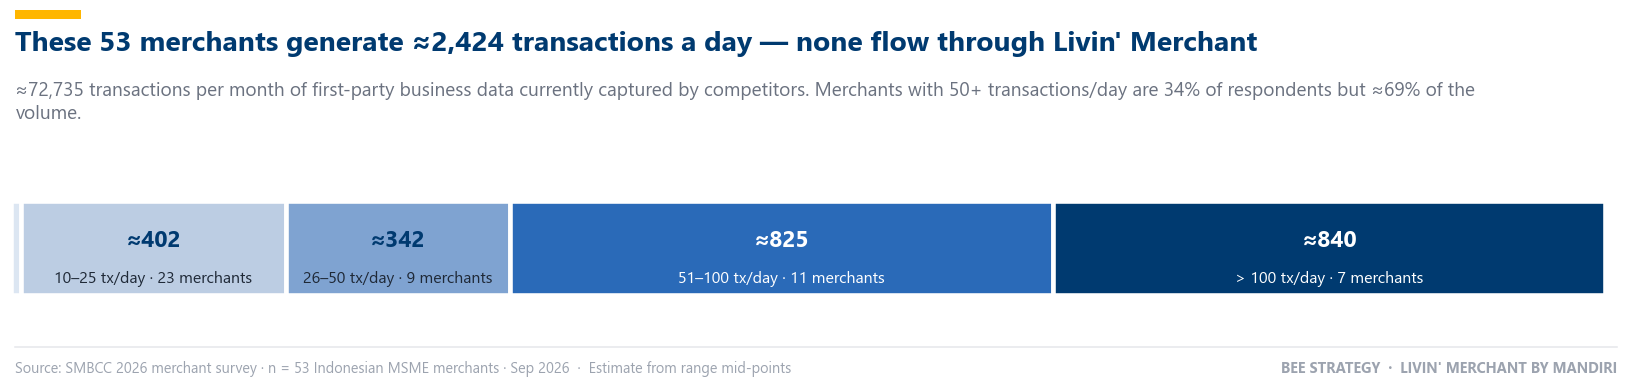

In [11]:
est_daily = df['daily_tx_est'].sum()
seg = df.groupby('daily_tx', observed=False)['daily_tx_est'].agg(['count', 'sum'])
fig, ax = plt.subplots(figsize=(15, 3.6))
left = 0
shades = ['#DCE6F2', '#BCCDE3', '#7FA3D1', BLUE, NAVY]
for (lab, row), col in zip(seg.iterrows(), shades):
    ax.barh(0, row['sum'], left=left, color=col, height=0.6, edgecolor='white', linewidth=3)
    if row['sum'] > 150:
        ax.text(left + row['sum'] / 2, 0.05, f"≈{row['sum']:,.0f}", ha='center', va='center', fontsize=15, fontweight='bold',
                color='white' if col in (BLUE, NAVY) else NAVY)
        ax.text(left + row['sum'] / 2, -0.19, f"{lab} tx/day · {int(row['count'])} merchants", ha='center', va='center',
                fontsize=10.5, color='white' if col in (BLUE, NAVY) else INK)
    left += row['sum']
ax.set_xlim(0, est_daily * 1.01); ax.set_ylim(-0.45, 0.45); ax.set_yticks([]); ax.set_xticks([]); clean(ax)
high_share = seg['sum'].iloc[3:].sum() / est_daily * 100
show(fig, f"These 53 merchants generate ≈{est_daily:,.0f} transactions a day — none flow through Livin' Merchant",
     f'≈{est_daily*30:,.0f} transactions per month of first-party business data currently captured by competitors. '
     f'Merchants with 50+ transactions/day are {pct((df.daily_tx_ord>=4).sum())} of respondents but ≈{high_share:.0f}% of the volume.',
     name='06_transaction_data_opportunity', note='Estimate from range mid-points')

In [12]:
so_what(f"""Merchants chose GoPay/DANA for <b>ease, easy registration and fast settlement</b> — features Livin' Merchant already has.
So parity is not the problem; the <b>Growth Value Gap</b> is: nobody switches for parity. Meanwhile records are split across
{pct((df.n_recording_methods>=2).sum())} multi-tool setups, and ≈{df.daily_tx_est.sum()*30:,.0f} monthly transactions from this sample alone
build competitors' data moats. BEE's <b>RUN → UNDERSTAND → GROW</b> turns one integrated record into the Growth Score and
Financing Readiness that a wallet cannot offer — this is Mandiri's <b>Transaction Data × Banking × Financing</b> moat.""", 'BUILD')

---
## 6. Pain points & needs
What do merchants value most, what stops them from using business-management features, and what would they like to know about their business?

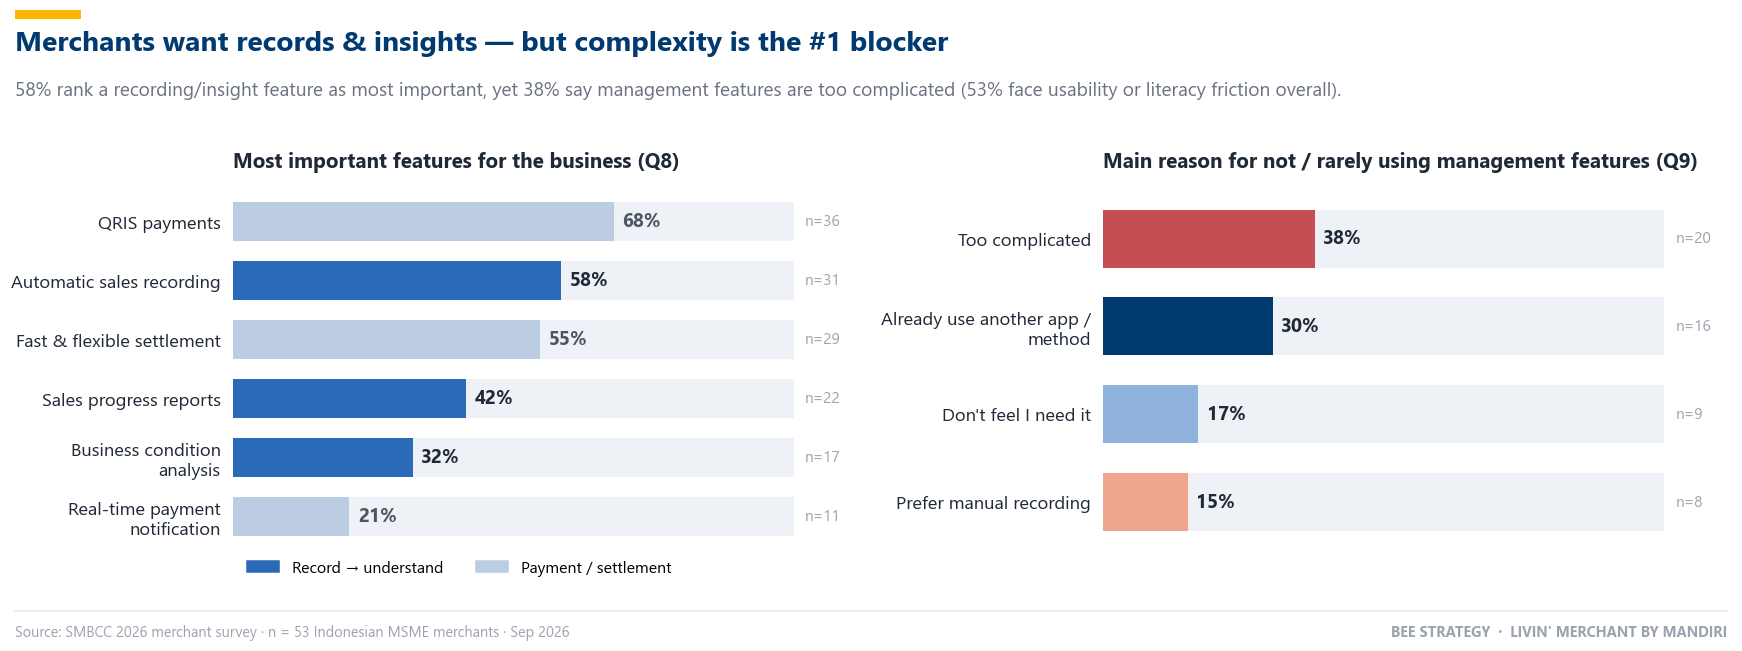

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
kf = multi_counts('key_features')
growth_feats = ['Automatic sales recording', 'Sales progress reports', 'Business condition analysis']
hbar(axes[0], kf, N, colors={k: (BLUE if k in growth_feats else SOFT) for k in kf.index},
     title='Most important features for the business (Q8)')
axes[0].legend(handles=[Patch(color=BLUE, label='Record → understand'), Patch(color=SOFT, label='Payment / settlement')],
               loc='upper left', bbox_to_anchor=(0, 0.0), ncol=2, fontsize=10.5)
bar = df.mgmt_barrier.value_counts()
bar_col = {'Too complicated': RED, 'Prefer manual recording': '#F0A58F',
           'Already use another app / method': NAVY, "Don't feel I need it": '#8FB3DC'}
hbar(axes[1], bar, N, colors=bar_col, title='Main reason for not / rarely using management features (Q9)')
friction = df.mgmt_barrier.isin(['Too complicated', 'Prefer manual recording']).sum()
show(fig, 'Merchants want records & insights — but complexity is the #1 blocker',
     f'{pct(df.key_features.apply(lambda l: bool(set(l) & set(growth_feats))).sum())} rank a recording/insight feature as most important, '
     f'yet {pct(bar["Too complicated"])} say management features are too complicated ({pct(friction)} face usability or literacy friction overall).',
     name='07_features_barriers')

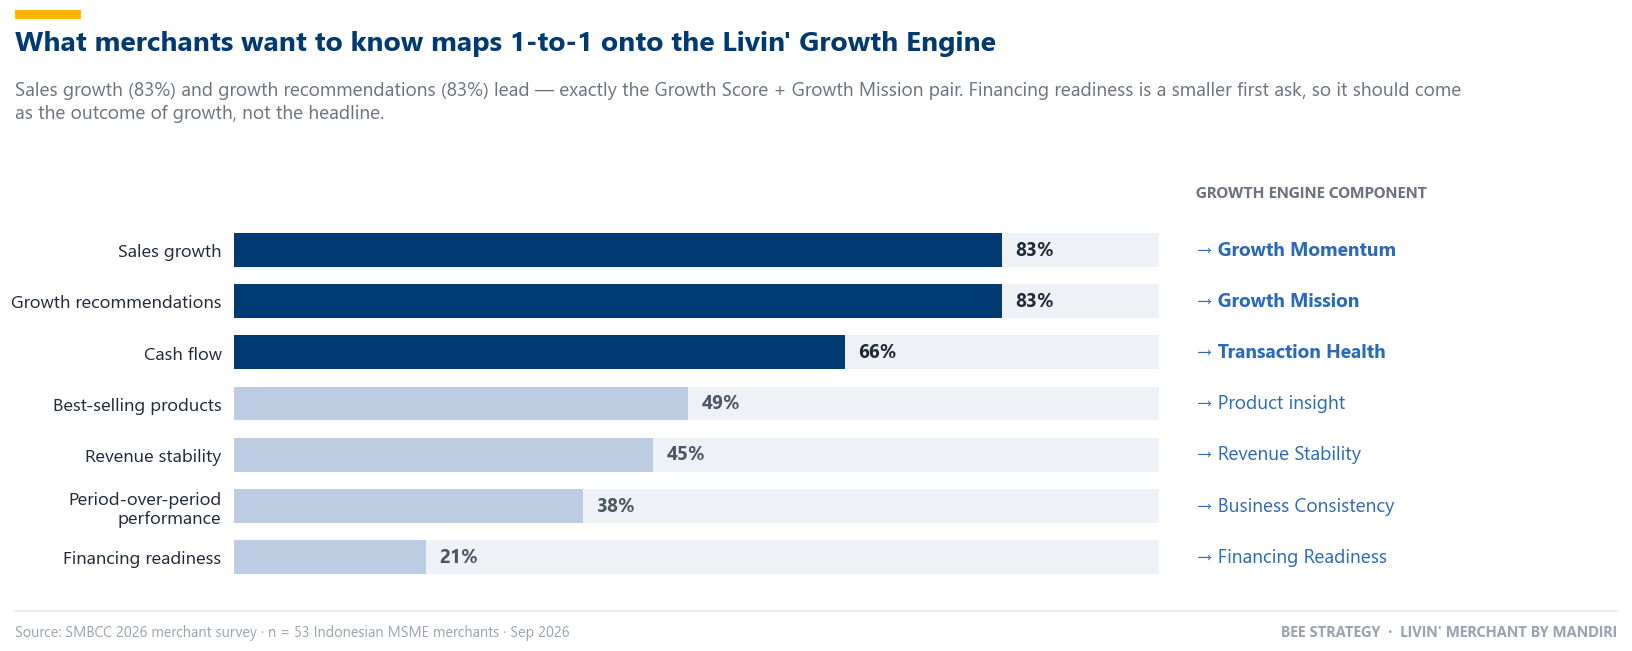

In [14]:
iw = multi_counts('info_wanted')
dim_map = {'Sales growth': 'Growth Momentum', 'Revenue stability': 'Revenue Stability', 'Cash flow': 'Transaction Health',
           'Period-over-period performance': 'Business Consistency', 'Best-selling products': 'Product insight',
           'Growth recommendations': 'Growth Mission', 'Financing readiness': 'Financing Readiness'}
fig, ax = plt.subplots(figsize=(15, 6))
hbar(ax, iw, N, highlight=3, n_labels=False, max_val=100)
ax.set_xlim(0, 150)
ax.text(104, -0.95, 'GROWTH ENGINE COMPONENT', fontsize=10, color=MUTED, fontweight='bold', va='bottom')
for i, k in enumerate(iw.sort_values(ascending=False).index):
    ax.text(104, i, f'→ {dim_map[k]}', va='center', fontsize=12.5, color=BLUE, fontweight='bold' if i < 3 else 'normal')
show(fig, "What merchants want to know maps 1-to-1 onto the Livin' Growth Engine",
     f'Sales growth ({pct(iw["Sales growth"])}) and growth recommendations ({pct(iw["Growth recommendations"])}) lead — exactly the '
     'Growth Score + Growth Mission pair. Financing readiness is a smaller first ask, so it should come as the outcome of growth, not the headline.',
     name='08_info_wanted_growth_engine')

In [15]:
so_what(f"""<b>Growth Value Gap confirmed.</b> Merchants <i>want</i> the UNDERSTAND layer ({pct(iw['Sales growth'])} want sales-growth insight,
{pct(iw['Growth recommendations'])} want recommendations) but {pct(bar['Too complicated'])} find today's tools too complicated.
Implication for BUILD: <b>progressive disclosure</b> — one Growth Score + one next Growth Mission on the home screen, detail on demand.
Financing readiness is desired by only {pct(iw['Financing readiness'])} as a <i>first</i> question, so the journey should be
<b>TRANSACT → UNDERSTAND → IMPROVE → QUALIFY → GROW</b>, with financing as the reward for progress.""", 'BUILD')

---
## 7. Livin' Merchant awareness funnel — the Market Activation Gap

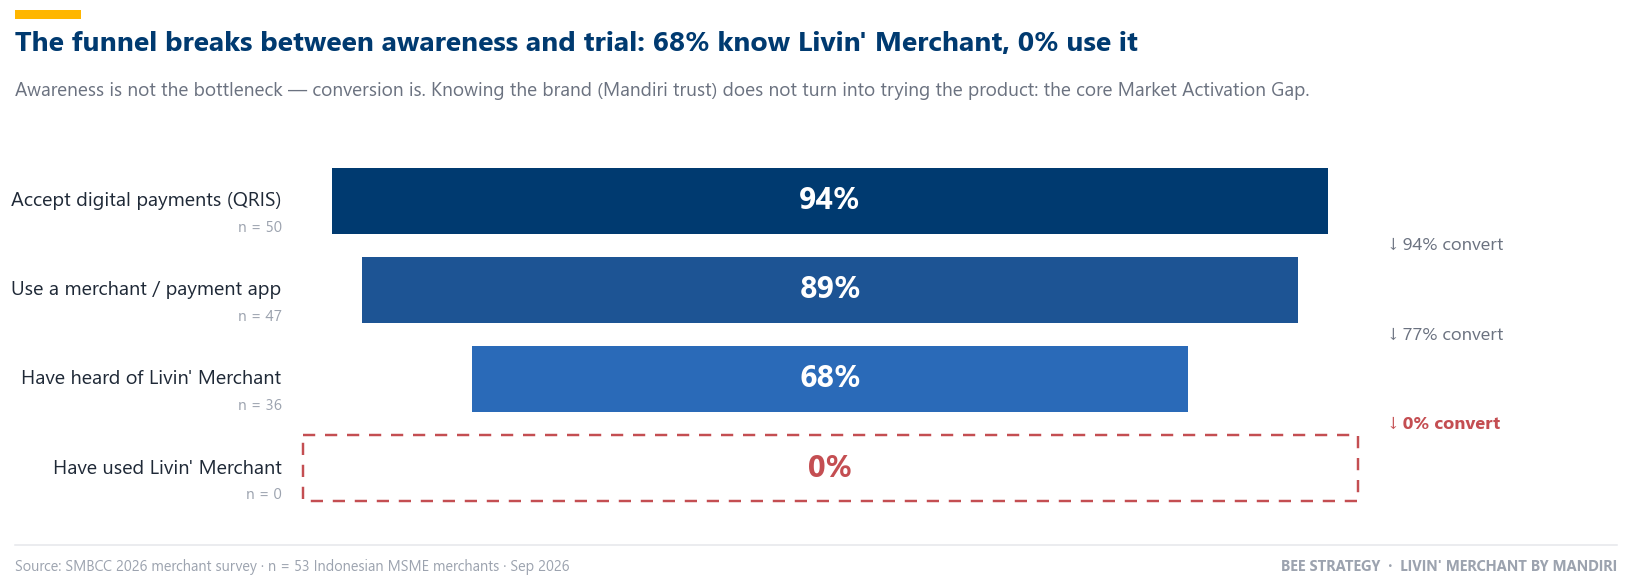

In [16]:
stages = [
    ('Accept digital payments (QRIS)', df.accepts_qris.sum()),
    ('Use a merchant / payment app', df.has_dedicated_app.sum()),
    ("Have heard of Livin' Merchant", df.aware_livin.sum()),
    ("Have used Livin' Merchant", 0),
]
fig, ax = plt.subplots(figsize=(15, 5.4))
for i, ((lab, v), col) in enumerate(zip(stages, [NAVY, '#1d5494', BLUE, RED])):
    if v:
        w = v / N * 100
        ax.barh(i, w, left=(100 - w) / 2, color=col, height=0.74)
    else:
        ax.barh(i, 100, left=0, color='none', height=0.74, edgecolor=RED, linewidth=1.6, linestyle=(0, (5, 4)))
    ax.text(50, i, f'{v / N * 100:.0f}%', ha='center', va='center', fontsize=20, fontweight='bold', color='white' if v else RED)
    ax.text(-2, i, lab, ha='right', va='center', fontsize=13, color=INK)
    ax.text(-2, i + 0.3, f'n = {v}', ha='right', va='center', fontsize=10, color=FAINT)
for i in range(len(stages) - 1):
    a, b = stages[i][1], stages[i + 1][1]
    conv = b / a * 100 if a else 0
    ax.text(103, i + 0.5, f'↓ {conv:.0f}% convert', ha='left', va='center', fontsize=12,
            color=RED if conv < 50 else MUTED, fontweight='bold' if conv < 50 else 'normal')
ax.set_xlim(-2, 125); ax.set_ylim(len(stages) - 0.45, -0.55); ax.axis('off')
fig.subplots_adjust(left=0.27)
show(fig, "The funnel breaks between awareness and trial: 68% know Livin' Merchant, 0% use it",
     'Awareness is not the bottleneck — conversion is. Knowing the brand (Mandiri trust) does not turn into trying the product: '
     'the core Market Activation Gap.', name='09_activation_funnel')

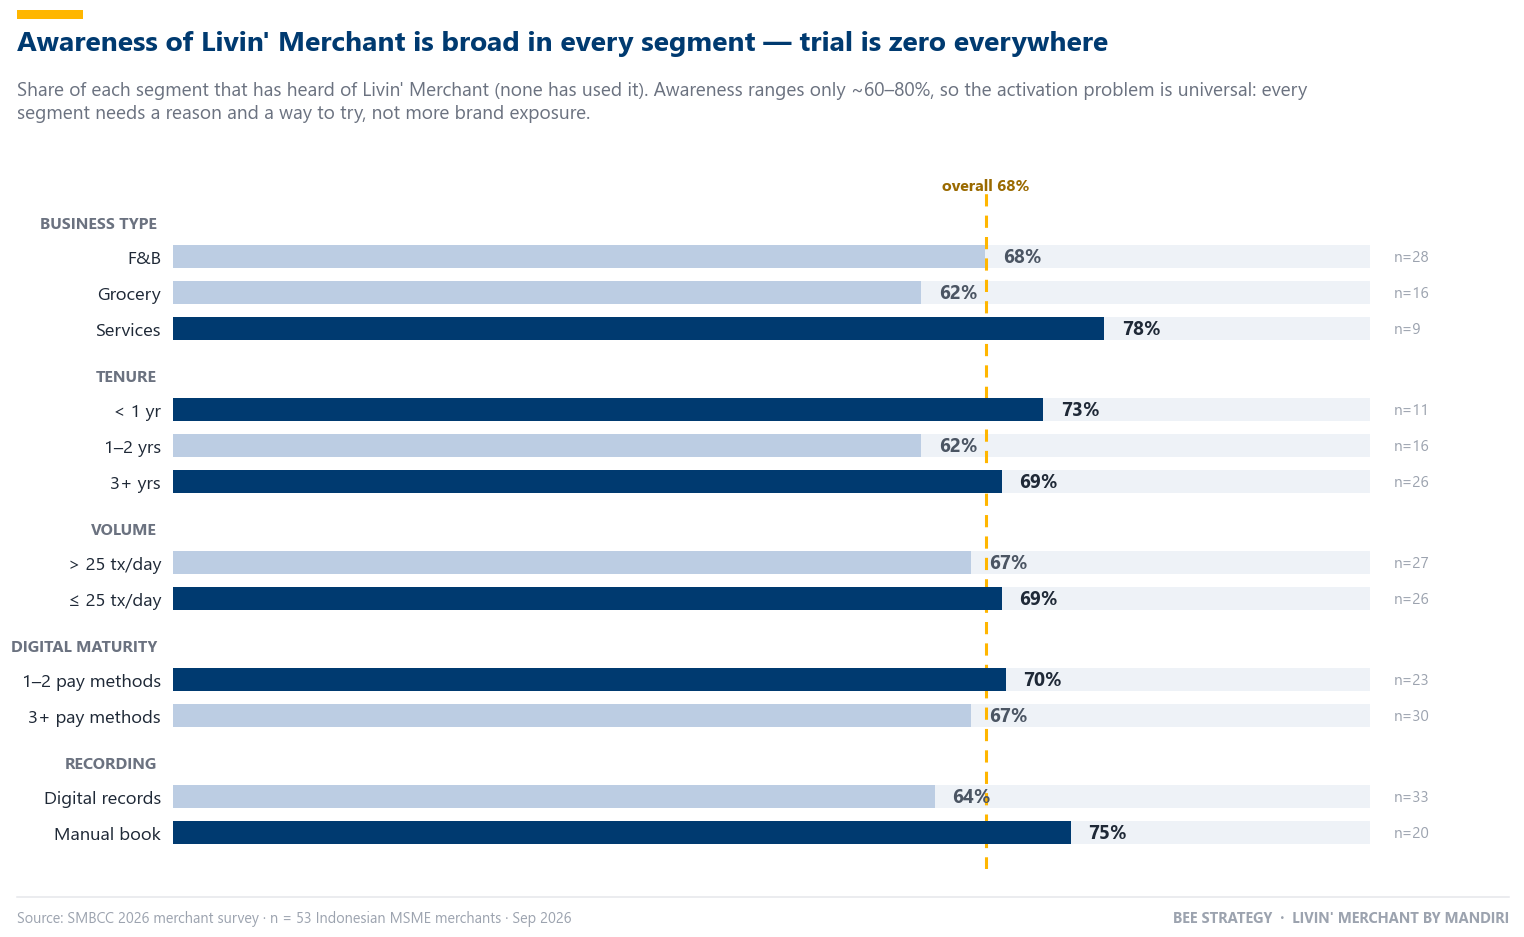

In [17]:
groups = []
overall = df.aware_livin.mean() * 100
for d, lab in [(k, v) for k, v in SEGS.items() if k != 'seg_awareness']:
    g = df.groupby(d, observed=True)['aware_livin'].agg(['mean', 'size'])
    rows = [(SHORT[str(k)], r['mean'] * 100, NAVY if r['mean'] * 100 >= overall else SOFT, int(r['size'])) for k, r in g.iterrows()]
    groups.append((lab, MUTED, rows))
fig, ax = plt.subplots(figsize=(14, 8.6))
grouped_bars(ax, groups, ref=overall, ref_label=f'overall {overall:.0f}%')
show(fig, "Awareness of Livin' Merchant is broad in every segment — trial is zero everywhere",
     "Share of each segment that has heard of Livin' Merchant (none has used it). Awareness ranges only ~60–80%, so the activation problem "
     'is universal: every segment needs a reason and a way to try, not more brand exposure.', name='10_awareness_by_segment')

In [18]:
so_what(f"""<b>Market Activation Gap confirmed.</b> {pct(df.aware_livin.sum())} of merchants already know Livin' Merchant (Mandiri's brand
reach works), but <b>0% have tried it</b>, while {pct(df.has_dedicated_app.sum())} actively use a competitor app. Exposure alone does not activate —
merchants need to <i>experience</i> the value. ENGAGE therefore focuses on conversion mechanics: <b>Explore Mode</b> (see value before
opening an account), <b>UMKM Growth Activation / Livi Growth Van</b> (DISCOVER → CHECK → EXPERIENCE → ACTIVATE → FIRST TRANSACTION),
and growth-outcome messaging (<i>"Every Transaction Moves Your Business Forward"</i>) rather than feature lists.""", 'ENGAGE')

---
## 8. Likert deep dive — statistical validation of every BEE feature
Fourteen 5-point statements (1 = strongly disagree … 5 = strongly agree) each test one BEE mechanism. The chart shows the full answer distribution centred on *neutral*, grouped by pillar, with **% agree (Top-2-Box = 4 or 5)** on the right. The table beneath adds the statistics:
* **95% Wilson confidence interval** for % agree,
* **One-sample Wilcoxon signed-rank test** against neutral (3), **Holm-corrected** for 14 tests,
* **Rank-biserial effect size** (r): 0.1 small · 0.3 medium · 0.5 large.

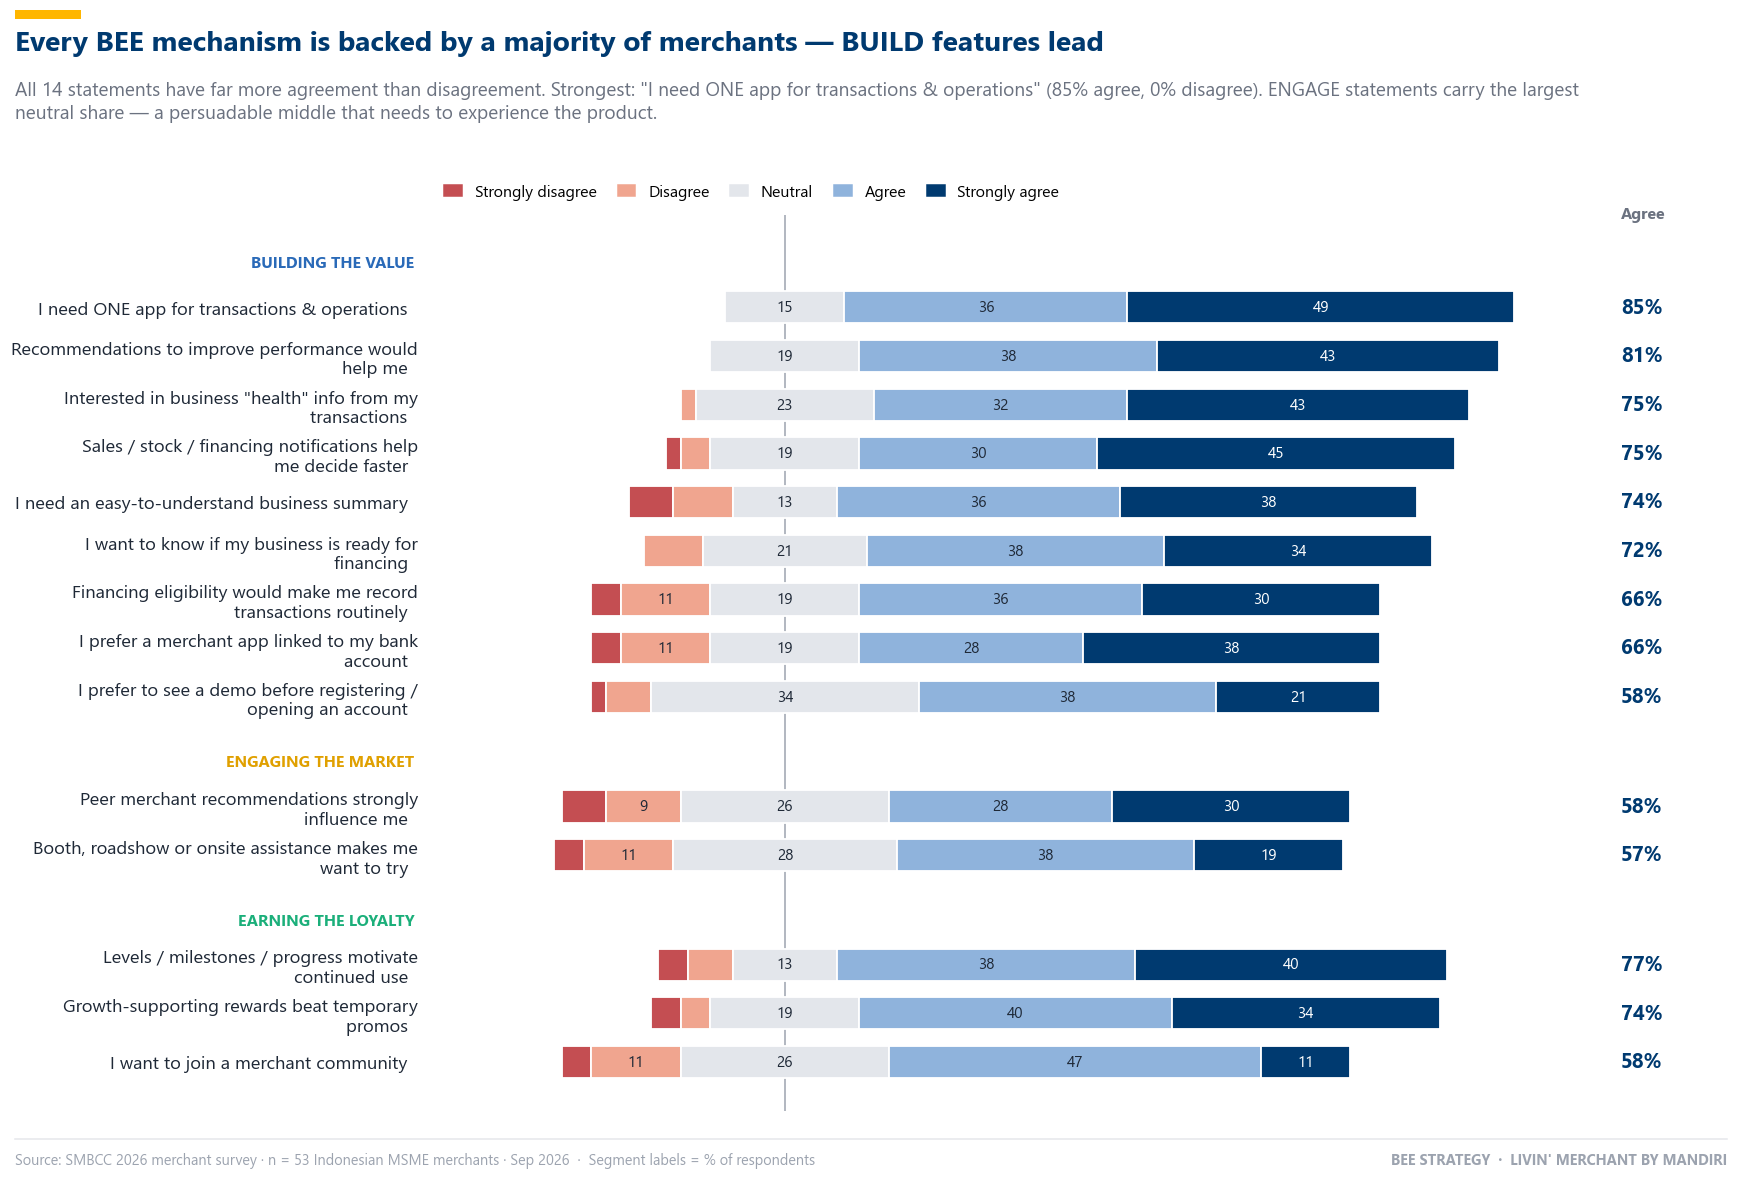

In [19]:
t2b_all = (df[LIKERT_ITEMS] >= 4).mean() * 100
groups = [(PILLAR_NAME[p], PILLAR[p], sorted(PILLAR_ITEMS[p], key=lambda q: -t2b_all[q])) for p in PILLAR]
fig, ax = plt.subplots(figsize=(16, 10.8))
likert(ax, df, groups, LABEL)
top = t2b_all.idxmax()
show(fig, 'Every BEE mechanism is backed by a majority of merchants — BUILD features lead',
     f'All 14 statements have far more agreement than disagreement. Strongest: "{LIKERT_EN[top]}" ({t2b_all[top]:.0f}% agree, 0% disagree). '
     'ENGAGE statements carry the largest neutral share — a persuadable middle that needs to experience the product.',
     name='11_likert_all_items', note='Segment labels = % of respondents')

In [20]:
def rank_biserial(x, mu=3):
    d = x - mu
    d = d[d != 0]
    r = stats.rankdata(np.abs(d))
    return (r[d > 0].sum() - r[d < 0].sum()) / r.sum()

rows = []
for q in LIKERT_ITEMS:
    x = df[q].values
    k = (x >= 4).sum()
    lo, hi = proportion_confint(k, N, method='wilson')
    w = stats.wilcoxon(x - 3, alternative='greater')
    rows.append({'Item': q, 'Pillar': PILLAR_OF[q], 'BEE feature': BEE_FEATURE[q], 'Statement': LIKERT_EN[q],
                 'Mean': x.mean(), 'SD': x.std(ddof=1), 'Median': np.median(x),
                 'T2B %': k / N * 100, 'T2B 95% CI': f'{lo*100:.0f}–{hi*100:.0f}%',
                 'Bottom-2 %': (x <= 2).mean() * 100, 'Net agree (pp)': ((x >= 4).mean() - (x <= 2).mean()) * 100,
                 'p (Wilcoxon > 3)': w.pvalue, 'Effect r': rank_biserial(x)})
LK = pd.DataFrame(rows)
LK['p Holm'] = multipletests(LK['p (Wilcoxon > 3)'], method='holm')[1]
LK['Significant'] = np.where(LK['p Holm'] < 0.05, '✔ yes', '–')
LK = LK.sort_values('T2B %', ascending=False).reset_index(drop=True)
display(LK.style.format({'Mean': '{:.2f}', 'SD': '{:.2f}', 'Median': '{:.0f}', 'T2B %': '{:.0f}%', 'Bottom-2 %': '{:.0f}%',
                         'Net agree (pp)': '{:+.0f}', 'p (Wilcoxon > 3)': '{:.1e}', 'p Holm': '{:.1e}', 'Effect r': '{:.2f}'})
        .background_gradient(subset=['T2B %'], cmap=SEQ).background_gradient(subset=['Effect r'], cmap=SEQ)
        .set_properties(**{'font-size': '12.5px'}).hide(axis='index'))
print(f"{(LK['p Holm'] < 0.05).sum()} of {len(LK)} statements are significantly above neutral after Holm correction.")

Item,Pillar,BEE feature,Statement,Mean,SD,Median,T2B %,T2B 95% CI,Bottom-2 %,Net agree (pp),p (Wilcoxon > 3),Effect r,p Holm,Significant
Q15,BUILD,Integrated app (RUN),I need ONE app for transactions & operations,4.34,0.73,4,85%,73–92%,0%,+85,7.7e-10,1.00,1.1e-08,✔ yes
Q17,BUILD,Growth Mission / Next Best Action,Recommendations to improve performance would help me,4.25,0.76,4,81%,69–89%,0%,+81,1.9e-09,1.00,2.4e-08,✔ yes
Q24,EARN,Business Growth Stage,Levels / milestones / progress motivate continued use,4.04,1.06,4,77%,64–87%,9%,+68,4.9e-07,0.80,4.4e-06,✔ yes
Q12,BUILD,Growth Score,"Interested in business ""health"" info from my transactions",4.17,0.85,4,75%,62–85%,2%,+74,8.7e-09,0.98,1.0e-07,✔ yes
Q21,BUILD,Proactive notification (ACT),Sales / stock / financing notifications help me decide faster,4.13,0.98,4,75%,62–85%,6%,+70,6.4e-08,0.89,7.0e-07,✔ yes
Q16,BUILD,Business insights (UNDERSTAND),I need an easy-to-understand business summary,3.92,1.16,4,74%,60–84%,13%,+60,6.3e-06,0.72,4.4e-05,✔ yes
Q25,EARN,Growth-based rewards,Growth-supporting rewards beat temporary promos,3.96,1.02,4,74%,60–84%,8%,+66,9.7e-07,0.81,7.7e-06,✔ yes
Q18,BUILD,Financing Readiness (GROW),I want to know if my business is ready for financing,3.98,0.93,4,72%,58–82%,8%,+64,1.1e-07,0.89,1.1e-06,✔ yes
Q14,BUILD,Data-to-financing incentive,Financing eligibility would make me record transactions routinely,3.77,1.12,4,66%,53–77%,15%,+51,2.3e-05,0.69,9.4e-05,✔ yes
Q20,BUILD,Livin' ecosystem (CONNECT),I prefer a merchant app linked to my bank account,3.85,1.17,4,66%,53–77%,15%,+51,1.0e-05,0.72,6.1e-05,✔ yes


14 of 14 statements are significantly above neutral after Holm correction.


### 8.1 Pillar indices & reliability
We average the items of each pillar into a respondent-level **BUILD / ENGAGE / EARN index** (1–5) and check internal consistency with **Cronbach's α**.

Pillar,Items,Cronbach's α,Mean index,% with index ≥ 4,% with index > 3
BUILD,"Q12, Q14, Q15, Q16, Q17, Q18, Q19, Q20, Q21",0.70,4.01,58%,96%
ENGAGE,"Q22, Q23",0.59,3.62,51%,64%
EARN,"Q24, Q25, Q26",0.22,3.84,55%,79%


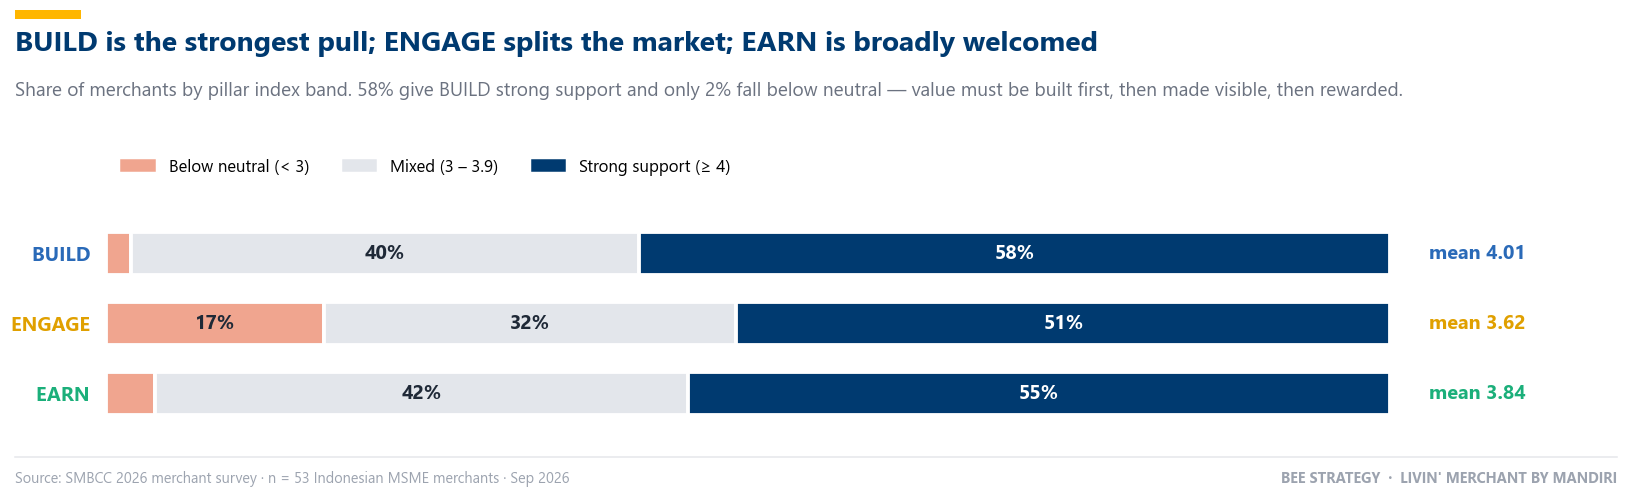

In [21]:
def cronbach_alpha(items):
    items = np.asarray(items, float)
    k = items.shape[1]
    return k / (k - 1) * (1 - items.var(axis=0, ddof=1).sum() / items.sum(axis=1).var(ddof=1))

for p, qs in PILLAR_ITEMS.items():
    df[f'idx_{p}'] = df[qs].mean(axis=1)
df['idx_BEE'] = df[LIKERT_ITEMS].mean(axis=1)
IDX = [f'idx_{p}' for p in PILLAR]

summary = pd.DataFrame({
    'Pillar': list(PILLAR),
    'Items': [', '.join(PILLAR_ITEMS[p]) for p in PILLAR],
    "Cronbach's α": [cronbach_alpha(df[PILLAR_ITEMS[p]]) for p in PILLAR],
    'Mean index': [df[f'idx_{p}'].mean() for p in PILLAR],
    '% with index ≥ 4': [(df[f'idx_{p}'] >= 4).mean() * 100 for p in PILLAR],
    '% with index > 3': [(df[f'idx_{p}'] > 3).mean() * 100 for p in PILLAR],
})
display(summary.style.format({"Cronbach's α": '{:.2f}', 'Mean index': '{:.2f}', '% with index ≥ 4': '{:.0f}%',
                              '% with index > 3': '{:.0f}%'}).hide(axis='index'))

BANDS = [('Below neutral (< 3)', '#F0A58F'), ('Mixed (3 – 3.9)', '#E3E6EB'), ('Strong support (≥ 4)', NAVY)]
fig, ax = plt.subplots(figsize=(15, 4.6))
for i, p in enumerate(PILLAR):
    v = df[f'idx_{p}']
    shares = [(v < 3).mean() * 100, ((v >= 3) & (v < 4)).mean() * 100, (v >= 4).mean() * 100]
    left = 0
    for (lab, colr), s in zip(BANDS, shares):
        ax.barh(i, s, left=left, color=colr, height=0.62, edgecolor='white', linewidth=2.5)
        if s >= 5:
            ax.text(left + s / 2, i, f'{s:.0f}%', ha='center', va='center', fontsize=13, fontweight='bold',
                    color='white' if colr == NAVY else INK)
        left += s
    ax.text(103, i, f'mean {v.mean():.2f}', va='center', fontsize=13, fontweight='bold', color=PILLAR[p])
ax.set_yticks(range(3)); ax.set_yticklabels([f'{p}  ' for p in PILLAR], fontsize=13, fontweight='bold')
for t, p in zip(ax.get_yticklabels(), PILLAR): t.set_color(PILLAR[p])
ax.set_xlim(0, 118); ax.set_ylim(2.5, -0.9); ax.set_xticks([]); clean(ax)
ax.legend(handles=[Patch(color=c, label=l) for l, c in BANDS], ncol=3, loc='lower left', bbox_to_anchor=(0, 1.0))
show(fig, 'BUILD is the strongest pull; ENGAGE splits the market; EARN is broadly welcomed',
     f"Share of merchants by pillar index band. {(df.idx_BUILD>=4).mean()*100:.0f}% give BUILD strong support and only "
     f"{(df.idx_BUILD<3).mean()*100:.0f}% fall below neutral — value must be built first, then made visible, then rewarded.",
     name='12_pillar_indices')

**Reading the reliability numbers honestly.** The BUILD index is internally consistent (α ≈ 0.70). ENGAGE (only two items) and especially EARN (α ≈ 0.22) are not. The three EARN statements measure different mechanisms: progress, reward type and community. They are not interchangeable (Q25 and Q26 are essentially uncorrelated, see Section 14). We therefore treat the ENGAGE and EARN indices as summary averages and read their items one by one in Sections 9.2–9.3. This also supports building EARN as **separate modules** (Growth Stage, growth rewards, Merchant Circle) rather than a single loyalty programme.

In [22]:
so_what(f"""All 14 BEE mechanisms are endorsed; {(LK['p Holm']<0.05).sum()} of 14 are statistically above neutral after multiple-test correction.
The ordering itself validates the BEE sequence: <b>BUILD</b> (index μ {df.idx_BUILD.mean():.2f}) is what merchants want most — a reason to
<i>choose</i>; <b>ENGAGE</b> (μ {df.idx_ENGAGE.mean():.2f}) has the biggest neutral middle — these merchants must be <i>shown</i>, so
targeted, experiential activation beats mass reach; <b>EARN</b> (μ {df.idx_EARN.mean():.2f}) confirms appetite for visible progress
and growth-based rewards, the reason to <i>stay</i>.""")

---
## 9. BEE pillar evidence
### 9.1 BUILD — Run → Understand → Grow · Explore → Act → Connect
Q29 asked which Livin' Merchant features/benefits would most attract merchants (max 3). We map each option onto the BUILD value architecture.

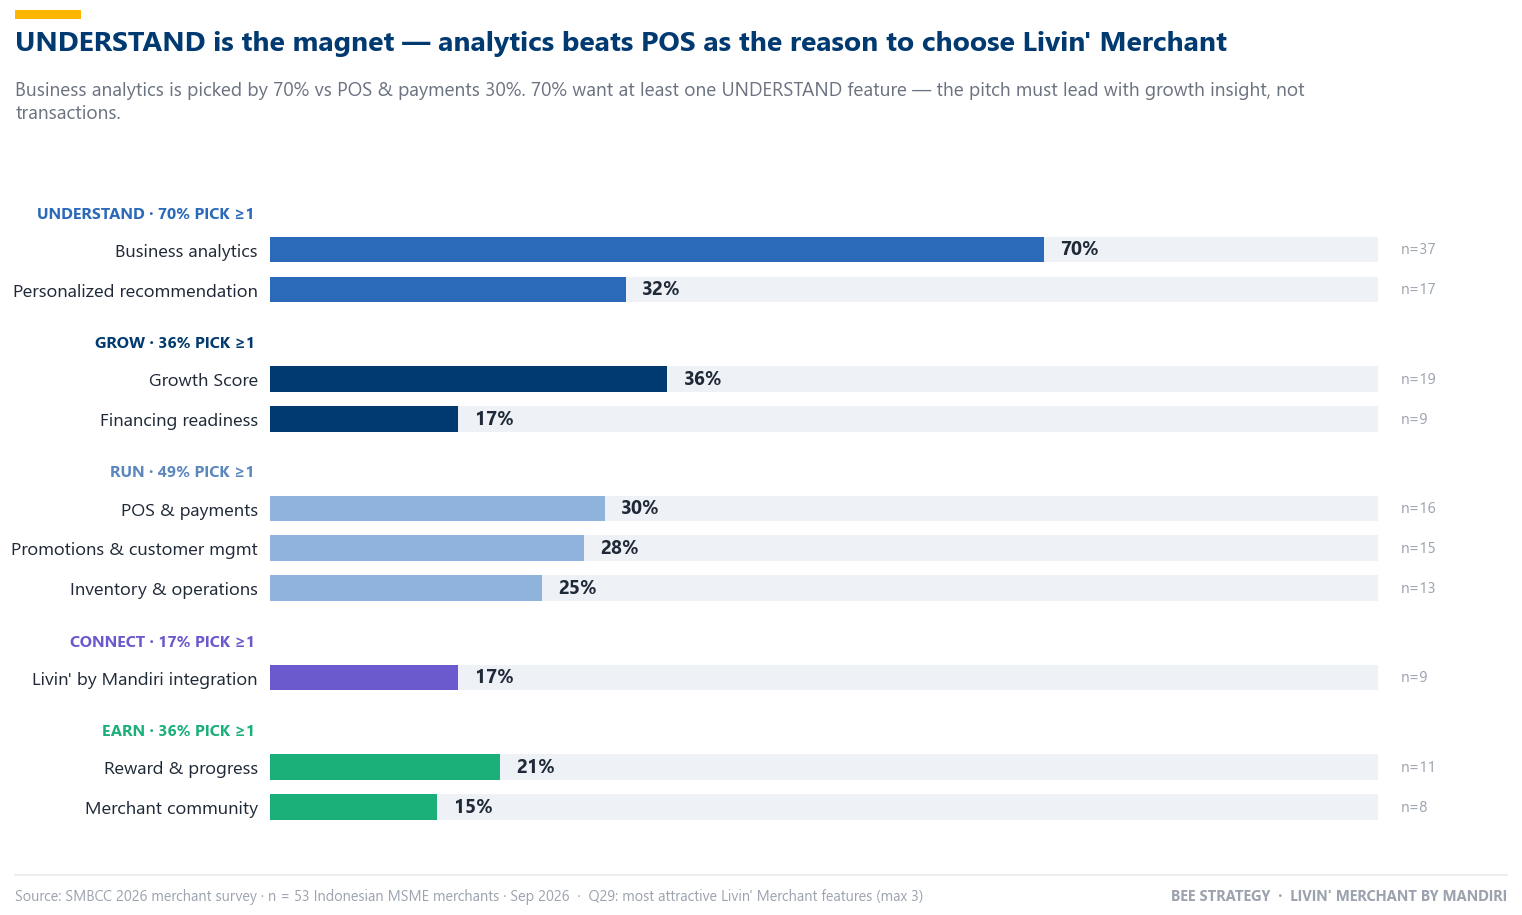

In [23]:
LAYER = {'POS & payments': 'RUN', 'Inventory & operations': 'RUN', 'Promotions & customer mgmt': 'RUN',
         'Business analytics': 'UNDERSTAND', 'Personalized recommendation': 'UNDERSTAND',
         'Growth Score': 'GROW', 'Financing readiness': 'GROW',
         "Livin' by Mandiri integration": 'CONNECT', 'Reward & progress': 'EARN', 'Merchant community': 'EARN'}
LAYER_COL = {'RUN': '#8FB3DC', 'UNDERSTAND': BLUE, 'GROW': NAVY, 'CONNECT': VIOLET, 'EARN': PILLAR['EARN']}
LAYER_HEAD = {'RUN': '#5b87bd', 'UNDERSTAND': BLUE, 'GROW': NAVY, 'CONNECT': VIOLET, 'EARN': PILLAR['EARN']}
lf = multi_counts('livin_features')
layer_reach = {L: df.livin_features.apply(lambda l: any(LAYER[x] == L for x in l)).sum() for L in LAYER_COL}
groups = []
for L in ['UNDERSTAND', 'GROW', 'RUN', 'CONNECT', 'EARN']:
    feats = lf[[f for f in lf.index if LAYER[f] == L]].sort_values(ascending=False)
    groups.append((f'{L} · {pct(layer_reach[L])} pick ≥1', LAYER_HEAD[L],
                   [(f, v / N * 100, LAYER_COL[L], v) for f, v in feats.items()]))
fig, ax = plt.subplots(figsize=(14, 8.4))
grouped_bars(ax, groups, label_w=32)
show(fig, "UNDERSTAND is the magnet — analytics beats POS as the reason to choose Livin' Merchant",
     f'Business analytics is picked by {pct(lf["Business analytics"])} vs POS & payments {pct(lf["POS & payments"])}. '
     f'{pct(layer_reach["UNDERSTAND"])} want at least one UNDERSTAND feature — the pitch must lead with growth insight, not transactions.',
     name='13_build_layers', note="Q29: most attractive Livin' Merchant features (max 3)")

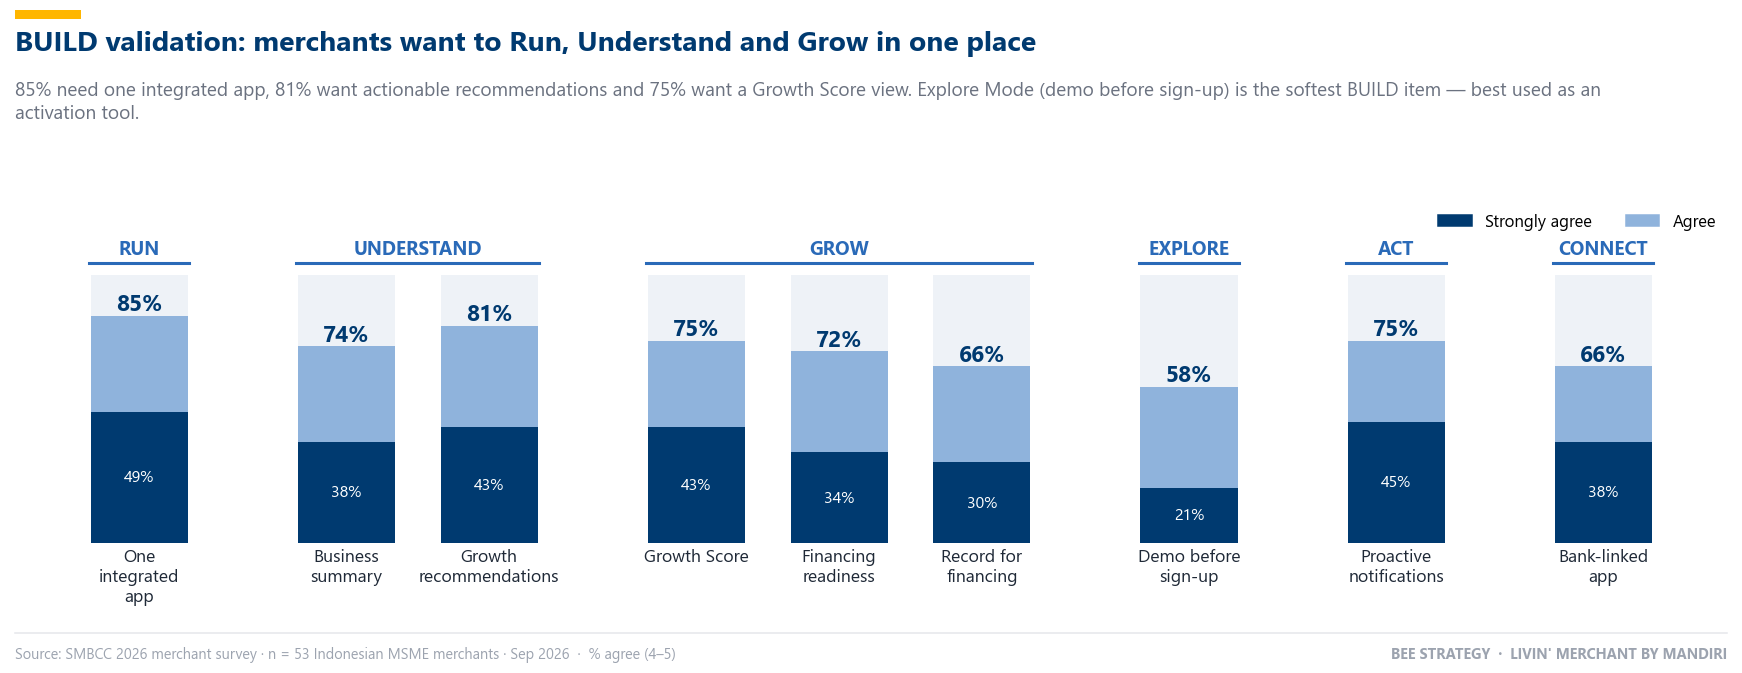

In [24]:
groups_b = {'RUN': ['Q15'], 'UNDERSTAND': ['Q16', 'Q17'], 'GROW': ['Q12', 'Q18', 'Q14'], 'EXPLORE': ['Q19'], 'ACT': ['Q21'], 'CONNECT': ['Q20']}
fig, ax = plt.subplots(figsize=(16, 6.2))
x, xt, xl = 0, [], []
for g, qs in groups_b.items():
    x_start = x
    for q in qs:
        t2b = (df[q] >= 4).mean() * 100; sa = (df[q] == 5).mean() * 100
        ax.bar(x, 100, color=TRACK, width=0.68, zorder=0)
        ax.bar(x, t2b, color='#8FB3DC', width=0.68, zorder=1)
        ax.bar(x, sa, color=NAVY, width=0.68, zorder=2)
        ax.text(x, t2b + 2, f'{t2b:.0f}%', ha='center', fontsize=15, fontweight='bold', color=NAVY)
        ax.text(x, sa / 2, f'{sa:.0f}%', ha='center', va='center', fontsize=10.5, color='white')
        xt.append(x); xl.append(wrap(SHORT_FEATURE[q], 12)); x += 1
    ax.text((x_start + x - 1) / 2, 108, g, ha='center', fontsize=12.5, fontweight='bold', color=BLUE)
    ax.plot([x_start - 0.35, x - 0.65], [104.5, 104.5], color=BLUE, lw=2)
    x += 0.45
ax.set_xticks(xt); ax.set_xticklabels(xl, fontsize=11.5, color=INK); ax.set_ylim(0, 114); ax.set_yticks([]); clean(ax)
ax.legend(handles=[Patch(color=NAVY, label='Strongly agree'), Patch(color='#8FB3DC', label='Agree')], loc='upper right',
          bbox_to_anchor=(1, 1.13), ncol=2)
show(fig, 'BUILD validation: merchants want to Run, Understand and Grow in one place',
     f'{(df.Q15>=4).mean()*100:.0f}% need one integrated app, {(df.Q17>=4).mean()*100:.0f}% want actionable recommendations and '
     f'{(df.Q12>=4).mean()*100:.0f}% want a Growth Score view. Explore Mode (demo before sign-up) is the softest BUILD item — best used as an activation tool.',
     name='14_build_validation', note='% agree (4–5)')

In [25]:
so_what(f"""<b>Building the Value is the strongest-supported pillar.</b> {(df.Q15>=4).mean()*100:.0f}% want one app for everything (RUN),
{pct(lf['Business analytics'])} pick business analytics as a top reason to use Livin' Merchant (UNDERSTAND), and
{(df.Q12>=4).mean()*100:.0f}% want a Growth Score-style health check (GROW). {(df.Q14>=4).mean()*100:.0f}% would record transactions
<i>more routinely</i> if it improved financing eligibility — the behavioural hinge of the flywheel
<b>more transactions → better data → better guidance → financing</b>. {(df.Q20>=4).mean()*100:.0f}% prefer an app linked to their bank
account — a structural advantage for Livin' by Mandiri integration (CONNECT) that wallets cannot copy.""", 'BUILD')

### 9.2 ENGAGE — Digital Growth Marketing + UMKM Growth Activation

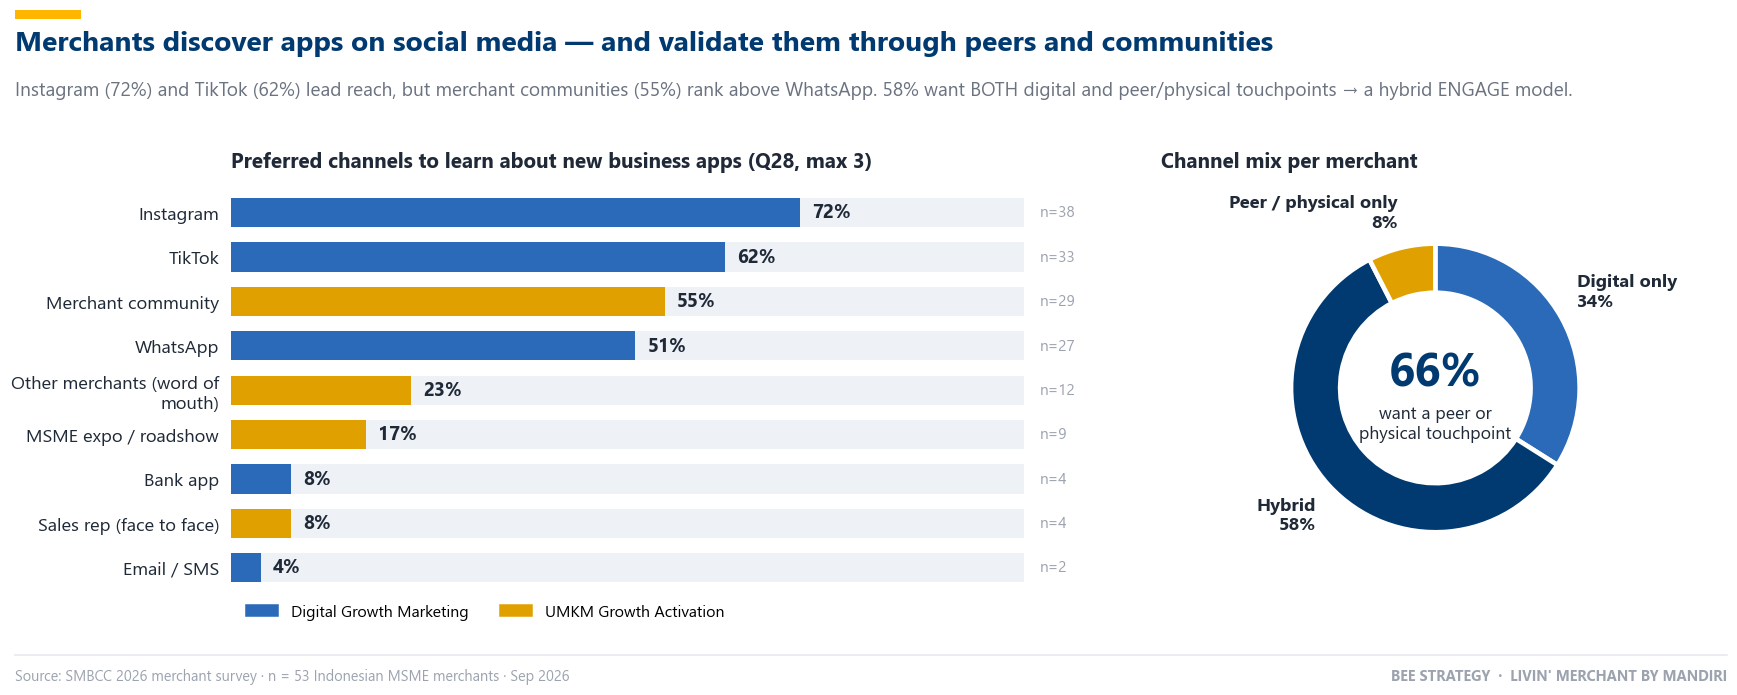

In [26]:
ch = multi_counts('media_channels')
DIGITAL = {'Instagram', 'TikTok', 'WhatsApp', 'Bank app', 'Email / SMS'}
PHYSICAL = {'Merchant community', 'Other merchants (word of mouth)', 'MSME expo / roadshow', 'Sales rep (face to face)'}
df['ch_digital'] = df.media_channels.apply(lambda l: bool(set(l) & DIGITAL))
df['ch_physical'] = df.media_channels.apply(lambda l: bool(set(l) & PHYSICAL))
mix = pd.Series({'Digital only': (df.ch_digital & ~df.ch_physical).sum(), 'Hybrid': (df.ch_digital & df.ch_physical).sum(),
                 'Peer / physical only': (~df.ch_digital & df.ch_physical).sum()})

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(16, 6.4), gridspec_kw={'width_ratios': [1.5, 1]})
hbar(ax0, ch, N, colors={k: (BLUE if k in DIGITAL else PILLAR['ENGAGE']) for k in ch.index},
     title='Preferred channels to learn about new business apps (Q28, max 3)')
ax0.legend(handles=[Patch(color=BLUE, label='Digital Growth Marketing'), Patch(color=PILLAR['ENGAGE'], label='UMKM Growth Activation')],
           loc='upper left', bbox_to_anchor=(0, 0.0), ncol=2, fontsize=10.5)
cols_mix = [BLUE, NAVY, PILLAR['ENGAGE']]
wedges, _ = ax1.pie(mix, colors=cols_mix, startangle=90, counterclock=False, wedgeprops=dict(width=0.34, edgecolor='white', linewidth=3))
for w_, (lab, v) in zip(wedges, mix.items()):
    ang = np.deg2rad((w_.theta2 + w_.theta1) / 2); c_, s_ = np.cos(ang), np.sin(ang)
    ax1.text(1.12 * c_, 1.12 * s_, f'{lab}\n{v / N * 100:.0f}%', ha='left' if c_ > 0.15 else 'right' if c_ < -0.15 else 'center',
             va='bottom' if s_ > 0.3 else 'top' if s_ < -0.3 else 'center', fontsize=12, fontweight='bold', color=INK)
ax1.text(0, 0.1, f'{df.ch_physical.mean()*100:.0f}%', ha='center', va='center', fontsize=30, fontweight='bold', color=NAVY)
ax1.text(0, -0.25, 'want a peer or\nphysical touchpoint', ha='center', va='center', fontsize=11.5, color=INK)
ax1.set_xlim(-1.9, 1.9); ax1.set_ylim(-1.4, 1.4)
ax1.set_title('Channel mix per merchant', loc='left', pad=12)
show(fig, 'Merchants discover apps on social media — and validate them through peers and communities',
     f'Instagram ({pct(ch["Instagram"])}) and TikTok ({pct(ch["TikTok"])}) lead reach, but merchant communities ({pct(ch["Merchant community"])}) '
     f'rank above WhatsApp. {pct(mix["Hybrid"])} want BOTH digital and peer/physical touchpoints → a hybrid ENGAGE model.',
     name='15_engage_channels')

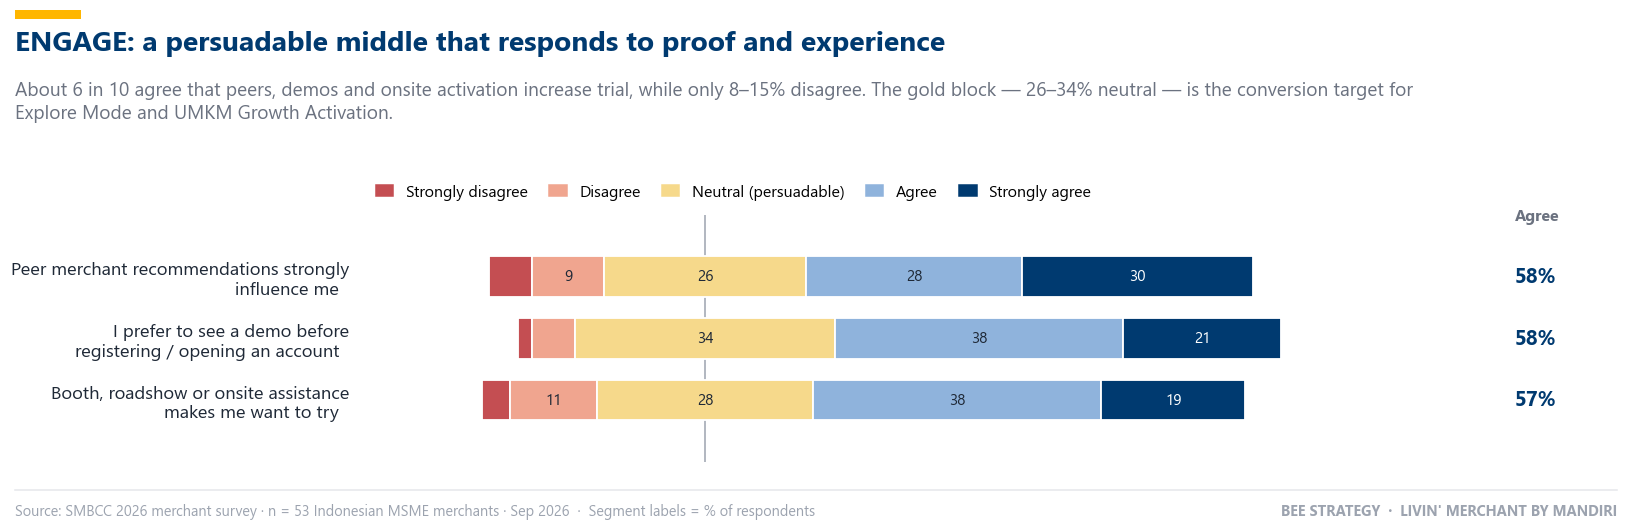

In [27]:
eng = ['Q22', 'Q19', 'Q23']
neutral_share = (df[eng] == 3).mean() * 100
fig, ax = plt.subplots(figsize=(15, 4.9))
likert(ax, df, [(None, None, eng)], {q: f'{wrap(LIKERT_EN[q], 40)}  ' for q in eng}, neutral_color='#F6D98B')
show(fig, 'ENGAGE: a persuadable middle that responds to proof and experience',
     f'About 6 in 10 agree that peers, demos and onsite activation increase trial, while only '
     f'{(df[eng]<=2).mean().min()*100:.0f}–{(df[eng]<=2).mean().max()*100:.0f}% disagree. The gold block — '
     f'{neutral_share.min():.0f}–{neutral_share.max():.0f}% neutral — is the conversion target for Explore Mode and UMKM Growth Activation.',
     name='16_engage_persuadable_middle', note='Segment labels = % of respondents')

In [28]:
so_what(f"""<b>Engaging the Market needs both engines.</b> Social media (Instagram {pct(ch['Instagram'])}, TikTok {pct(ch['TikTok'])}) creates reach —
<b>Digital Growth Marketing</b>; merchant communities, peers and roadshows ({pct(df.ch_physical.sum())} want at least one) create trust —
<b>UMKM Growth Activation / Livi Growth Van</b>. Because ENGAGE statements have the largest neutral share, the job is conversion, not awareness:
show the product (Explore Mode demo, mini business check-up), then assist the first transaction. Peer influence
({(df.Q22>=4).mean()*100:.0f}% agree, only {(df.Q22<=2).mean()*100:.0f}% disagree) justifies <b>Merchant Champions</b> as a low-CAC
acquisition channel.""", 'ENGAGE')

### 9.3 EARN — Progress & Reward → Merchant Champion · Livin' Merchant Circle

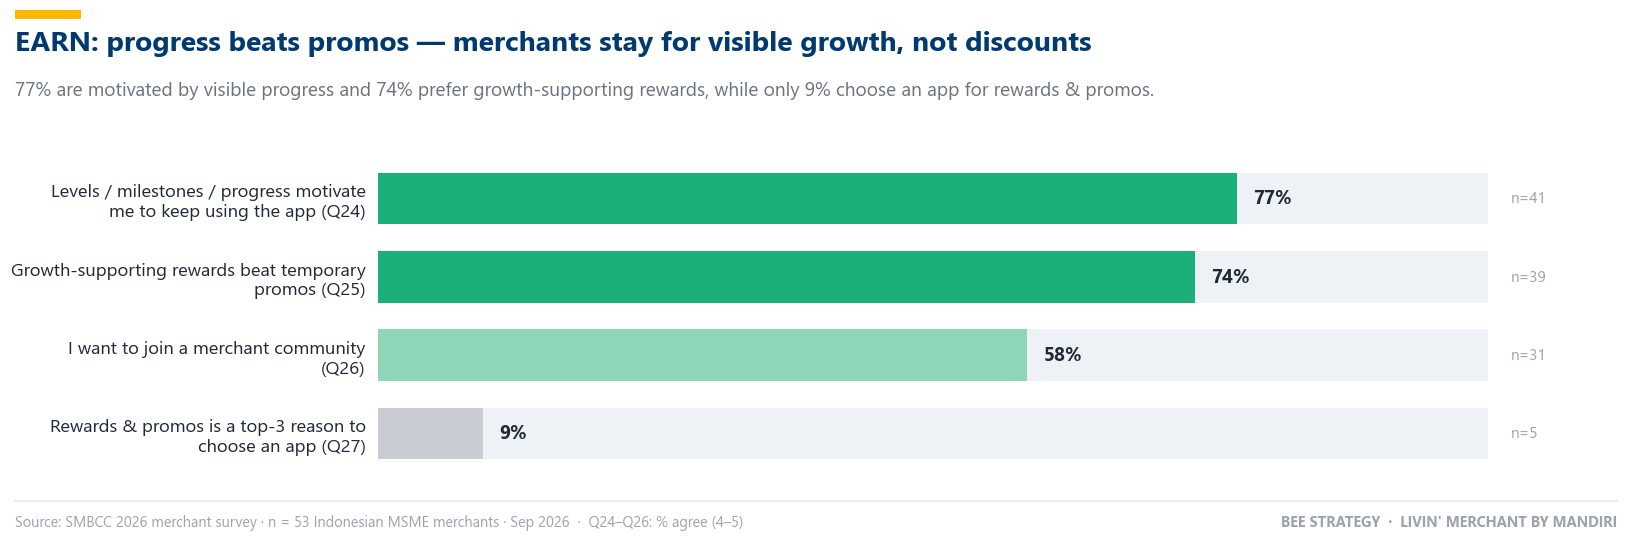

In [29]:
sf = multi_counts('selection_factors')
earn = pd.Series({
    'Levels / milestones / progress motivate me to keep using the app (Q24)': (df.Q24 >= 4).sum(),
    'Growth-supporting rewards beat temporary promos (Q25)': (df.Q25 >= 4).sum(),
    'I want to join a merchant community (Q26)': (df.Q26 >= 4).sum(),
    'Rewards & promos is a top-3 reason to choose an app (Q27)': sf.get('Rewards & promos', 0),
})
fig, ax = plt.subplots(figsize=(15, 5.0))
hbar(ax, earn, N, order=list(earn.index), wrap_w=40,
     colors=[PILLAR['EARN'], PILLAR['EARN'], '#8FD6B9', '#C9CDD3'])
show(fig, 'EARN: progress beats promos — merchants stay for visible growth, not discounts',
     f'{(df.Q24>=4).mean()*100:.0f}% are motivated by visible progress and {(df.Q25>=4).mean()*100:.0f}% prefer growth-supporting rewards, '
     f'while only {sf.get("Rewards & promos",0)/N*100:.0f}% choose an app for rewards & promos.',
     name='17_earn_progress_vs_promo', note='Q24–Q26: % agree (4–5)')

In [30]:
so_what(f"""<b>Loyalty Progress Gap confirmed — and the fix is progress, not discounts.</b> Only {sf.get('Rewards & promos',0)/N*100:.0f}% choose an app
for promos, but {(df.Q25>=4).mean()*100:.0f}% value rewards that grow the business and {(df.Q24>=4).mean()*100:.0f}% are motivated by levels /
milestones. This backs BEE's shift <b>from episodic, campaign-based rewards to continuous visible growth</b> —
<b>Business Growth Stage (BUILD → GROW → SCALE → THRIVE)</b> connected to existing Livin'poin rather than a new currency.
Community interest is positive but softer ({(df.Q26>=4).mean()*100:.0f}% agree, many neutral): launch the
<b>Livin' Merchant Circle</b> with concrete value (growth clinics, business opportunities), not as generic networking.""", 'EARN')

---
## 10. Table stakes vs differentiators — app selection factors (Q27)

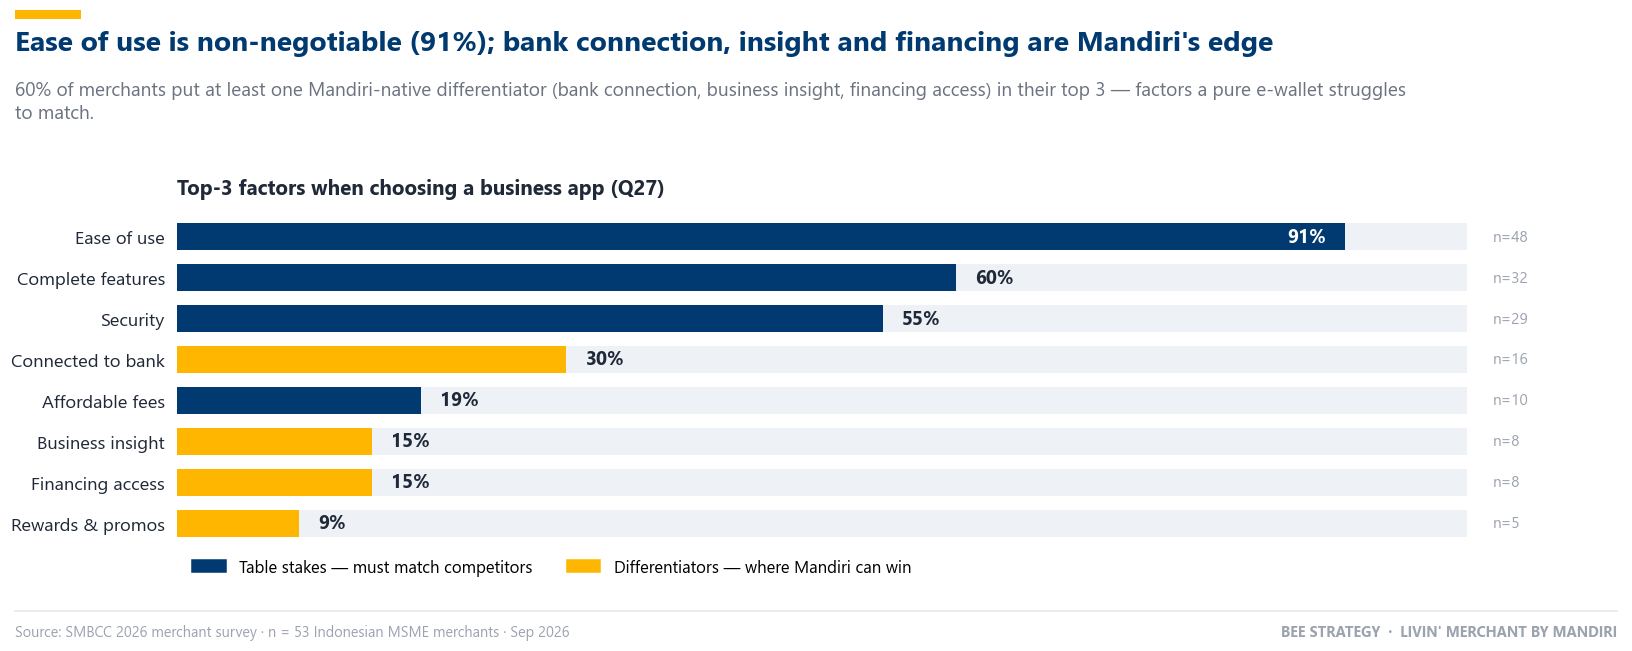

In [31]:
TABLE_STAKES = {'Ease of use', 'Security', 'Affordable fees', 'Complete features'}
fig, ax = plt.subplots(figsize=(15, 6))
hbar(ax, sf, N, colors={k: (NAVY if k in TABLE_STAKES else GOLD) for k in sf.index},
     title='Top-3 factors when choosing a business app (Q27)')
ax.legend(handles=[Patch(color=NAVY, label='Table stakes — must match competitors'),
                   Patch(color=GOLD, label='Differentiators — where Mandiri can win')], loc='upper left', bbox_to_anchor=(0, 0.0), ncol=2, fontsize=11)
diff_reach = df.selection_factors.apply(lambda l: bool(set(l) & {'Connected to bank', 'Financing access', 'Business insight'})).sum()
show(fig, f"Ease of use is non-negotiable ({pct(sf['Ease of use'])}); bank connection, insight and financing are Mandiri's edge",
     f'{pct(diff_reach)} of merchants put at least one Mandiri-native differentiator (bank connection, business insight, financing access) in their top 3 — '
     'factors a pure e-wallet struggles to match.', name='18_selection_factors')
so_what(f"""Ease of use ({pct(sf['Ease of use'])}) and security ({pct(sf['Security'])}) are <b>entry tickets</b>: BEE's Growth Engine must feel as
simple as GoPay — <i>"Comprehensive in capability, simple in experience."</i> Differentiation then comes from assets only a bank has:
<b>bank connection, business insight and financing access</b> ({pct(diff_reach)} want at least one). This is exactly the
<b>Transaction Data × Banking × Financing × Ecosystem</b> moat in the competitive-advantage slide.""", 'BUILD')

---
## 11. Feature opportunity matrix — what to build first
We combine two independent signals for each BEE feature:
* **Attraction** (x-axis): % who picked it as a top-3 reason to use Livin' Merchant (Q29);
* **Stated need** (y-axis): % agreeing with the matching Likert statement.

Dashed lines mark the averages across all options / statements. Features in the top-right are both needed and attractive → **Q1 "Build Core" roadmap priorities**.

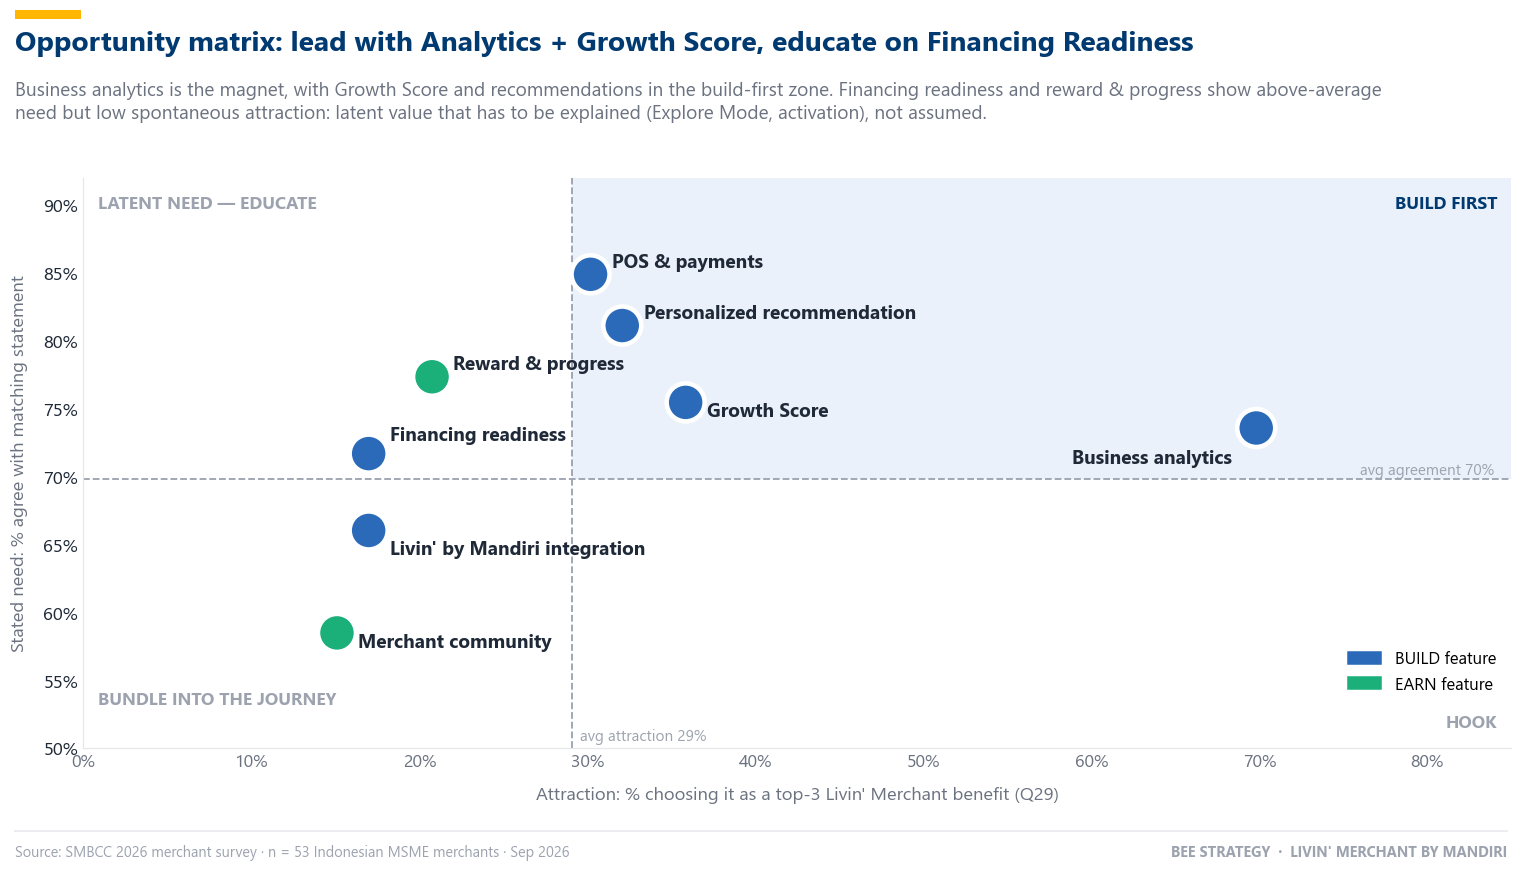

,attraction,need,item
Business analytics,70.0,74.0,Q16
Growth Score,36.0,75.0,Q12
Personalized recommendation,32.0,81.0,Q17
POS & payments,30.0,85.0,Q15
Reward & progress,21.0,77.0,Q24
Financing readiness,17.0,72.0,Q18
Livin' by Mandiri integration,17.0,66.0,Q20
Merchant community,15.0,58.0,Q26


In [32]:
PAIR = {'Business analytics': 'Q16', 'Personalized recommendation': 'Q17', 'Growth Score': 'Q12', 'Financing readiness': 'Q18',
        "Livin' by Mandiri integration": 'Q20', 'Reward & progress': 'Q24', 'Merchant community': 'Q26', 'POS & payments': 'Q15'}
PCOL = {k: 'BUILD' for k in PAIR}; PCOL.update({'Reward & progress': 'EARN', 'Merchant community': 'EARN'})
om = pd.DataFrame({'attraction': [lf.get(f, 0) / N * 100 for f in PAIR], 'need': [(df[q] >= 4).mean() * 100 for q in PAIR.values()]}, index=list(PAIR))
xm = lf.sum() / len(LAYER) / N * 100          # average pick-rate across all 10 Q29 options
ym = LK['T2B %'].mean()                        # average agreement across all 14 statements
fig, ax = plt.subplots(figsize=(14, 8))
ax.add_patch(Rectangle((xm, ym), 85 - xm, 92 - ym, color='#EAF1FA', zorder=0, lw=0))
ax.axvline(xm, color=FAINT, ls='--', lw=1.2, zorder=1); ax.axhline(ym, color=FAINT, ls='--', lw=1.2, zorder=1)
ax.scatter(om.attraction, om.need, s=620, color=[PILLAR[PCOL[i]] for i in om.index], edgecolor='white', linewidth=3, zorder=3)
offs = {'Business analytics': (-16, -20), 'Personalized recommendation': (14, 8), 'Growth Score': (14, -6), 'Financing readiness': (14, 12),
        "Livin' by Mandiri integration": (14, -12), 'Reward & progress': (14, 8), 'Merchant community': (14, -6), 'POS & payments': (14, 8)}
for i, r in om.iterrows():
    dx, dy = offs.get(i, (14, 0))
    ax.annotate(f'{i}', (r.attraction, r.need), xytext=(dx, dy), textcoords='offset points', fontsize=12.5,
                ha='right' if dx < 0 else 'left', va='center', color=INK, fontweight='bold', zorder=4)
for x_, y_, t, ha, va in [(0.99, 0.97, 'BUILD FIRST', 'right', 'top'), (0.01, 0.97, 'LATENT NEED — EDUCATE', 'left', 'top'),
                          (0.99, 0.03, 'HOOK', 'right', 'bottom'), (0.01, 0.07, 'BUNDLE INTO THE JOURNEY', 'left', 'bottom')]:
    ax.text(x_, y_, t, transform=ax.transAxes, ha=ha, va=va, fontsize=11.5, color=NAVY if t == 'BUILD FIRST' else FAINT, fontweight='bold')
ax.text(xm + 0.5, 50.6, f'avg attraction {xm:.0f}%', color=FAINT, fontsize=10)
ax.text(84, ym + 0.4, f'avg agreement {ym:.0f}%', color=FAINT, fontsize=10, ha='right')
ax.set_xlabel("Attraction: % choosing it as a top-3 Livin' Merchant benefit (Q29)", labelpad=10)
ax.set_ylabel('Stated need: % agree with matching statement', labelpad=10)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0)); ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_xlim(0, 85); ax.set_ylim(50, 92); ax.tick_params(length=0)
ax.legend(handles=[Patch(color=PILLAR['BUILD'], label='BUILD feature'), Patch(color=PILLAR['EARN'], label='EARN feature')],
          loc='lower right', bbox_to_anchor=(1, 0.07))
show(fig, 'Opportunity matrix: lead with Analytics + Growth Score, educate on Financing Readiness',
     'Business analytics is the magnet, with Growth Score and recommendations in the build-first zone. Financing readiness and reward & progress '
     'show above-average need but low spontaneous attraction: latent value that has to be explained (Explore Mode, activation), not assumed.',
     name='19_opportunity_matrix')
display(om.assign(item=[PAIR[i] for i in om.index]).round(0).sort_values('attraction', ascending=False))

---
## 12. Voice of the merchant — open-ended text analysis (Q30)
*"What is the ONE thing that would make you use a payment / business-management app routinely?"*

Answers were translated to English (translation table below), coded into themes with transparent keyword rules, and each theme is mapped to the BEE component that answers it.

In [33]:
TRANSLATE = {
    'mau dapat uang': 'I want to earn money',
    'keamanan, dan integritas': 'Security and integrity',
    'Semua terintegrasi dalam satu aplikasi sehingga tidak perlu repot secara aktif membuka banyak aplikasi': "Everything integrated in one app so I don't have to open many apps",
    'Semua transaksi dan pencatatan keuangan bisa dilakukan dalam satu aplikasi dengan cepat dan mudah': 'All transactions and financial records done in one app, quickly and easily',
    'mudah digunakan': 'Easy to use', 'Mudah': 'Easy', 'tampilan mudah digunakan': 'Easy-to-use interface',
    'Mudah dan pencairan dana nya gampang': 'Easy, and settlement is simple',
    'membutuhkan business analytics dari data transaksi': 'I need business analytics from my transaction data',
    'Integrasi': 'Integration', 'Reward dan potongan rendah': 'Rewards and low fees',
    'Pencairan dana cepat, aman, dan mudah dipantau': 'Fast, secure and trackable settlement',
    'Transaksi, laporan, dan stok bisa dilihat dalam satu tempat': 'Transactions, reports and stock visible in one place',
    'Semua kebutuhan utama usaha terintegrasi dalam satu aplikasi': 'All core business needs integrated in one app',
    'Mudah digunakan dan tidak membuat operasional tambah rumit': 'Easy to use and does not make operations more complicated',
    'Ada reward atau benefit yang mendukung perkembangan usaha': 'Rewards or benefits that support business growth',
    'Terhubung langsung dengan rekening bank dan settlement jelas': 'Directly connected to my bank account with clear settlement',
    'Ada rekomendasi yang benar-benar relevan untuk usaha saya': 'Recommendations that are truly relevant to my business',
    'Ada benefit yang terasa untuk usaha, bukan hanya promo sesaat': 'Tangible business benefits, not just short-term promos',
    'Aplikasinya stabil dan fitur yang sering dipakai mudah ditemukan': 'Stable app where frequently used features are easy to find',
    'Mudah dipelajari dan ada bantuan ketika saya bingung': 'Easy to learn, with help when I get confused',
    'Ada insight bisnis yang jelas dan mudah dipahami': 'Clear, easy-to-understand business insights',
    'Bisa membantu melihat perkembangan penjualan dari waktu ke waktu': 'Helps me see sales progress over time',
    'Bisa mengetahui kesiapan usaha untuk mengakses modal': 'Lets me know if my business is ready to access capital',
    'Keamanan transaksi dan data usaha terjamin': 'Transaction and business data security is guaranteed',
}
df['open_raw'] = df.open_answer.astype(str).str.strip().str.rstrip('.')
df['open_en'] = df.open_raw.map(TRANSLATE)
assert df.open_en.notna().all(), df.loc[df.open_en.isna(), 'open_raw'].tolist()

THEMES = {  # theme: (regex on English answer, BEE component)
    'Ease of use & simplicity':          (r'\beasy\b|easy to use|easy-to-use|easily|stable|easy to find|more complicated', 'BUILD · Simple UX'),
    'All-in-one integration':            (r'one app|one place|integrat', 'BUILD · RUN + CONNECT'),
    'Tangible growth benefits & rewards': (r'reward|benefit|earn money|low fees', 'EARN · Growth rewards'),
    'Actionable insights & recommendations': (r'insight|analytics|recommendation|sales progress', 'BUILD · UNDERSTAND'),
    'Fast & transparent settlement':     (r'settlement', 'BUILD · RUN (table stakes)'),
    'Security & trust':                  (r'secur|integrity', 'Foundation · Security-by-design'),
    'Learning support & assistance':     (r'help when|easy to learn', 'ENGAGE · Assisted activation'),
    'Bank account connection':           (r'bank account', 'BUILD · CONNECT'),
    'Financing readiness':               (r'capital', 'BUILD · GROW'),
}
for th, (rx, _) in THEMES.items():
    df[f'th_{th}'] = df.open_en.str.lower().str.contains(rx, regex=True)
theme_counts = pd.Series({th: df[f'th_{th}'].sum() for th in THEMES}).sort_values(ascending=False)
print(f'{(df[[f"th_{t}" for t in THEMES]].any(axis=1)).mean()*100:.0f}% of answers coded into at least one theme.\n')

tt = (df.groupby(['open_raw', 'open_en']).size().rename('n').reset_index().sort_values('n', ascending=False)
        .rename(columns={'open_raw': 'Original answer (Indonesian)', 'open_en': 'English translation'}))
display(tt.style.hide(axis='index').set_properties(**{'font-size': '12.5px', 'text-align': 'left'}))

100% of answers coded into at least one theme.



Original answer (Indonesian),English translation,n
"Ada benefit yang terasa untuk usaha, bukan hanya promo sesaat","Tangible business benefits, not just short-term promos",7
Ada rekomendasi yang benar-benar relevan untuk usaha saya,Recommendations that are truly relevant to my business,5
Ada reward atau benefit yang mendukung perkembangan usaha,Rewards or benefits that support business growth,4
Semua kebutuhan utama usaha terintegrasi dalam satu aplikasi,All core business needs integrated in one app,4
Mudah dipelajari dan ada bantuan ketika saya bingung,"Easy to learn, with help when I get confused",4
Mudah digunakan dan tidak membuat operasional tambah rumit,Easy to use and does not make operations more complicated,3
"Pencairan dana cepat, aman, dan mudah dipantau","Fast, secure and trackable settlement",3
Ada insight bisnis yang jelas dan mudah dipahami,"Clear, easy-to-understand business insights",2
Aplikasinya stabil dan fitur yang sering dipakai mudah ditemukan,Stable app where frequently used features are easy to find,2
"Transaksi, laporan, dan stok bisa dilihat dalam satu tempat","Transactions, reports and stock visible in one place",2


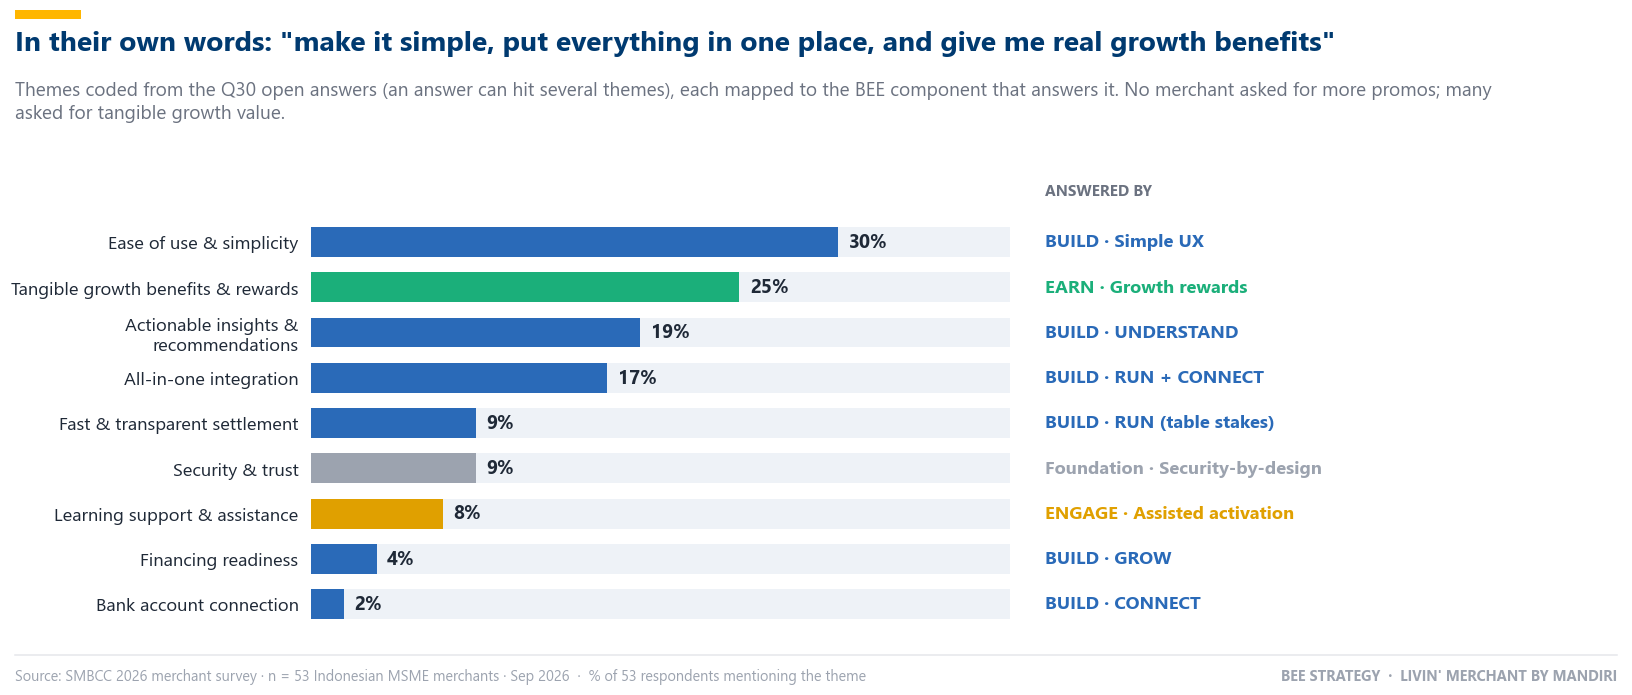

In [34]:
def theme_colour(comp):
    return PILLAR['EARN'] if comp.startswith('EARN') else PILLAR['ENGAGE'] if comp.startswith('ENGAGE') else FAINT if comp.startswith('Foundation') else BLUE
fig, ax = plt.subplots(figsize=(15, 6.4))
tc = theme_counts
hbar(ax, tc, N, colors={t: theme_colour(THEMES[t][1]) for t in tc.index}, n_labels=False, max_val=40, wrap_w=34)
ax.set_xlim(0, 75)
ax.text(42, -0.95, 'ANSWERED BY', fontsize=10, color=MUTED, fontweight='bold', va='bottom')
for i, t in enumerate(tc.index):
    ax.text(42, i, THEMES[t][1], va='center', fontsize=12, color=theme_colour(THEMES[t][1]), fontweight='bold')
show(fig, 'In their own words: "make it simple, put everything in one place, and give me real growth benefits"',
     'Themes coded from the Q30 open answers (an answer can hit several themes), each mapped to the BEE component that answers it. '
     'No merchant asked for more promos; many asked for tangible growth value.', name='20_open_answer_themes',
     note='% of 53 respondents mentioning the theme')

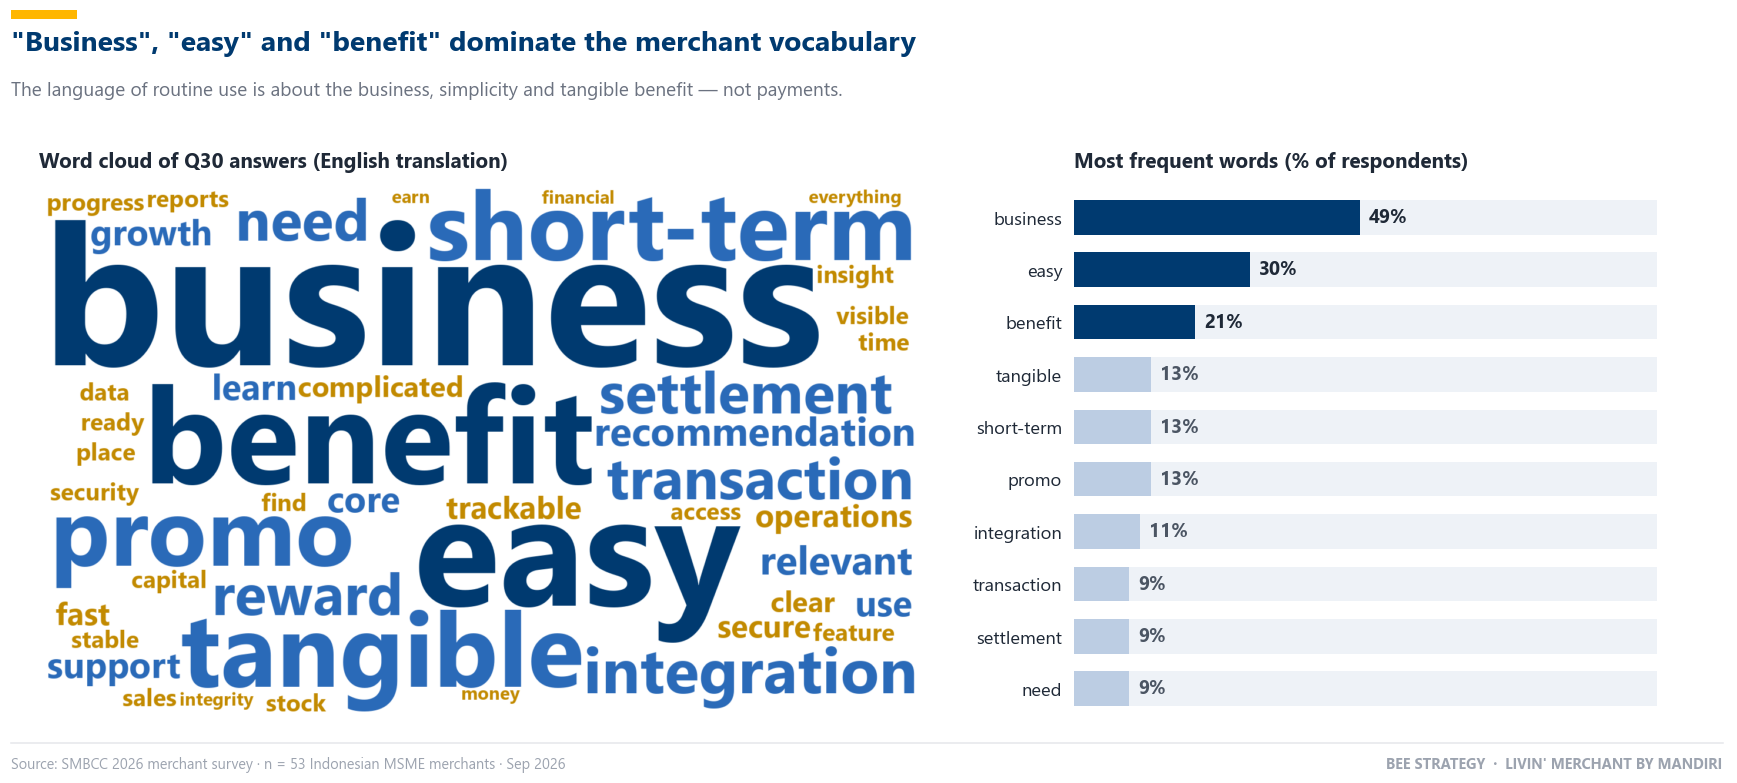

In [35]:
STOP = set(STOPWORDS) | {'app', 'apps', 'can', 'lets', 'know', 'make', 'see', 'want', 'just', 'truly', 'done', 'get', 'will', 'help',
                         'helps', 'frequently', 'used', 'directly', 'confused', 'much', 'many', 'open', 'things', 'one'}
NORM = {'integrated': 'integration', 'recommendations': 'recommendation', 'benefits': 'benefit', 'rewards': 'reward',
        'insights': 'insight', 'transactions': 'transaction', 'records': 'record', 'needs': 'need', 'easily': 'easy',
        'easy-to-use': 'easy', 'easy-to-understand': 'easy', 'promos': 'promo', 'features': 'feature'}
tokens = []
for s in df.open_en.str.lower():
    for w in re.findall(r"[a-z][a-z\-']+", s):
        w = NORM.get(w, w)
        if w not in STOP and len(w) > 2:
            tokens.append(w)
freq = Counter(tokens)
top = pd.Series(dict(freq.most_common(10)))

def brand_color(word, **kw):
    return NAVY if freq[word] >= 8 else (BLUE if freq[word] >= 4 else '#c28a00')

font = 'C:/Windows/Fonts/segoeuib.ttf'
wc = WordCloud(width=1500, height=900, background_color='white', prefer_horizontal=1.0, max_words=45, font_path=font if os.path.exists(font) else None,
               color_func=brand_color, collocations=False, margin=10, random_state=3).generate_from_frequencies(freq)
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(16, 7.2), gridspec_kw={'width_ratios': [1.45, 1]})
ax0.imshow(wc, interpolation='bilinear'); ax0.axis('off')
ax0.set_title('Word cloud of Q30 answers (English translation)', loc='left', pad=12)
hbar(ax1, top, N, highlight=3, title='Most frequent words (% of respondents)', n_labels=False)
show(fig, f'"{top.index[0].capitalize()}", "{top.index[1]}" and "{top.index[2]}" dominate the merchant vocabulary',
     'The language of routine use is about the business, simplicity and tangible benefit — not payments.',
     name='21_word_cloud_frequency')

In [36]:
so_what(f"""The unprompted voice of the merchant reproduces BEE almost exactly: <b>simplicity</b> ({theme_counts['Ease of use & simplicity']} mentions) and
<b>all-in-one integration</b> ({theme_counts['All-in-one integration']}) → BUILD · RUN & CONNECT; <b>tangible growth benefits, not promos</b>
({theme_counts['Tangible growth benefits & rewards']}) → EARN; <b>relevant insights & recommendations</b> ({theme_counts['Actionable insights & recommendations']})
→ BUILD · UNDERSTAND; <b>help when confused</b> ({theme_counts['Learning support & assistance']}) → ENGAGE assisted activation.
Quote for the deck: <i>"Tangible business benefits, not just short-term promos."</i>""")

---
## 13. Segment analysis — grouping insights by respondent characteristics
We compare agreement (% agree) across six respondent characteristics: **business type, tenure, transaction volume, digital maturity, recording style and Livin' awareness**. The heatmap prints each segment's % agree and colours the cell by how far it sits **above (blue) or below (orange) the overall result** — so the eye goes straight to where segments differ. Differences are tested with **Kruskal–Wallis** (3 groups) or **Mann–Whitney U** (2 groups). With subgroup sizes of 9–36 these tests are *exploratory*: we flag p < 0.10 and treat them as hypotheses for the pilot, not proof.

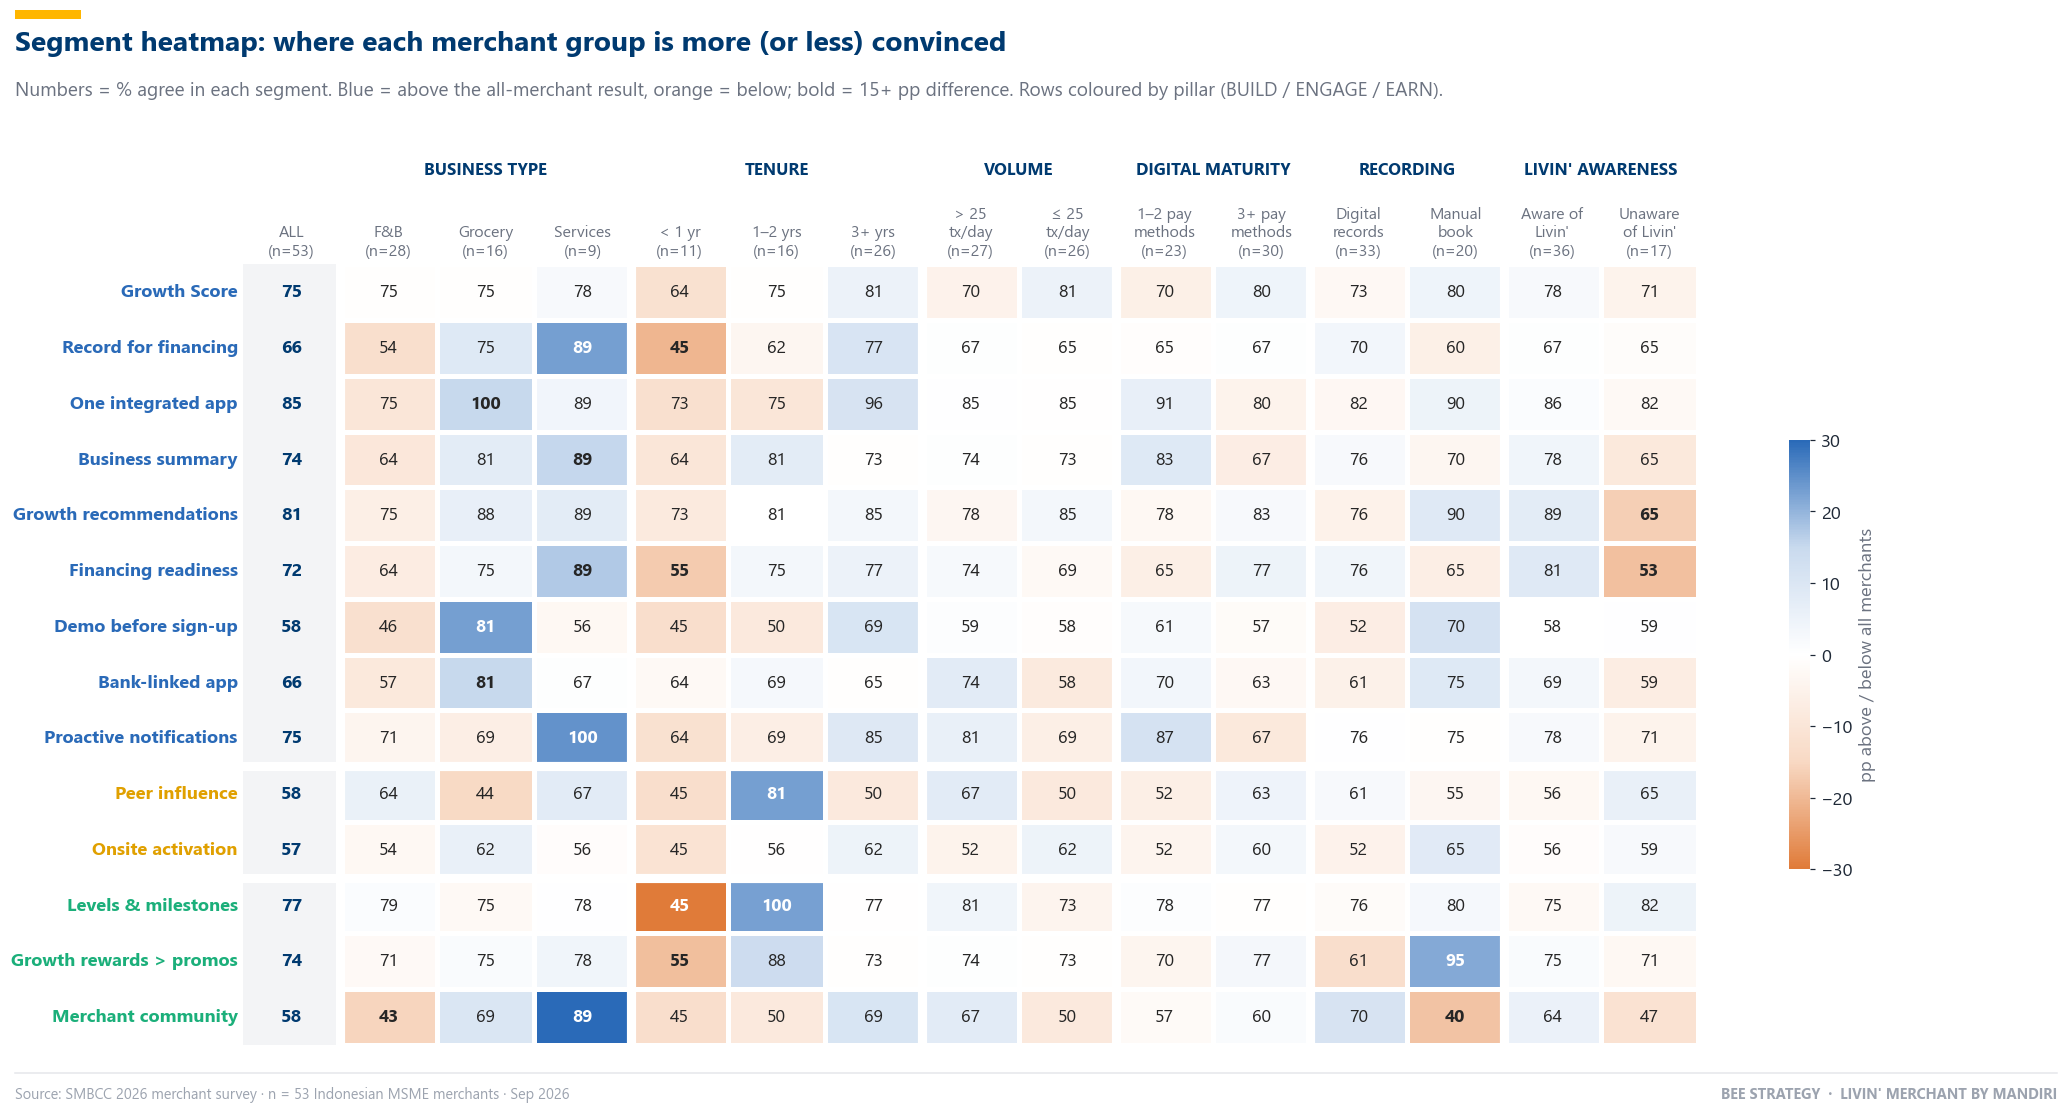

In [37]:
cols, heat, groups_n = [], [], []
for d, lab in SEGS.items():
    gs_ = list(df.groupby(d, observed=True))
    groups_n.append((lab, len(gs_)))
    for k, g in gs_:
        cols.append(f'{wrap(SHORT[k], 9)}\n(n={len(g)})')
        heat.append(((g[LIKERT_ITEMS] >= 4).mean() * 100).values)
H = pd.DataFrame(np.array(heat).T, index=[SHORT_FEATURE[q] for q in LIKERT_ITEMS], columns=cols)
H.insert(0, f'ALL\n(n={N})', t2b_all.values)
D = H.sub(H.iloc[:, 0], axis=0)

fig, ax = plt.subplots(figsize=(19, 10.2))
sns.heatmap(D, annot=H.round(0).astype(int), fmt='d', cmap=DIV, center=0, vmin=-30, vmax=30, linewidths=2, linecolor='white', ax=ax,
            cbar_kws={'label': 'pp above / below all merchants', 'shrink': 0.55}, annot_kws={'fontsize': 11.5})
ncols = D.shape[1]
for idx, (t, dv) in enumerate(zip(ax.texts, D.values.flatten())):
    if idx % ncols == 0:                      # ALL column: reference values in navy on grey
        t.set_color(NAVY); t.set_fontweight('bold'); t.set_fontsize(12)
    elif abs(dv) >= 15:
        t.set_fontweight('bold')
ax.add_patch(Rectangle((0, 0), 1, len(D), fill=True, color='#F3F4F6', zorder=1.5))
bounds = np.cumsum([1] + [k for _, k in groups_n])
for b_ in bounds[:-1]: ax.axvline(b_, color='white', lw=6)
x0 = 1
for lab, k in groups_n:
    ax.text(x0 + k / 2, -1.55, lab.upper(), ha='center', va='bottom', fontsize=11, fontweight='bold', color=NAVY)
    x0 += k
ax.xaxis.tick_top(); ax.tick_params(axis='x', labelsize=10.5, length=0, rotation=0); ax.tick_params(axis='y', labelsize=12, length=0)
for t, q in zip(ax.get_yticklabels(), LIKERT_ITEMS): t.set_color(PILLAR[PILLAR_OF[q]]); t.set_fontweight('bold')
for b_ in [9, 11]: ax.axhline(b_, color='white', lw=6)
show(fig, 'Segment heatmap: where each merchant group is more (or less) convinced',
     'Numbers = % agree in each segment. Blue = above the all-merchant result, orange = below; bold = 15+ pp difference. '
     'Rows coloured by pillar (BUILD / ENGAGE / EARN).', name='22_segment_heatmap')

In [38]:
def seg_test(d, item):
    groups = [g[item].values for _, g in df.groupby(d, observed=True)]
    if len(groups) == 2:
        return stats.mannwhitneyu(*groups, alternative='two-sided').pvalue
    return stats.kruskal(*groups).pvalue

P = pd.DataFrame({lab: [seg_test(d, q) for q in LIKERT_ITEMS + IDX] for d, lab in SEGS.items()},
                 index=[f'{q} · {BEE_FEATURE[q]}' for q in LIKERT_ITEMS] + ['BUILD index', 'ENGAGE index', 'EARN index'])
display(P.style.format('{:.3f}').applymap(lambda v: 'background-color:#003A70;color:white;font-weight:bold' if v < 0.05
                                          else ('background-color:#BCCDE3' if v < 0.10 else '')).set_caption(
        'p-values of segment differences (dark = p < 0.05, light = p < 0.10) — exploratory, uncorrected'))

sig = []
for d, lab in SEGS.items():
    for q in LIKERT_ITEMS + IDX:
        p_ = seg_test(d, q)
        if p_ < 0.10:
            gm = df.groupby(d, observed=True)[q].mean()
            sig.append({'Characteristic': lab, 'Item': q, 'p': round(p_, 3), 'Highest group': f'{gm.idxmax()} ({gm.max():.2f})',
                        'Lowest group': f'{gm.idxmin()} ({gm.min():.2f})'})
SIG = pd.DataFrame(sig).sort_values('p')
display(SIG.style.hide(axis='index').set_caption('Segment differences with p < 0.10'))

,Business type,Tenure,Volume,Digital maturity,Recording,Livin' awareness
Q12 · Growth Score,0.397,0.203,0.278,0.962,0.673,0.375
Q14 · Data-to-financing incentive,0.024,0.214,0.745,0.844,0.863,0.292
Q15 · Integrated app (RUN),0.305,0.201,0.223,0.043,0.209,0.786
Q16 · Business insights (UNDERSTAND),0.036,0.305,0.639,0.454,0.323,0.355
Q17 · Growth Mission / Next Best Action,0.164,0.431,0.501,0.862,0.280,0.019
Q18 · Financing Readiness (GROW),0.560,0.078,0.536,0.449,0.594,0.077
Q19 · Explore Mode (EXPLORE),0.186,0.209,0.764,0.902,0.266,0.896
Q20 · Livin' ecosystem (CONNECT),0.250,0.544,0.253,0.619,0.220,0.537
Q21 · Proactive notification (ACT),0.170,0.389,0.381,0.010,0.205,0.541
Q22 · Merchant Champion / WOM,0.582,0.082,0.293,0.515,0.812,0.898


Characteristic,Item,p,Highest group,Lowest group
Recording,Q25,0.007000,Still uses manual book (4.45),Fully digital recording (3.67)
Digital maturity,Q21,0.010000,Basic (1–2 methods) (4.52),Multi-channel (3+ methods) (3.83)
Livin' awareness,Q17,0.019000,"Heard of it, never used (4.42)",Never heard of it (3.88)
Business type,idx_BUILD,0.021000,Services (4.28),Food & Beverage (3.82)
Business type,Q14,0.024000,Services (4.44),Food & Beverage (3.46)
Business type,Q16,0.036000,Grocery / Kiosk (4.38),Food & Beverage (3.57)
Recording,Q26,0.039000,Fully digital recording (3.76),Still uses manual book (3.10)
Digital maturity,Q15,0.043000,Basic (1–2 methods) (4.57),Multi-channel (3+ methods) (4.17)
Livin' awareness,idx_BUILD,0.045000,"Heard of it, never used (4.10)",Never heard of it (3.82)
Business type,Q26,0.067000,Services (4.00),Food & Beverage (3.25)


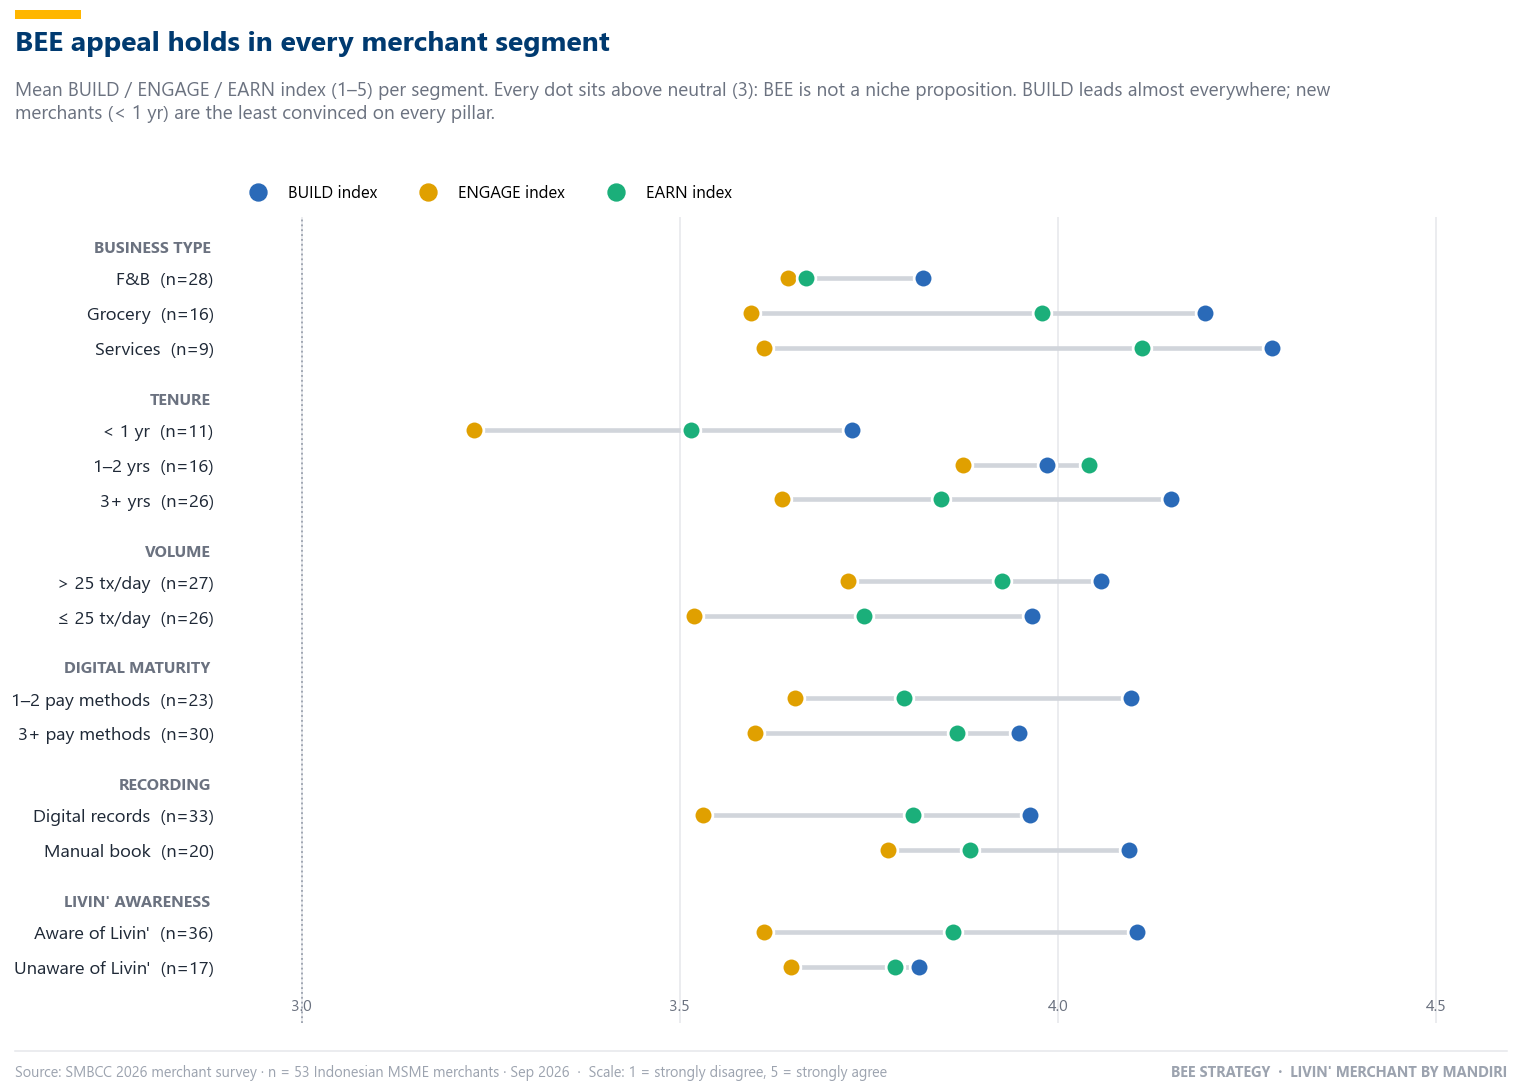

In [39]:
rows_seg = []
for d, lab in SEGS.items():
    for k, g in df.groupby(d, observed=True):
        rows_seg.append((lab, f'{SHORT[str(k)]}  (n={len(g)})', g[IDX].mean().values))
fig, ax = plt.subplots(figsize=(14, 10))
y, yt, yl, prev = 0, [], [], None
for lab, name, vals in rows_seg:
    if lab != prev:
        if prev is not None: y += 0.5
        ax.text(-0.012, y, lab.upper(), transform=ax.get_yaxis_transform(), ha='right', va='center', fontsize=10.5, fontweight='bold', color=MUTED)
        y += 0.85; prev = lab
    ax.plot([vals.min(), vals.max()], [y, y], color='#D1D5DB', lw=3, zorder=1, solid_capstyle='round')
    for v, p in zip(vals, PILLAR):
        ax.scatter(v, y, s=150, color=PILLAR[p], edgecolor='white', linewidth=1.8, zorder=3)
    yt.append(y); yl.append(name); y += 1
for xv in [3.0, 3.5, 4.0, 4.5]:
    ax.axvline(xv, color=GRID, lw=1, zorder=0)
    ax.text(xv, y - 0.1, f'{xv:.1f}', ha='center', va='top', fontsize=10.5, color=MUTED)
ax.axvline(3, color=FAINT, lw=1.2, ls=':', zorder=0)
ax.set_yticks(yt); ax.set_yticklabels(yl); ax.set_ylim(y + 0.6, -0.9); ax.set_xlim(2.9, 4.6); ax.set_xticks([]); clean(ax)
ax.tick_params(axis='y', pad=8)
ax.legend(handles=[Line2D([], [], marker='o', ls='', markersize=11, color=c, label=f'{p} index') for p, c in PILLAR.items()],
          ncol=3, loc='lower left', bbox_to_anchor=(0, 1.0))
show(fig, 'BEE appeal holds in every merchant segment',
     'Mean BUILD / ENGAGE / EARN index (1–5) per segment. Every dot sits above neutral (3): BEE is not a niche proposition. '
     'BUILD leads almost everywhere; new merchants (< 1 yr) are the least convinced on every pillar.',
     name='23_pillar_by_segment', note='Scale: 1 = strongly disagree, 5 = strongly agree')

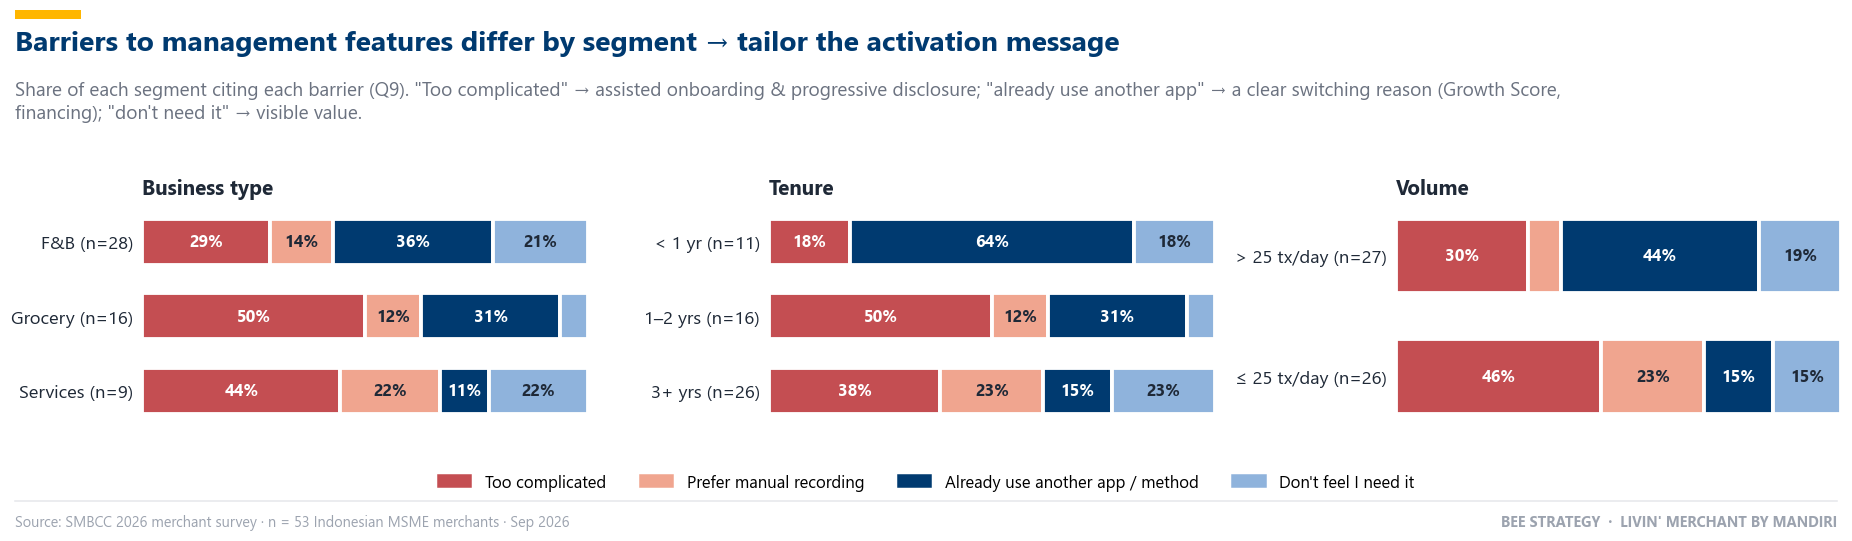

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.0))
BAR_ORDER = ['Too complicated', 'Prefer manual recording', 'Already use another app / method', "Don't feel I need it"]
for ax, d in zip(axes, ['business_type', 'seg_tenure', 'seg_volume']):
    ct = pd.crosstab(df[d], df.mgmt_barrier, normalize='index').reindex(columns=BAR_ORDER, fill_value=0) * 100
    n = df[d].value_counts()
    lft = np.zeros(len(ct))
    for c in BAR_ORDER:
        ax.barh([f'{SHORT[k]} (n={n[k]})' for k in ct.index], ct[c], left=lft, color=bar_col[c], edgecolor='white', linewidth=2.5, height=0.62)
        for i, (l, w) in enumerate(zip(lft, ct[c])):
            if w >= 11: ax.text(l + w / 2, i, f'{w:.0f}%', ha='center', va='center', fontsize=11, fontweight='bold',
                                color='white' if c in ('Too complicated', 'Already use another app / method') else INK)
        lft += ct[c].values
    ax.set_xlim(0, 100); ax.set_xticks([]); ax.invert_yaxis(); clean(ax); ax.tick_params(axis='y', pad=6)
    ax.set_title(SEGS[d], loc='left', pad=10)
fig.legend(handles=[Patch(color=bar_col[c], label=c) for c in BAR_ORDER], ncol=4, loc='lower center', bbox_to_anchor=(0.5, 0.075), fontsize=11)
show(fig, 'Barriers to management features differ by segment → tailor the activation message',
     'Share of each segment citing each barrier (Q9). "Too complicated" → assisted onboarding & progressive disclosure; '
     '"already use another app" → a clear switching reason (Growth Score, financing); "don\'t need it" → visible value.',
     name='24_barrier_by_segment', bottom=0.45)

In [41]:
# Automated segment read-out -------------------------------------------------------
lines = []
for d, lab in SEGS.items():
    t2b = df.groupby(d, observed=True)[LIKERT_ITEMS].apply(lambda x: (x >= 4).mean() * 100)
    spread = (t2b.max() - t2b.min()).sort_values(ascending=False)
    q = spread.index[0]
    hi, lo = t2b[q].idxmax(), t2b[q].idxmin()
    lines.append(f"- **{lab}** — biggest gap on *{q} · {BEE_FEATURE[q]}*: **{hi}** {t2b.loc[hi, q]:.0f}% vs **{lo}** {t2b.loc[lo, q]:.0f}% agree "
                 f"({spread.iloc[0]:.0f} pp).")
display(Markdown('#### Largest segment differences (percentage points of agreement)\n' + '\n'.join(lines)))

#### Largest segment differences (percentage points of agreement)
- **Business type** — biggest gap on *Q26 · Livin' Merchant Circle*: **Services** 89% vs **Food & Beverage** 43% agree (46 pp).
- **Tenure** — biggest gap on *Q24 · Business Growth Stage*: **Growing (1–2 yrs)** 100% vs **New (< 1 yr)** 45% agree (55 pp).
- **Volume** — biggest gap on *Q26 · Livin' Merchant Circle*: **High volume (> 25 tx/day)** 67% vs **Low volume (≤ 25 tx/day)** 50% agree (17 pp).
- **Digital maturity** — biggest gap on *Q21 · Proactive notification (ACT)*: **Basic (1–2 methods)** 87% vs **Multi-channel (3+ methods)** 67% agree (20 pp).
- **Recording** — biggest gap on *Q25 · Growth-based rewards*: **Still uses manual book** 95% vs **Fully digital recording** 61% agree (34 pp).
- **Livin' awareness** — biggest gap on *Q18 · Financing Readiness (GROW)*: **Heard of it, never used** 81% vs **Never heard of it** 53% agree (28 pp).

#### Segment insights: who to target with what
These findings are exploratory (p < 0.10, small subgroups). Treat them as pilot hypotheses.

| Characteristic | What the data suggests | BEE implication |
|---|---|---|
| **Business type** | **Services** merchants have the highest BUILD index (4.28 vs F&B 3.82, p = 0.02), would record for financing more often (89% vs 54%, p = 0.02) and want community most (89%). **Grocery** merchants value business insights (81%), the one-app idea (100%), Explore Mode (81%) and bank linkage (81%). **F&B**, the largest group, is the hardest to convince (Explore Mode 46%, community 43%) but still wants the Growth Score (75%) | Pilot BUILD with services and grocery. For F&B (persona "Andi"), lead with simple outcomes and assisted activation |
| **Tenure** | **New merchants (< 1 yr)** score lowest almost everywhere (e.g. milestones 45%, financing motivation 45%). **Growing merchants (1–2 yrs)** peak on EARN: 100% are motivated by milestones, 88% prefer growth rewards, 81% are influenced by peers. **Established merchants (3+ yrs)** want one integrated app (96%), financing readiness (77%) and notifications (85%) | New: RUN simplicity first. Growing: **Growth Stage + Merchant Champion** candidates. Established: **Financing Readiness + CONNECT** |
| **Livin' awareness** | Merchants who have heard of Livin' Merchant but never used it want recommendations (89% vs 65%, p = 0.02) and financing readiness (81% vs 53%) more than unaware merchants | Aware non-users are **warm leads**. Convert them by showing Growth features (Explore Mode), not with more brand advertising |
| **Recording style** | Merchants who still use a manual book value growth rewards most (95% vs 61%, p = 0.007) but are less interested in community (40% vs 70%) | Use reward-for-progress to move manual merchants onto digital recording |
| **Digital maturity** | Merchants with only 1–2 payment methods value notifications (87% vs 67%, p = 0.01) and one integrated app (91% vs 80%) more | Proactive Next Best Action is especially relevant for less digitally mature merchants |
| **Volume** | No significant differences between high- and low-volume merchants | BEE appeals regardless of business size, so a broad target is justified |

---
## 14. What goes together — attitude links & drivers
Which attitudes move together? We use **Spearman rank correlation** (appropriate for ordinal Likert data) and show only the strongest links rather than a full 14 × 14 matrix. Two driver questions matter for the BEE flywheel:
1. What goes with interest in a **Growth Score / business-health** view (Q12)?
2. What goes with willingness to **record transactions routinely for financing eligibility** (Q14) — the data engine behind Financing Readiness?

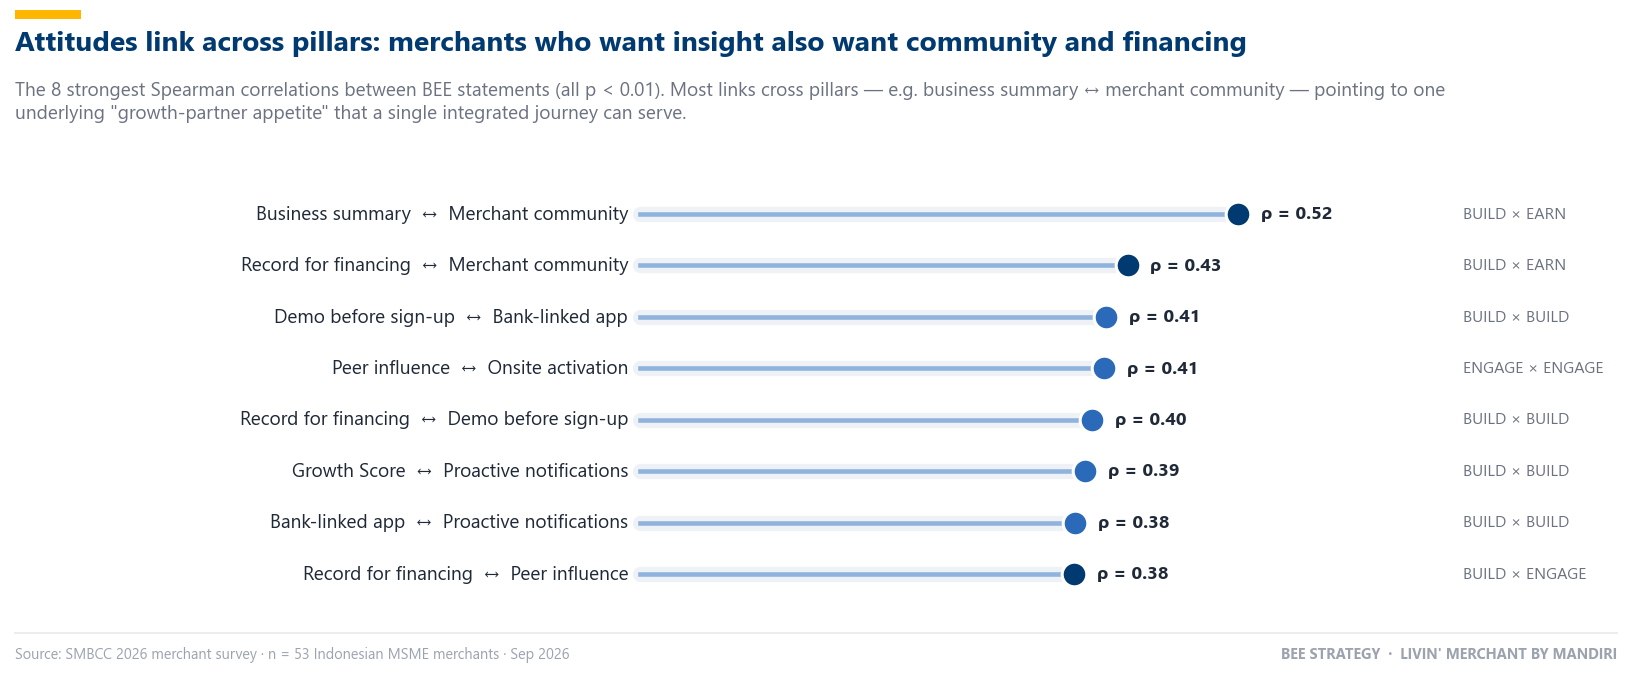

In [42]:
corr = df[LIKERT_ITEMS].corr(method='spearman')
pairs = corr.where(~np.tril(np.ones_like(corr, dtype=bool))).stack().sort_values(ascending=False)
top_pairs = pairs.head(8)
fig, ax = plt.subplots(figsize=(15, 6.2))
for i, ((a, b), v) in enumerate(top_pairs.items()):
    cross = PILLAR_OF[a] != PILLAR_OF[b]
    ax.plot([0, v], [i, i], color=TRACK, lw=10, solid_capstyle='round', zorder=1)
    ax.plot([0, v], [i, i], color='#8FB3DC', lw=3, zorder=2)
    ax.scatter(v, i, s=260, color=NAVY if cross else BLUE, edgecolor='white', linewidth=2, zorder=3)
    ax.text(v + 0.02, i, f'ρ = {v:.2f}', va='center', fontsize=12, fontweight='bold', color=INK)
    ax.text(-0.01, i, f'{SHORT_FEATURE[a]}  ↔  {SHORT_FEATURE[b]}', ha='right', va='center', fontsize=12.5, color=INK)
    ax.text(0.72, i, f'{PILLAR_OF[a]} × {PILLAR_OF[b]}', va='center', fontsize=10.5, color=MUTED)
ax.set_xlim(-0.55, 0.85); ax.set_ylim(len(top_pairs) - 0.4, -0.7); ax.axis('off')
fig.subplots_adjust(left=0.05)
show(fig, 'Attitudes link across pillars: merchants who want insight also want community and financing',
     f'The 8 strongest Spearman correlations between BEE statements (all p < 0.01). Most links cross pillars — e.g. business summary ↔ merchant '
     'community — pointing to one underlying "growth-partner appetite" that a single integrated journey can serve.',
     name='25_attitude_links')

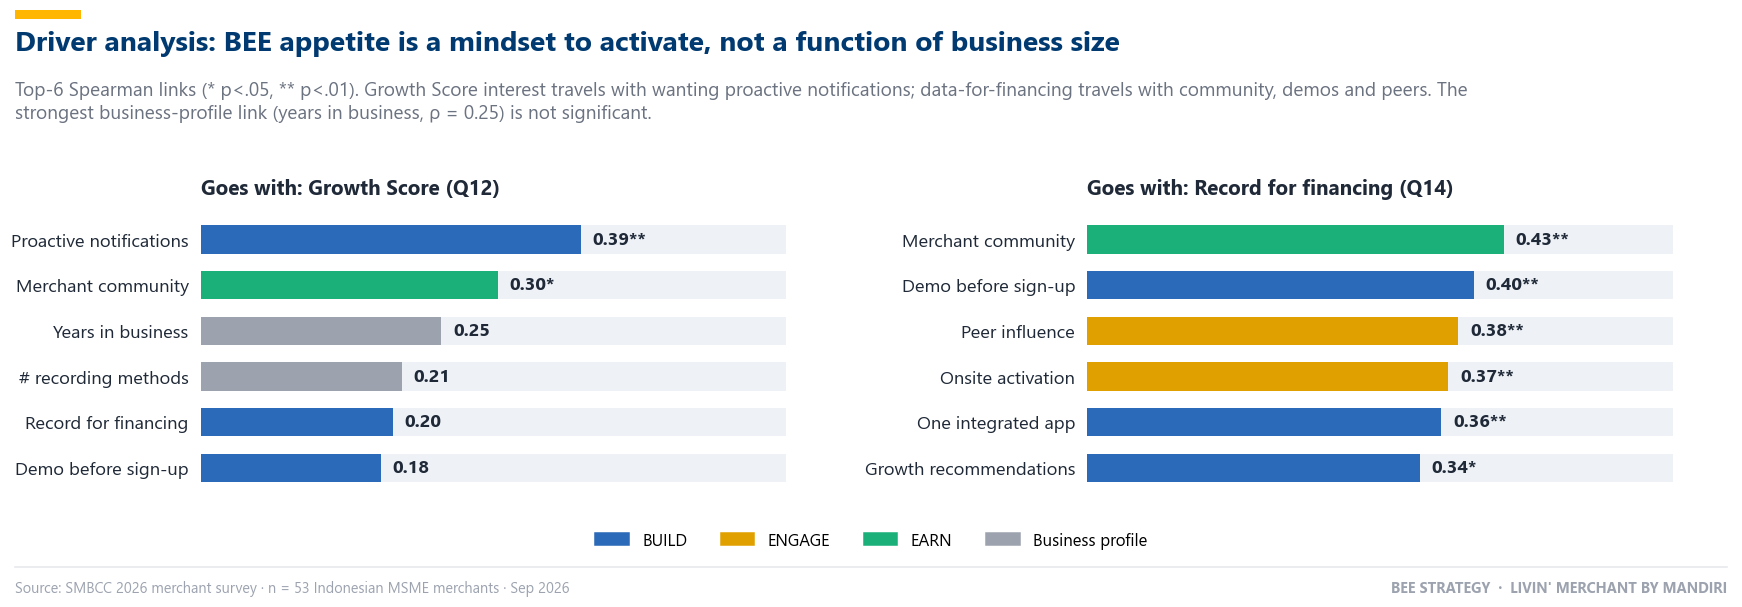

In [43]:
PROFILE_VARS = {'tenure_ord': 'Years in business', 'daily_tx_ord': 'Daily transactions',
                'n_payment_methods': '# payment methods', 'n_recording_methods': '# recording methods', 'aware_livin': "Aware of Livin'"}
def drivers(target):
    rows = []
    for v in [q for q in LIKERT_ITEMS if q != target] + list(PROFILE_VARS):
        r, p_ = stats.spearmanr(df[v].astype(float), df[target])
        rows.append((SHORT_FEATURE.get(v, PROFILE_VARS.get(v)), r, p_, PILLAR_OF.get(v, 'PROFILE')))
    return pd.DataFrame(rows, columns=['var', 'rho', 'p', 'group']).sort_values('rho', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.6))
for ax, tgt in zip(axes, ['Q12', 'Q14']):
    Dd = drivers(tgt).head(6).iloc[::-1]
    c = [PILLAR.get(g, FAINT) for g in Dd.group]
    ax.barh(range(len(Dd)), 0.6, color=TRACK, height=0.62, zorder=0)
    ax.barh(range(len(Dd)), Dd.rho, color=c, height=0.62, zorder=2)
    for i, (r, p_) in enumerate(zip(Dd.rho, Dd.p)):
        star = '***' if p_ < .001 else '**' if p_ < .01 else '*' if p_ < .05 else ''
        ax.text(r + 0.012, i, f'{r:.2f}{star}', va='center', ha='left', fontsize=12, fontweight='bold', color=INK)
    ax.set_yticks(range(len(Dd))); ax.set_yticklabels(Dd['var']); ax.set_xlim(0, 0.66); ax.set_xticks([]); clean(ax)
    ax.tick_params(axis='y', pad=8)
    ax.set_title(f'Goes with: {SHORT_FEATURE[tgt]} ({tgt})', loc='left', pad=12)
fig.legend(handles=[Patch(color=c, label=p) for p, c in {**PILLAR, 'Business profile': FAINT}.items()], ncol=4,
           loc='lower center', bbox_to_anchor=(0.5, 0.08), fontsize=11)
prof12 = drivers('Q12').query('group == "PROFILE"').iloc[0]
show(fig, 'Driver analysis: BEE appetite is a mindset to activate, not a function of business size',
     f'Top-6 Spearman links (* p<.05, ** p<.01). Growth Score interest travels with wanting proactive notifications; data-for-financing travels '
     f'with community, demos and peers. The strongest business-profile link ({prof12["var"].lower()}, ρ = {prof12["rho"]:.2f}) is not significant.',
     name='26_driver_analysis', bottom=0.4)

In [44]:
d12, d14 = drivers('Q12'), drivers('Q14')
so_what(f"""Interest in a Growth Score (Q12) is most closely linked with <b>{d12.iloc[0]['var']}</b> (ρ = {d12.iloc[0]['rho']:.2f}) and
<b>{d12.iloc[1]['var']}</b> (ρ = {d12.iloc[1]['rho']:.2f}); readiness to record transactions for financing (Q14) moves with
<b>{d14.iloc[0]['var']}</b> (ρ = {d14.iloc[0]['rho']:.2f}). Business-profile variables are weak predictors, so BEE should target by
<b>attitude and behaviour signals inside the app</b> (e.g. merchants who open analytics or complete missions) — exactly what the
Mandiri intelligence layer and Proactive Next Best Action enable.""")

---
## 15. Merchant personas
We cluster respondents on their 14 Likert answers (standardised) with **K-Means** and profile each cluster by attitudes and business characteristics.

**Choosing k honestly.** All silhouette scores are low (≤ 0.15, table below): merchant attitudes form a *continuum*, not sharply separated groups. k = 2 only splits high vs low appetite; **k = 3** adds an interpretable middle persona, so we use the personas as a **targeting lens, not a hard taxonomy**.

In [45]:
X = StandardScaler().fit_transform(df[LIKERT_ITEMS])
sel = []
for k in range(2, 7):
    km_ = KMeans(n_clusters=k, n_init=50, random_state=42).fit(X)
    sel.append({'k': k, 'Silhouette': silhouette_score(X, km_.labels_), 'Inertia': km_.inertia_})
display(pd.DataFrame(sel).style.format({'Silhouette': '{:.3f}', 'Inertia': '{:.0f}'}).hide(axis='index'))

K = 3
km = KMeans(n_clusters=K, n_init=100, random_state=42).fit(X)
df['cluster'] = km.labels_
order = df.groupby('cluster')['idx_BEE'].mean().sort_values(ascending=False).index   # highest appetite first
df['cluster'] = df.cluster.map({c: i for i, c in enumerate(order)})
PERSONA = {0: 'Growth Seekers', 1: 'Simplicity-first Operators', 2: 'Self-reliant Sceptics'}   # named from the profiles below
PERSONA_COL = {0: NAVY, 1: VIOLET, 2: '#c28a00'}
df['persona'] = df.cluster.map(PERSONA)
sizes = df.persona.value_counts().reindex(PERSONA.values())
print(df.groupby('persona')[IDX + ['idx_BEE']].mean().reindex(PERSONA.values()).round(2))

k,Silhouette,Inertia
2,0.152,629
3,0.093,578
4,0.105,535
5,0.103,502
6,0.103,465


                            idx_BUILD  idx_ENGAGE  idx_EARN  idx_BEE
persona                                                             
Growth Seekers                   4.35        3.98      4.12     4.25
Simplicity-first Operators       3.76        3.47      3.58     3.68
Self-reliant Sceptics            3.44        2.85      3.43     3.36


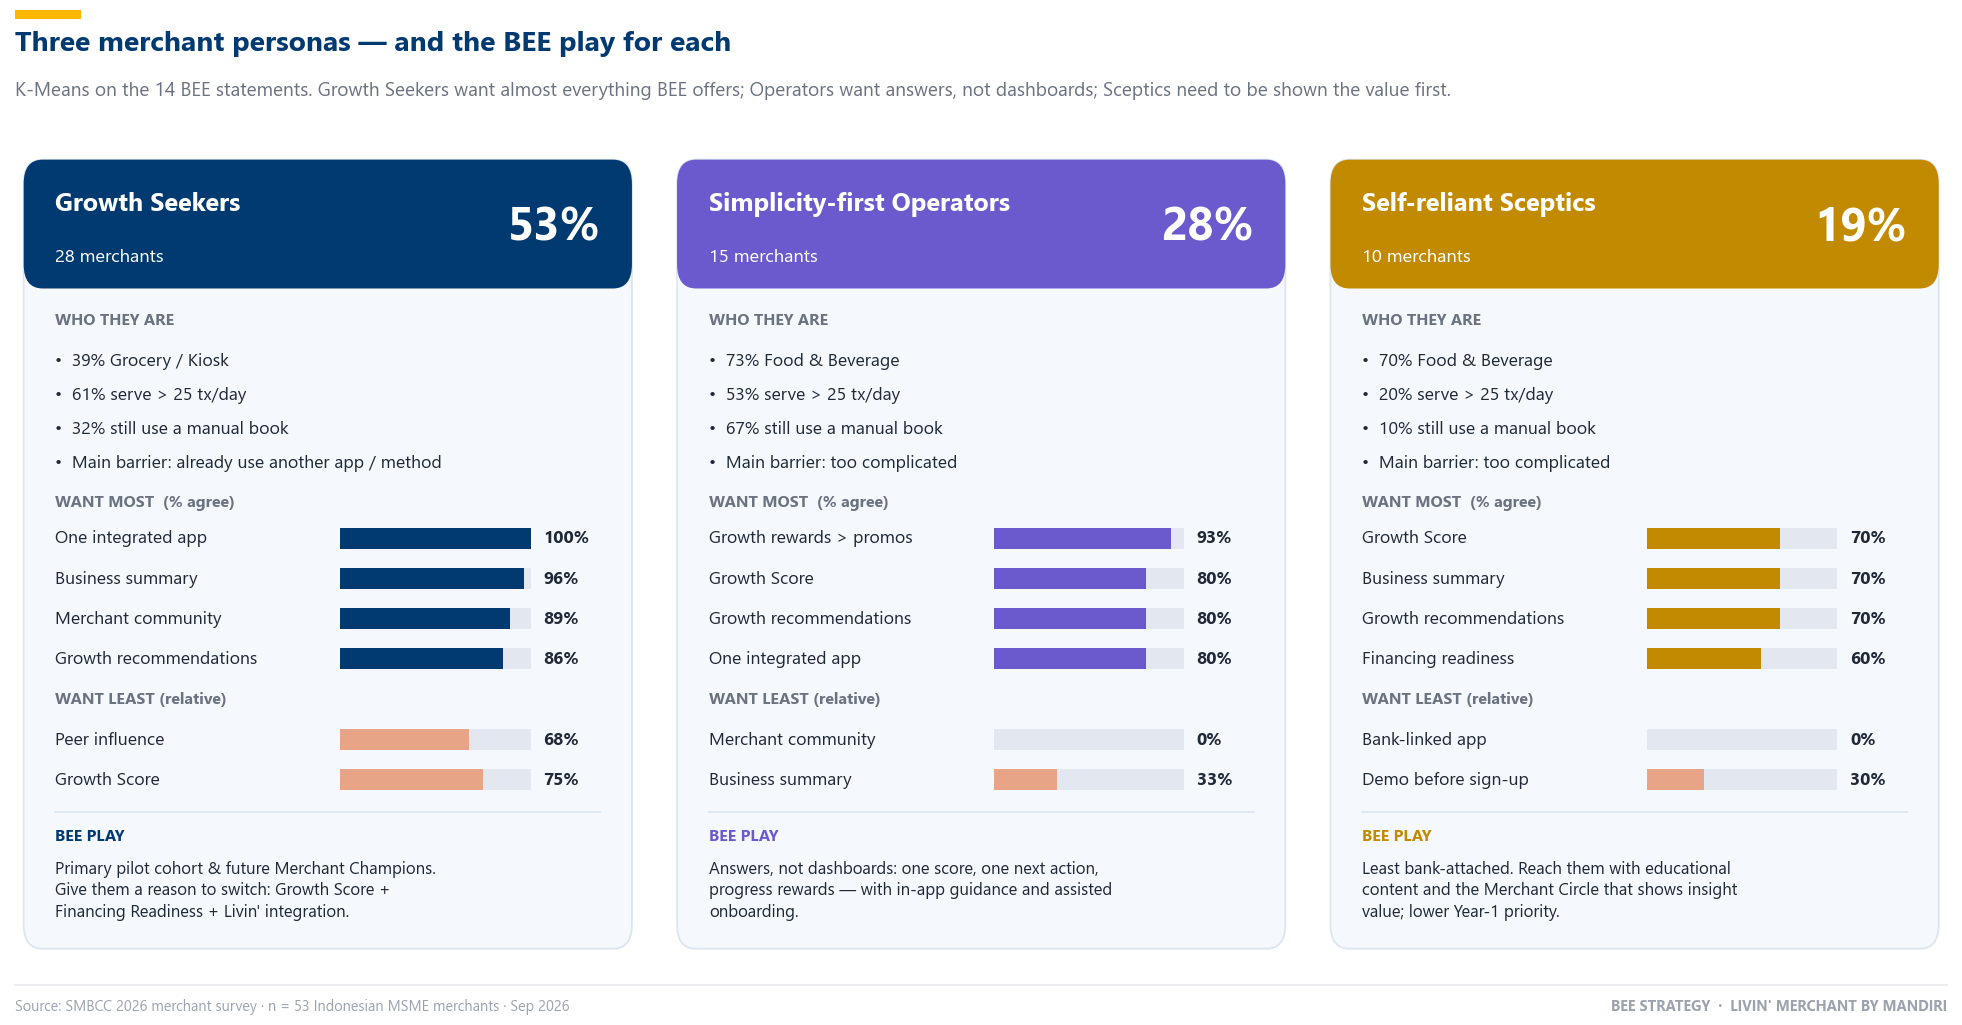

In [46]:
PLAY = {0: "Primary pilot cohort & future Merchant Champions. Give them a reason to switch: Growth Score + Financing Readiness + Livin' integration.",
        1: 'Answers, not dashboards: one score, one next action, progress rewards — with in-app guidance and assisted onboarding.',
        2: 'Least bank-attached. Reach them with educational content and the Merchant Circle that shows insight value; lower Year-1 priority.'}
fig, axes = plt.subplots(1, 3, figsize=(18, 9.4))
for ax, (c, name) in zip(axes, PERSONA.items()):
    g = df[df.cluster == c]; col = PERSONA_COL[c]
    t2b = (g[LIKERT_ITEMS] >= 4).mean() * 100
    ax.axis('off')
    ax.add_patch(FancyBboxPatch((0.02, 0.01), 0.96, 0.98, boxstyle='round,pad=0,rounding_size=0.03', transform=ax.transAxes,
                                facecolor=CARD, edgecolor='#DCE6F2', lw=1.2))
    ax.add_patch(FancyBboxPatch((0.02, 0.83), 0.96, 0.16, boxstyle='round,pad=0,rounding_size=0.03', transform=ax.transAxes,
                                facecolor=col, edgecolor='none'))
    ax.text(0.07, 0.935, name, transform=ax.transAxes, fontsize=16.5, fontweight='bold', color='white', va='center')
    ax.text(0.07, 0.87, f'{len(g)} merchants', transform=ax.transAxes, fontsize=12, color='white', va='center')
    ax.text(0.93, 0.905, f'{len(g)/N*100:.0f}%', transform=ax.transAxes, fontsize=30, fontweight='bold', color='white', va='center', ha='right')
    bt = g.business_type.mode()[0]
    facts = [f'{(g.business_type == bt).mean()*100:.0f}% {bt}', f'{(g.daily_tx_ord >= 3).mean()*100:.0f}% serve > 25 tx/day',
             f'{g.uses_manual_book.mean()*100:.0f}% still use a manual book', f'Main barrier: {g.mgmt_barrier.mode()[0].lower()}']
    ax.text(0.07, 0.785, 'WHO THEY ARE', transform=ax.transAxes, fontsize=10.5, fontweight='bold', color=MUTED)
    for i, f in enumerate(facts):
        ax.text(0.07, 0.74 - i * 0.042, f'•  {f}', transform=ax.transAxes, fontsize=11.5, color=INK, va='center')
    ax.text(0.07, 0.56, 'WANT MOST  (% agree)', transform=ax.transAxes, fontsize=10.5, fontweight='bold', color=MUTED)
    best, worst = t2b.sort_values(ascending=False).head(4), t2b.sort_values().head(2)
    for i, (q, v) in enumerate(list(best.items()) + [(None, None)] + list(worst.items())):
        if q is None:
            ax.text(0.07, 0.52 - i * 0.05, 'WANT LEAST (relative)', transform=ax.transAxes, fontsize=10.5, fontweight='bold', color=MUTED, va='center'); continue
        yy = 0.52 - i * 0.05
        ax.text(0.07, yy, SHORT_FEATURE[q], transform=ax.transAxes, fontsize=11.5, color=INK, va='center')
        ax.add_patch(Rectangle((0.52, yy - 0.013), 0.3, 0.026, transform=ax.transAxes, color='#E3E8F0', lw=0))
        ax.add_patch(Rectangle((0.52, yy - 0.013), 0.3 * v / 100, 0.026, transform=ax.transAxes, color=col if q in best.index else '#E7A487', lw=0))
        ax.text(0.84, yy, f'{v:.0f}%', transform=ax.transAxes, fontsize=11.5, fontweight='bold', color=INK, va='center')
    ax.plot([0.07, 0.93], [0.18, 0.18], transform=ax.transAxes, color='#DCE6F2', lw=1.2)
    ax.text(0.07, 0.15, 'BEE PLAY', transform=ax.transAxes, fontsize=10.5, fontweight='bold', color=col, va='center')
    ax.text(0.07, 0.12, wrap(PLAY[c], 52), transform=ax.transAxes, fontsize=11, color=INK, va='top', linespacing=1.35)
show(fig, 'Three merchant personas — and the BEE play for each',
     'K-Means on the 14 BEE statements. Growth Seekers want almost everything BEE offers; Operators want answers, not dashboards; '
     'Sceptics need to be shown the value first.', name='27_persona_cards')

In [47]:
profile_rows = []
for c, p in PERSONA.items():
    g = df[df.persona == p]
    profile_rows.append({
        'Persona': p, 'n': len(g), 'Share': f'{len(g)/N*100:.0f}%',
        'BUILD idx': g.idx_BUILD.mean(), 'ENGAGE idx': g.idx_ENGAGE.mean(), 'EARN idx': g.idx_EARN.mean(),
        'Top business type': f"{g.business_type.mode()[0]} ({(g.business_type == g.business_type.mode()[0]).mean()*100:.0f}%)",
        '3+ yrs in business': f'{(g.tenure_ord >= 3).mean()*100:.0f}%',
        '> 25 tx/day': f'{(g.daily_tx_ord >= 3).mean()*100:.0f}%',
        'Uses manual book': f'{g.uses_manual_book.mean()*100:.0f}%',
        "Aware of Livin'": f'{g.aware_livin.mean()*100:.0f}%',
        'Top barrier (Q9)': g.mgmt_barrier.mode()[0],
        "Top Livin' feature (Q29)": g.livin_features.explode().mode()[0],
        'Top channel (Q28)': g.media_channels.explode().mode()[0],
        'Top Q30 theme': max(THEMES, key=lambda t: g[f'th_{t}'].sum()),
    })
PROFILE = pd.DataFrame(profile_rows).set_index('Persona')
display(PROFILE.T.style.format(lambda v: f'{v:.2f}' if isinstance(v, float) else v)
        .set_properties(**{'font-size': '12.5px', 'text-align': 'left'}))
cm = df.groupby('persona')[LIKERT_ITEMS].apply(lambda x: (x >= 4).mean() * 100).reindex(PERSONA.values()).T
cm.index = [f'{q} · {BEE_FEATURE[q]}' for q in LIKERT_ITEMS]
display(cm.round(0).astype(int).style.background_gradient(cmap=SEQ, vmin=0, vmax=100).set_caption('% agree with each BEE statement by persona'))

Persona,Growth Seekers,Simplicity-first Operators,Self-reliant Sceptics
n,28,15,10
Share,53%,28%,19%
BUILD idx,4.35,3.76,3.44
ENGAGE idx,3.98,3.47,2.85
EARN idx,4.12,3.58,3.43
Top business type,Grocery / Kiosk (39%),Food & Beverage (73%),Food & Beverage (70%)
3+ yrs in business,54%,47%,40%
> 25 tx/day,61%,53%,20%
Uses manual book,32%,67%,10%
Aware of Livin',79%,53%,60%


persona,Growth Seekers,Simplicity-first Operators,Self-reliant Sceptics
Q12 · Growth Score,75,80,70
Q14 · Data-to-financing incentive,86,40,50
Q15 · Integrated app (RUN),100,80,50
Q16 · Business insights (UNDERSTAND),96,33,70
Q17 · Growth Mission / Next Best Action,86,80,70
Q18 · Financing Readiness (GROW),86,53,60
Q19 · Explore Mode (EXPLORE),79,40,30
Q20 · Livin' ecosystem (CONNECT),86,73,0
Q21 · Proactive notification (ACT),86,80,40
Q22 · Merchant Champion / WOM,68,60,30


#### Persona playbook
| Persona | Share | Profile | What they want | BEE playbook |
|---|---|---|---|---|
| **Growth Seekers** | 53% | More grocery & services, 61% above 25 tx/day, 79% aware of Livin' Merchant. Main barrier: *already use another app* | Nearly everything: one app 100%, business insights 96%, community 89%, financing motivation 86%, Livin' integration 86% | **Primary pilot cohort and future Merchant Champions.** They need a reason to switch: Growth Score + Financing Readiness + Livin' by Mandiri integration |
| **Simplicity-first Operators** | 28% | 73% F&B, 67% still use a manual book, 60% say tools are *too complicated* | Growth rewards 93%, recommendations 80%, Growth Score 80%, notifications 80%. Business dashboards only 33%, community 0%, roadshow 33% | Give answers, not dashboards: **one score, one next action, progress rewards**, with in-app guidance and assisted onboarding. Don't send them to community events |
| **Self-reliant Sceptics** | 19% | 70% F&B, 80% low volume, 40% under 1 year old, 90% already record digitally | Insights 70%, recommendations 70%, community/learning 60%. Bank linkage 0%, peer influence 30%, growth rewards 30% | Least bank-attached. Reach them through **educational content and the Merchant Circle** that shows insight value. Lower priority for Year 1 |

---
## 16. Problem gap validation scorecard
Each of the three root-cause gaps is scored with the survey indicators that measure it. Bars show the share of merchants for whom the gap is present (or for whom the BEE remedy is wanted).

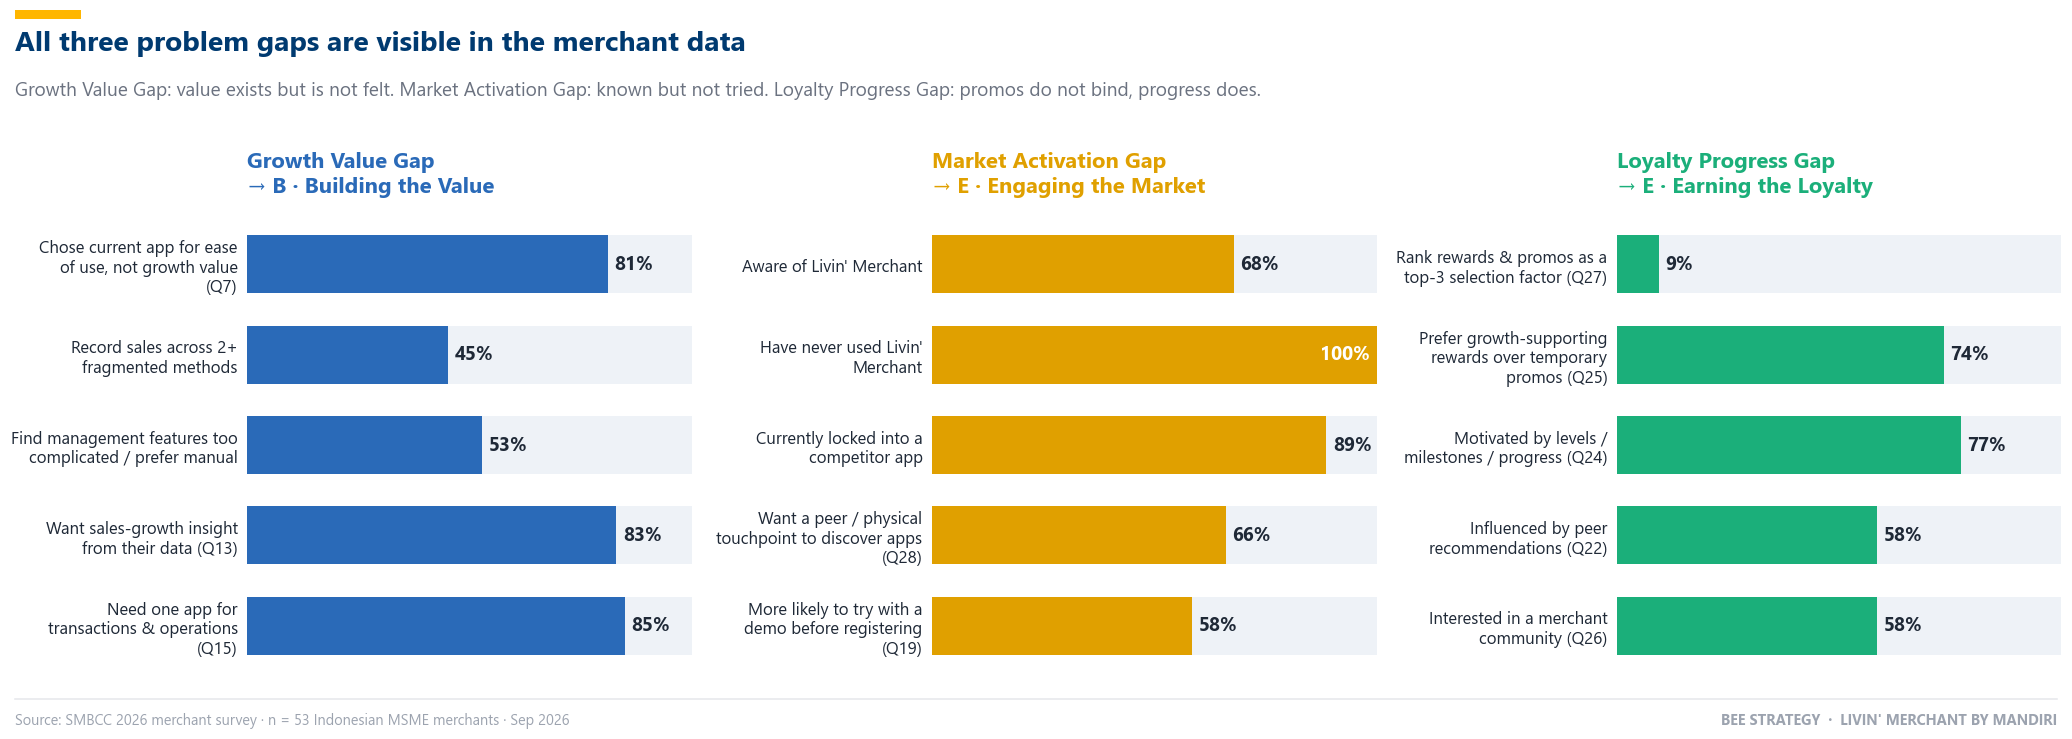

In [48]:
gap_evidence = {
    'Growth Value Gap': [
        ('Chose current app for ease of use, not growth value (Q7)', df.app_reasons.apply(lambda l: 'Easy to use' in l).mean() * 100),
        ('Record sales across 2+ fragmented methods', (df.n_recording_methods >= 2).mean() * 100),
        ('Find management features too complicated / prefer manual', df.mgmt_barrier.isin(['Too complicated', 'Prefer manual recording']).mean() * 100),
        ('Want sales-growth insight from their data (Q13)', df.info_wanted.apply(lambda l: 'Sales growth' in l).mean() * 100),
        ('Need one app for transactions & operations (Q15)', (df.Q15 >= 4).mean() * 100),
    ],
    'Market Activation Gap': [
        ("Aware of Livin' Merchant", df.aware_livin.mean() * 100),
        ("Have never used Livin' Merchant", 100.0),
        ('Currently locked into a competitor app', df.has_dedicated_app.mean() * 100),
        ('Want a peer / physical touchpoint to discover apps (Q28)', df.ch_physical.mean() * 100),
        ('More likely to try with a demo before registering (Q19)', (df.Q19 >= 4).mean() * 100),
    ],
    'Loyalty Progress Gap': [
        ('Rank rewards & promos as a top-3 selection factor (Q27)', sf.get('Rewards & promos', 0) / N * 100),
        ('Prefer growth-supporting rewards over temporary promos (Q25)', (df.Q25 >= 4).mean() * 100),
        ('Motivated by levels / milestones / progress (Q24)', (df.Q24 >= 4).mean() * 100),
        ('Influenced by peer recommendations (Q22)', (df.Q22 >= 4).mean() * 100),
        ('Interested in a merchant community (Q26)', (df.Q26 >= 4).mean() * 100),
    ],
}
GAP_COL = {'Growth Value Gap': PILLAR['BUILD'], 'Market Activation Gap': PILLAR['ENGAGE'], 'Loyalty Progress Gap': PILLAR['EARN']}
GAP_PILLAR = {'Growth Value Gap': 'B · Building the Value', 'Market Activation Gap': 'E · Engaging the Market', 'Loyalty Progress Gap': 'E · Earning the Loyalty'}
fig, axes = plt.subplots(1, 3, figsize=(19, 6.8))
for ax, (gap, ev) in zip(axes, gap_evidence.items()):
    labs = [wrap(l, 28) for l, _ in ev]; vals = [v for _, v in ev]
    y = np.arange(len(vals))
    ax.barh(y, 100, color=TRACK, height=0.64, zorder=0)
    ax.barh(y, vals, color=GAP_COL[gap], height=0.64, zorder=2)
    for yi, v in zip(y, vals):
        _bar_label(ax, v, yi, 100)
    ax.set_yticks(y); ax.set_yticklabels(labs, fontsize=11); ax.set_ylim(len(vals) - 0.5, -0.6)
    ax.set_xlim(0, 100); ax.set_xticks([]); clean(ax); ax.tick_params(axis='y', pad=6)
    ax.set_title(f'{gap}\n→ {GAP_PILLAR[gap]}', loc='left', pad=12, color=GAP_COL[gap], fontsize=14.5)
show(fig, 'All three problem gaps are visible in the merchant data',
     'Growth Value Gap: value exists but is not felt. Market Activation Gap: known but not tried. Loyalty Progress Gap: promos do not bind, progress does.',
     name='28_gap_scorecard')

---
## 17. Links to the Bank Mandiri & Bank Indonesia agenda
The survey results connect directly to the national payment-system and financial-inclusion agenda. External figures below are contextual and **should be re-verified against the official Bank Indonesia / OJK / Bank Mandiri publications before the final deck**.

| National / Mandiri agenda | What the survey shows | BEE response |
|---|---|---|
| **Bank Indonesia — QRIS as the national QR payment standard** and the push to digitalise MSME payments (Indonesian Payment System Blueprint) | QRIS acceptance is already as common as cash in the sample — payment digitalisation has largely succeeded at the counter | Move the value conversation *beyond* acceptance: turn QRIS transactions into business intelligence (**RUN → UNDERSTAND → GROW**) |
| **OJK — financial literacy trails financial inclusion** (national literacy & inclusion survey, SNLIK) | "Too complicated" is the #1 barrier to business-management features; merchants ask for "help when I'm confused" | Progressive-disclosure UX, Explore Mode, assisted onboarding via **UMKM Growth Activation** |
| **MSME financing access** (government & bank push for productive MSME credit) | Majority want to know their financing readiness and would record more routinely if it improved eligibility | **Financing Readiness** as an indicator that *enriches* Mandiri's existing credit assessment — never an automatic approval |
| **Bank Mandiri — Livin' ecosystem strategy** (Livin' by Mandiri super-app + Livin' Merchant) | Merchants prefer an app linked to their bank account; bank connection is a top-3 selection factor for a meaningful minority | **CONNECT**: One merchant, one ecosystem, one growth journey — CASA, cross-sell and richer first-party data for Mandiri |
| **Data protection (UU PDP)** | Security is the #3 selection factor and appears unprompted in open answers | Security-by-design, explicit consent for data-driven scoring, transparent Growth Score explanation |

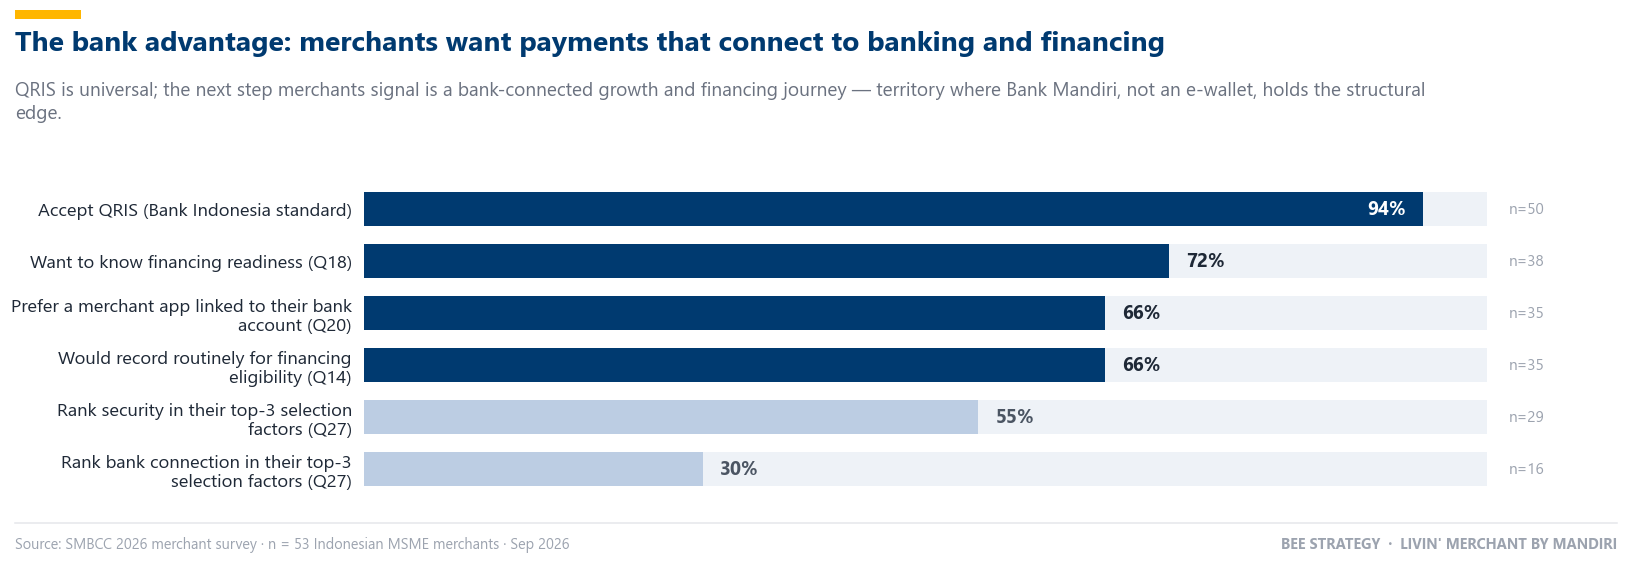

In [49]:
bank_stats = pd.Series({
    'Accept QRIS (Bank Indonesia standard)': df.accepts_qris.sum(),
    'Want to know financing readiness (Q18)': (df.Q18 >= 4).sum(),
    'Prefer a merchant app linked to their bank account (Q20)': (df.Q20 >= 4).sum(),
    'Would record routinely for financing eligibility (Q14)': (df.Q14 >= 4).sum(),
    'Rank security in their top-3 selection factors (Q27)': sf['Security'],
    'Rank bank connection in their top-3 selection factors (Q27)': sf['Connected to bank'],
})
fig, ax = plt.subplots(figsize=(15, 5.2))
hbar(ax, bank_stats, N, highlight=4, order=list(bank_stats.index), wrap_w=44)
show(fig, 'The bank advantage: merchants want payments that connect to banking and financing',
     'QRIS is universal; the next step merchants signal is a bank-connected growth and financing journey — territory where Bank Mandiri, '
     'not an e-wallet, holds the structural edge.', name='29_bank_agenda')

---
## 18. BEE Evidence Board — slide-ready synthesis

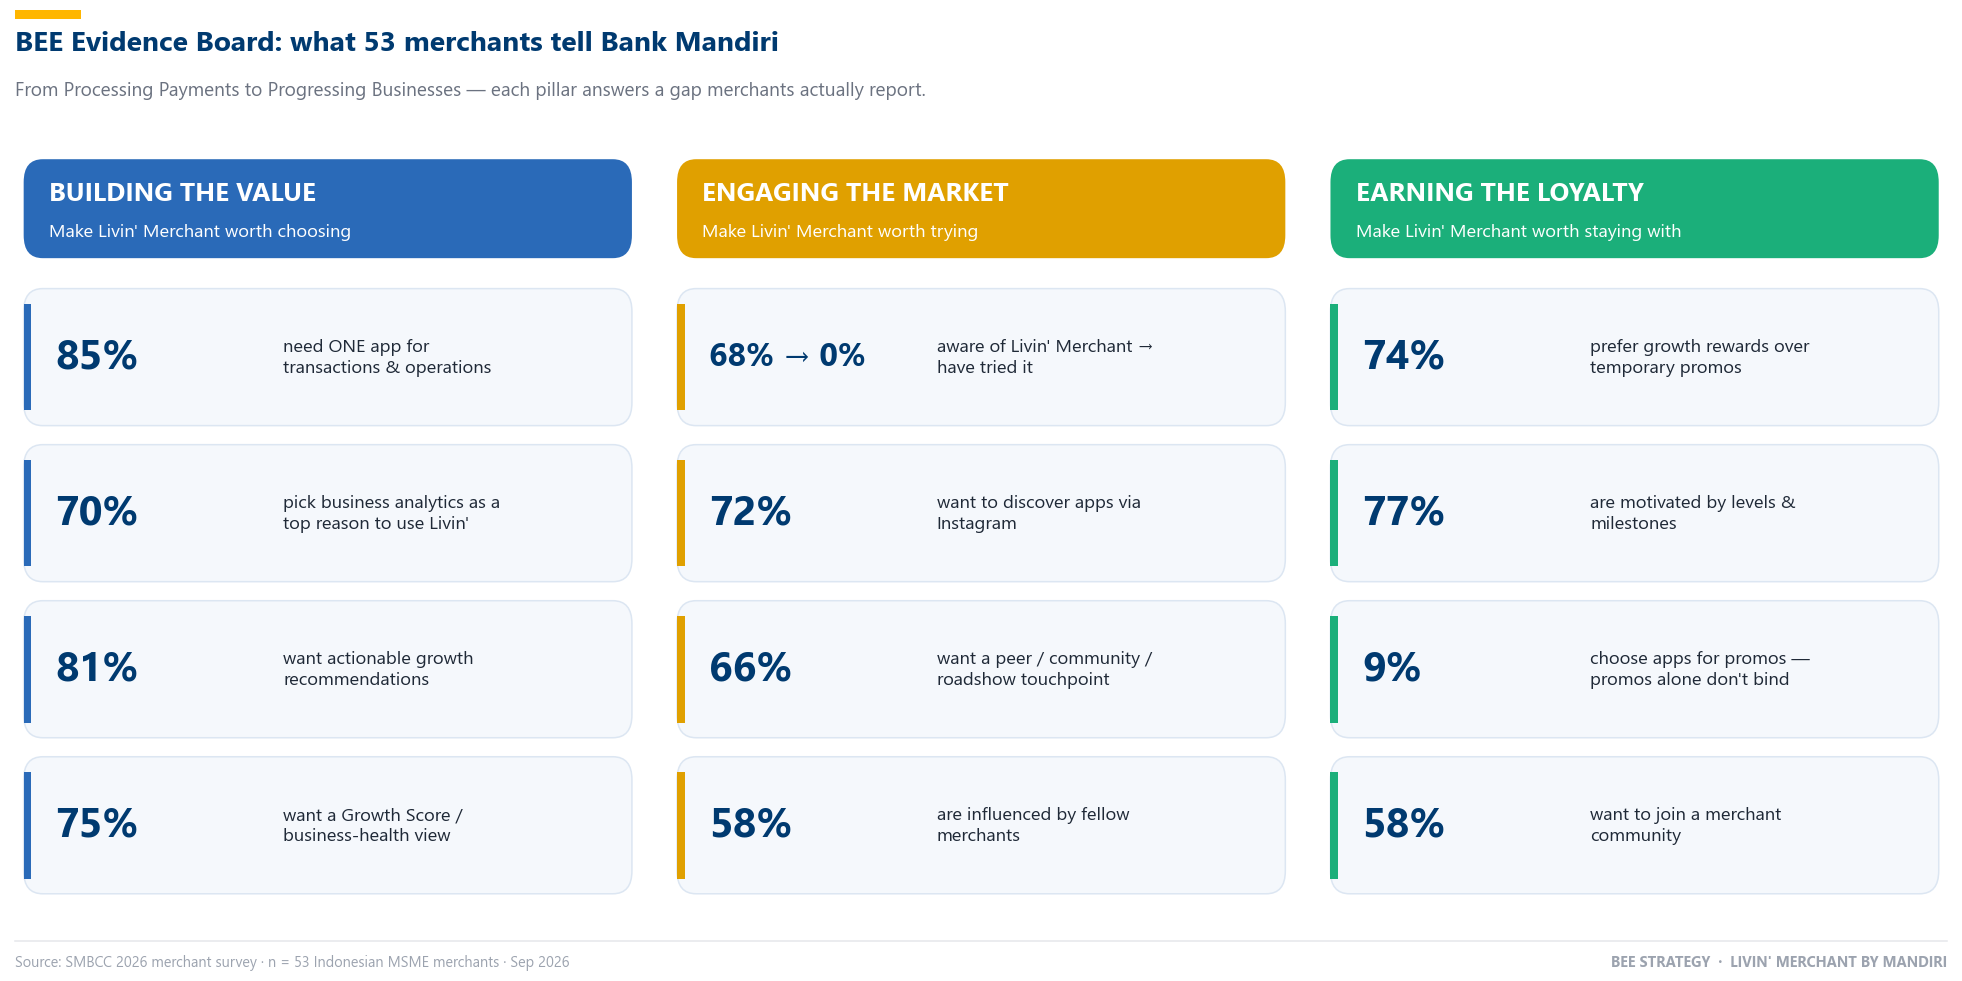

In [50]:
board = {
    'BUILD': ('Building the Value', "Make Livin' Merchant worth choosing", [
        (f"{(df.Q15>=4).mean()*100:.0f}%", 'need ONE app for transactions & operations'),
        (f"{lf['Business analytics']/N*100:.0f}%", "pick business analytics as a top reason to use Livin'"),
        (f"{(df.Q17>=4).mean()*100:.0f}%", 'want actionable growth recommendations'),
        (f"{(df.Q12>=4).mean()*100:.0f}%", 'want a Growth Score / business-health view'),
    ]),
    'ENGAGE': ('Engaging the Market', "Make Livin' Merchant worth trying", [
        (f"{df.aware_livin.mean()*100:.0f}% → 0%", "aware of Livin' Merchant → have tried it"),
        (f"{ch['Instagram']/N*100:.0f}%", 'want to discover apps via Instagram'),
        (f"{df.ch_physical.mean()*100:.0f}%", 'want a peer / community / roadshow touchpoint'),
        (f"{(df.Q22>=4).mean()*100:.0f}%", 'are influenced by fellow merchants'),
    ]),
    'EARN': ('Earning the Loyalty', "Make Livin' Merchant worth staying with", [
        (f"{(df.Q25>=4).mean()*100:.0f}%", 'prefer growth rewards over temporary promos'),
        (f"{(df.Q24>=4).mean()*100:.0f}%", 'are motivated by levels & milestones'),
        (f"{sf.get('Rewards & promos',0)/N*100:.0f}%", "choose apps for promos — promos alone don't bind"),
        (f"{(df.Q26>=4).mean()*100:.0f}%", 'want to join a merchant community'),
    ]),
}
fig, axes = plt.subplots(1, 3, figsize=(18, 9))
for ax, (p, (name, tagline, items)) in zip(axes, board.items()):
    ax.axis('off'); col = PILLAR[p]
    ax.add_patch(FancyBboxPatch((0.02, 0.86), 0.96, 0.13, boxstyle='round,pad=0,rounding_size=0.03', transform=ax.transAxes, facecolor=col, edgecolor='none'))
    ax.text(0.06, 0.945, name.upper(), transform=ax.transAxes, fontsize=17, fontweight='bold', color='white', va='center')
    ax.text(0.06, 0.895, tagline, transform=ax.transAxes, fontsize=12, color='white', va='center')
    for i, (big, small) in enumerate(items):
        y0 = 0.64 - i * 0.205
        ax.add_patch(FancyBboxPatch((0.02, y0), 0.96, 0.18, boxstyle='round,pad=0,rounding_size=0.03', transform=ax.transAxes,
                                    facecolor=CARD, edgecolor='#DCE6F2'))
        ax.add_patch(Rectangle((0.02, y0 + 0.02), 0.012, 0.14, transform=ax.transAxes, color=col, lw=0))
        ax.text(0.07, y0 + 0.09, big, transform=ax.transAxes, fontsize=27 if len(big) < 6 else 21, fontweight='bold', color=NAVY, va='center')
        ax.text(0.43, y0 + 0.09, wrap(small, 28), transform=ax.transAxes, fontsize=12, color=INK, va='center', linespacing=1.3)
show(fig, 'BEE Evidence Board: what 53 merchants tell Bank Mandiri',
     'From Processing Payments to Progressing Businesses — each pillar answers a gap merchants actually report.', name='30_bee_evidence_board')

In [51]:
headline = pd.DataFrame([
    ('Merchant Paradox', "Awareness → trial of Livin' Merchant", f"{df.aware_livin.mean()*100:.0f}% → 0%", 'Q10'),
    ('Merchant Paradox', 'Accept QRIS (payment is baseline)', pct(df.accepts_qris.sum()), 'Q4'),
    ('Persona journey · RUN', 'Record sales with 2+ fragmented methods', pct((df.n_recording_methods >= 2).sum()), 'Q5'),
    ('Root cause · Growth Value Gap', 'Management features "too complicated"', pct(bar['Too complicated']), 'Q9'),
    ('Root cause · Market Activation Gap', 'Use a competitor wallet/app today', pct(df.has_dedicated_app.sum()), 'Q6'),
    ('Root cause · Loyalty Progress Gap', 'Prefer growth rewards over temporary promos', f"{(df.Q25>=4).mean()*100:.0f}%", 'Q25'),
    ('BUILD · RUN', 'Need one app for transactions & operations', f"{(df.Q15>=4).mean()*100:.0f}%", 'Q15'),
    ('BUILD · UNDERSTAND', "Pick business analytics as top Livin' benefit", pct(lf['Business analytics']), 'Q29'),
    ('BUILD · GROW', 'Want a business-health / Growth Score view', f"{(df.Q12>=4).mean()*100:.0f}%", 'Q12'),
    ('BUILD · GROW', 'Want to know financing readiness', f"{(df.Q18>=4).mean()*100:.0f}%", 'Q18'),
    ('BUILD · Data flywheel', 'Would record more routinely for financing eligibility', f"{(df.Q14>=4).mean()*100:.0f}%", 'Q14'),
    ('BUILD · ACT', 'Notifications help decide faster', f"{(df.Q21>=4).mean()*100:.0f}%", 'Q21'),
    ('BUILD · CONNECT', 'Prefer app linked to bank account', f"{(df.Q20>=4).mean()*100:.0f}%", 'Q20'),
    ('ENGAGE · Digital', 'Discover apps via Instagram / TikTok', f"{pct(ch['Instagram'])} / {pct(ch['TikTok'])}", 'Q28'),
    ('ENGAGE · Activation', 'Want a peer / community / roadshow touchpoint', pct(df.ch_physical.sum()), 'Q28'),
    ('ENGAGE · Activation', 'Want demo before registering (Explore Mode)', f"{(df.Q19>=4).mean()*100:.0f}%", 'Q19'),
    ('EARN · Progress', 'Motivated by levels / milestones', f"{(df.Q24>=4).mean()*100:.0f}%", 'Q24'),
    ('EARN · Champion', 'Influenced by peer merchants', f"{(df.Q22>=4).mean()*100:.0f}%", 'Q22'),
    ('EARN · Community', 'Interested in a merchant community', f"{(df.Q26>=4).mean()*100:.0f}%", 'Q26'),
    ('Competitive advantage', 'Top-3 factor: ease of use (table stakes)', pct(sf['Ease of use']), 'Q27'),
], columns=['Deck slide', 'Headline statistic', 'Value', 'Source'])
display(headline.style.hide(axis='index').set_properties(**{'font-size': '13px', 'text-align': 'left'})
        .set_properties(subset=['Value'], **{'font-weight': 'bold', 'color': NAVY}))
headline.to_csv(FIG_DIR / 'deck_headline_stats.csv', index=False)
print(f'Saved {len(list(FIG_DIR.glob("*.png")))} figures and deck_headline_stats.csv to {FIG_DIR.resolve()}')

Deck slide,Headline statistic,Value,Source
Merchant Paradox,Awareness → trial of Livin' Merchant,68% → 0%,Q10
Merchant Paradox,Accept QRIS (payment is baseline),94%,Q4
Persona journey · RUN,Record sales with 2+ fragmented methods,45%,Q5
Root cause · Growth Value Gap,"Management features ""too complicated""",38%,Q9
Root cause · Market Activation Gap,Use a competitor wallet/app today,89%,Q6
Root cause · Loyalty Progress Gap,Prefer growth rewards over temporary promos,74%,Q25
BUILD · RUN,Need one app for transactions & operations,85%,Q15
BUILD · UNDERSTAND,Pick business analytics as top Livin' benefit,70%,Q29
BUILD · GROW,Want a business-health / Growth Score view,75%,Q12
BUILD · GROW,Want to know financing readiness,72%,Q18


Saved 30 figures and deck_headline_stats.csv to C:\Users\ASUS\xStyNWx\Documents\BINUS University\Competition\2026\00. Bersama Stacy\02. SMBCC\Final\Repo\data-analysis\figures


### Conclusion: what the survey means for BEE
| BEE pillar | Verdict | Strongest evidence | Roadmap implication |
|---|---|---|---|
| **B · Building the Value** | **Strongly validated** (index 4.01, 96% of merchants above neutral) | One app 85% · analytics as top Livin' Merchant benefit 70% · recommendations 81% · Growth Score 75% · financing motivates recording 66% | **Q1 Build Core:** analytics + Growth Score + Growth Mission / Next Best Action, simple UX, security by design |
| **E · Engaging the Market** | **Validated as a conversion problem** (68% aware, 0% trial; ENGAGE items have the largest neutral share) | Instagram 72% · TikTok 62% · community 55% · 66% want a peer/physical touchpoint | **Q2–Q3:** Explore Mode + a hybrid of Digital Growth Marketing and UMKM Growth Activation, aimed at aware non-users |
| **E · Earning the Loyalty** | **Validated: progress beats promos** | Growth rewards 74% · milestones 77% · promos as a selection factor only 9% | **Q4:** Business Growth Stage on existing Livin'poin, then Merchant Champion (recruit from 1–2-year merchants) and Merchant Circle |

**The survey supports the BEE flywheel:** merchants want insight (BUILD). They will record more data if it brings them closer to financing, and that data feeds better guidance. They discover apps socially and trust other merchants (ENGAGE). Visible progress keeps them using the app (EARN), and satisfied merchants recruit new ones. **Livin' Merchant should not only process a merchant's transactions — it should progress the merchant's business.**

---
## 19. Limitations & next steps
**Limitations**
* **Sample size (n = 53)** and **convenience sampling** — results are directional, not nationally representative; segment comparisons (n = 9–36 per group) are exploratory.
* **No current Livin' Merchant users** in the sample — the survey measures *prospective* demand, not satisfaction with the current app.
* **Stated vs revealed preference** — Likert agreement overstates actual adoption (acquiescence bias). BEE's stage-gated pilot (Q2 *Pilot & Validate*) is designed to test these stated preferences against real behaviour before scaling.
* **Short collection window** (two days) and a partly pre-formulated open-answer list for Q30 limit the diversity of verbatims.

**Next steps**
1. Use these findings as KPI baselines for the pilot (e.g., Growth Feature Adoption ≥ 25%, Notification Action Rate ≥ 12%, Referral-to-Activated ≥ 8%).
2. Run the pilot with the **Growth Seekers** persona first (highest BEE appetite), then test assisted onboarding for the Simplicity-first Operators.
3. Expand the survey to more non-urban merchants and to current Livin' Merchant users to measure feature *utilisation* gaps.
4. A/B test messaging: *growth outcomes* ("Every Transaction Moves Your Business Forward") vs *feature lists*.